This script (Tomofast-x-µ) runs Tomofast-x Code for QDM 3D Inversion, Magnetic source location determination, and Magnetic vector direction and intensity Detection

 The full workflow:
 1. Run TomoFast-x 3D inversion (WSL, or Linux)
 2. Extract best-fit dipole 3D location for each anomaly
 3. Compute dipole moment, declination, and inclination

 Every step in an independent tool

 To Run this code you have to install Tomofast-x first, and copy paste the current code in the same folder beside Bz file, this code automatically organizes the outputs within some folders


 Conversion rule between Tomofast and QDM

**QDM:** Z-axis positive *up*  
**Tomofast:** Z-axis positive *down*

| Conversion | Rule |
|-----------|------|
| **QDM → Tomofast** | Flip both **Bz** and **Mz** |
| **Tomofast → QDM** | Flip both **Bz** and **Mz** |
| **Tomofast → Tomofast** | Don’t flip **Bz** and don’t flip **Mz** |
| **QDM → QDM** | Don’t flip **Bz** and don’t flip **Mz** |


# Import Libraries


In [2]:
# paths
import os

# files
import glob

# arrays
import numpy as np

# plotting
import matplotlib.pyplot as plt

# matlab
from scipy.io import loadmat
import scipy.io

# datasets
import xarray as xr

# tables
import pandas as pd

# paths
from pathlib import Path

# Connectiviy
from scipy import ndimage as ndi

# shapes
import matplotlib.patches as patches

# Connectiviy
from scipy.ndimage import binary_dilation

# processes
import subprocess

# system
import sys

# Connectiviy
from scipy.ndimage import label, generate_binary_structure

# 3D 
from mpl_toolkits.mplot3d import Axes3D 

# math
import math

# regex
import re

# paleomag
import pmagpy.ipmag as ipmag


# colormap
from matplotlib.cm import ScalarMappable

# scaling
from matplotlib.colors import Normalize


#Tomofast Directory
TOMOFAST_HOME_WSL = "/home/abekhit/Tomofast-X"
TOMOFAST_HOME = "/home/abekhit/Tomofast-X"

#WSL Directory
WSL = r"C:\Windows\System32\wsl.exe"
#nUM of cores for tomofast run
NPROC = 7  # mpirun -np


base_dir = os.getcwd()  # current working directory
BASE_DIR = os.getcwd()  # current working directory
print("Current working directory (Windows):", base_dir)

-W- cartopy is not installed
    If you want to make maps, install using conda:
    conda install cartopy
Current working directory (Windows): D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2


# Create Folders


In [2]:
# 1-Create 3D Folder
folder_path = os.path.join(base_dir, "4-3D_Inversion_Filtered")       

if os.path.exists(folder_path):
    print("Folder already exists:", folder_path)
else:
    os.mkdir(folder_path)
    print("Folder created:", folder_path)
    

# 2-Create parfiles Folder
folder_path = os.path.join(base_dir, "0-Parfiles")       

if os.path.exists(folder_path):
    print("Folder already exists:", folder_path)
else:
    os.mkdir(folder_path)
    print("Folder created:", folder_path)

# 3-Create source detection Folder

folder_path = os.path.join(base_dir,  "4-Source_Detection")#, "Single_cell_meshs")        

if os.path.exists(folder_path):
    print("Folder already exists:", folder_path)
else:
    os.mkdir(folder_path)
    print("Folder created:", folder_path)

# 4- Create source location ouputs Folder

folder_path = os.path.join(base_dir,  "4-Source_Detection", "Tomofast_Output")      

if os.path.exists(folder_path):
    print("Folder already exists:", folder_path)
else:
    os.mkdir(folder_path)
    print("Folder created:", folder_path)

Folder already exists: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered
Folder already exists: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\0-Parfiles
Folder already exists: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-Source_Detection
Folder already exists: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-Source_Detection\Tomofast_Output


# Quick Visualization
the following two lines show the bz vs LED, assuming Bz.mat is in the same folder of this code.
* User Attention: in the second Define pixel size below, we used pix= 4.4 

Using: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\NC07-002-2Bz_uc0.mat
Variables: ['h', 'corners', 'newLED', 'Bz', 'Bt', 'step']
Pixel size (µm): 4.4


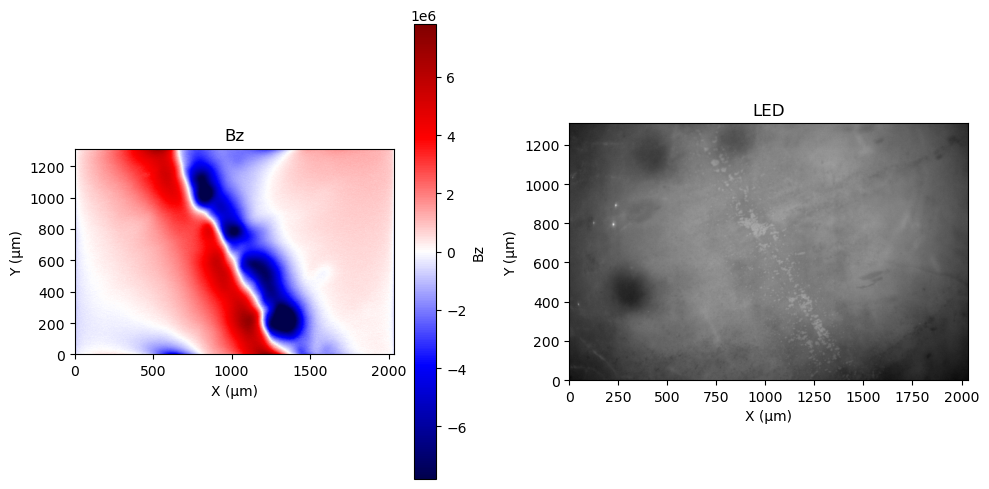

In [3]:
# Show Bz vs LED

# -------------------------------------------------
# LOAD MAT FILE
# -------------------------------------------------
mat_file = glob.glob(os.path.join(os.getcwd(), "*.mat"))[0]
print("Using:", mat_file)

mat = loadmat(mat_file)

print("Variables:",
      [k for k in mat.keys() if not k.startswith("__")])

# -------------------------------------------------
# EXTRACT DATA
# -------------------------------------------------
Bz = np.squeeze(mat["Bz"])* 1e9
led = np.squeeze(mat["newLED"])

# pixel size in µm
pix = float(np.squeeze(mat["step"]))*1e6

print("Pixel size (µm):", pix)

ny, nx = Bz.shape
extent = [0, nx*pix, 0, ny*pix]

# -------------------------------------------------
# PLOT
# -------------------------------------------------
fig, axs = plt.subplots(1,2, figsize=(10,5))

# --- Bz ---
v = np.percentile(np.abs(Bz), 99)

im = axs[0].imshow(
    Bz,
    cmap="seismic",
    vmin=-v,
    vmax=v,
    origin="upper",
    extent=extent
)

axs[0].set_title("Bz")
axs[0].set_xlabel("X (µm)")
axs[0].set_ylabel("Y (µm)")
plt.colorbar(im, ax=axs[0], label="Bz")

# --- LED ---
axs[1].imshow(
    led,
    cmap="gray",
    origin="upper",
    extent=extent
)

axs[1].set_title("LED")
axs[1].set_xlabel("X (µm)")
axs[1].set_ylabel("Y (µm)")

plt.tight_layout()
plt.show()


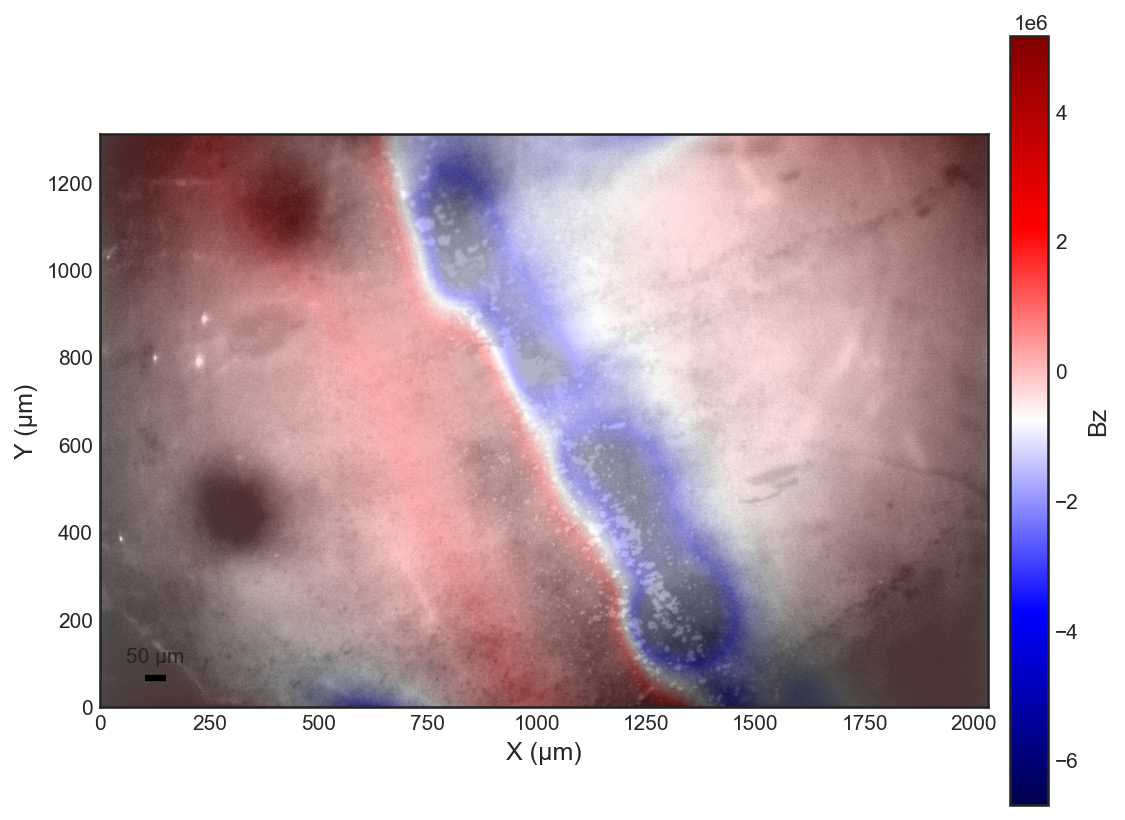

In [4]:
# Show Bz overlaid by LED

### User Attention: Define pixel size below, we used pix= 4.4 

# ---------- BASE DIRECTORY ----------
base_dir = os.getcwd()

# ---------- LOAD MAT ----------
mat_file = glob.glob(os.path.join(base_dir, "*.mat"))[0]
mat = loadmat(mat_file)

Bz  = np.squeeze(mat["Bz"])* 1e9
led = np.squeeze(mat["newLED"])

# ---------- Pixel size ----------
pix = 4.4  # µm
ny, nx = Bz.shape

x = np.linspace(0, nx*pix, nx)
y = np.linspace(0, ny*pix, ny)

X, Y = np.meshgrid(x, y)

# ---------- Clip outliers ----------
bz_min = np.percentile(Bz, 2)
bz_max = np.percentile(Bz, 98)

# ---------- Style ----------
plt.style.use("seaborn-v0_8-white")

fig, ax = plt.subplots(figsize=(8,6), dpi=150)

# ---------- Bz base ----------
im = ax.imshow(
    Bz,
    cmap="seismic",
    vmin=bz_min,
    vmax=bz_max,
    origin="upper",
    extent=[x.min(), x.max(), y.min(), y.max()]
)

cbar = plt.colorbar(im, ax=ax, shrink=0.9, pad=0.02)
cbar.set_label("Bz", fontsize=12)
cbar.ax.tick_params(labelsize=10)

# ---------- LED overlay ----------
ax.imshow(
    led,
    cmap="gray",
    alpha=0.7,
    origin="upper",
    extent=[x.min(), x.max(), y.min(), y.max()],
    vmin=np.percentile(led,5),
    vmax=np.percentile(led,95)
)

# ---------- Scale bar ----------
bar_len = 50  # µm
x0 = x.min() + 0.05*(x.max()-x.min())
y0 = y.min() + 0.05*(y.max()-y.min())

ax.plot([x0, x0+bar_len], [y0, y0],
        color="k", linewidth=3, solid_capstyle="butt")

ax.text(
    x0 + bar_len/2,
    y0 + 0.02*(y.max()-y.min()),
    f"{int(bar_len)} µm",
    ha="center", va="bottom", fontsize=10
)

# ---------- Labels ----------
ax.set_xlabel("X (µm)", fontsize=12)
ax.set_ylabel("Y (µm)", fontsize=12)

ax.set_aspect("equal", adjustable="box")
ax.margins(0)



plt.tight_layout()

# ---------- Save ----------
out_png = os.path.join(base_dir, "Bz_LED_overlay.png")
plt.savefig(out_png, dpi=300, bbox_inches="tight")

plt.show()


# Tool 1: 3D Inversion
This tool runs Tomofast-x full magnetic vector inversion in order to obtain the full 3D magnetic image of the QDM micromagnetic scan.  
the inputs are (Bz file, mesh file, Tomofast Parameter file)

### 1. Read Bz mat file
This line reads Bz mat file (qdmlab) format and save it as csv and plot (if your data is csv skip the first step)
* User Attention: Define the Bz.mat name, and define Vmin max for the plot, given it's very important parameter for seeing tiny dipoles.

In [5]:
# Function Definition 
#For Bu case change any Bz to Bu


# Unit conversion constants
METER_TO_MICROMETER = 1e6
TESLA_TO_NANOTESLA = 1e9

def load_qdm_mat(path, save_csv=True, csv_path=None):
    """
    Load QDM microscopy data from a MATLAB .mat file 
    return as an xarray Dataset.
    
    Parameters
    ----------
    path : str or Path
        Path to the .mat file
    
    save_csv : bool, optional (default=True)
        If True, save the output as a CSV file.
    
    csv_path : str or Path, optional
        Path to save the CSV file. 
        If None, will save as "<mat_file_stem>.csv" in the same folder.
    
    Returns
    -------
    xarray.Dataset
        Dataset with:
          - bz(y, x): vertical magnetic field [nT]
          - coords: x [µm], y [µm], z [µm] (sensor-sample distance)
          - attributes: units + file metadata
    """
    # Ensure path is Path object
    path = Path(path)

    # Load MATLAB file
    contents = scipy.io.loadmat(path)

    # Pixel spacing (convert m -> µm)
    spacing = contents['step'].ravel()[0] * METER_TO_MICROMETER

    # Vertical magnetic field (convert T -> nT)
    bz = contents['Bz'] * TESLA_TO_NANOTESLA

    # Sensor-sample distance (convert m -> µm)
    sensor_sample_distance = float(contents['h']) * METER_TO_MICROMETER

    # Coordinates
    x = np.arange(bz.shape[1]) * spacing
    #y = np.arange(bz.shape[0]) * spacing
    y = np.arange(bz.shape[0])[::-1] * spacing #flip from image coordinates (origin up) to cartesian coordinate (origin low) 
    z = np.full_like(bz, sensor_sample_distance)

    # Wrap into xarray
    data = xr.Dataset(
        data_vars={
            "bz": (("y", "x"), bz)
        },
        coords={
            "x": ("x", x, {"units": "µm"}),
            "y": ("y", y, {"units": "µm"}),
            "z": (("y", "x"), z, {"long_name": "sensor sample distance", "units": "µm"})
        },
        attrs={"file_name": str(path)}
    )

    # Add field metadata
    data.bz.attrs = {"long_name": "vertical magnetic field", "units": "nT"}

    # --- Save to CSV if requested ---
    if save_csv:
        if csv_path is None:
            csv_path = path.with_suffix(".csv")  # same name as input, .csv extension
        
        # Flatten arrays into a table
        # When saving:
        df = pd.DataFrame({
        "x (µm)": np.tile(x, len(y)),      # x varies fastest
        "y (µm)": np.repeat(y, len(x)),    # y varies slowest
        "z (µm)": np.repeat(sensor_sample_distance, len(x)*len(y)),
        "bz (nT)": bz.ravel(order="C")
        })
        
        df = df.sort_values(by=["y (µm)", "x (µm)"], ascending=[True, True]) #sort Y after flipping)
        df.to_csv(csv_path, index=False)
        print(f"[INFO] Saved CSV file at: {csv_path}")

    return data

In [6]:
# Read Bz and save is as csv
### User Attention: Define the Bz.mat name

data = load_qdm_mat(os.path.join(base_dir, "NC07-002-2Bz_uc0.mat"))

# Dataset available in memory
print(data)

# CSV also saved: "-.csv"

[INFO] Saved CSV file at: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\NC07-002-2Bz_uc0.csv
<xarray.Dataset> Size: 2MB
Dimensions:  (y: 298, x: 462)
Coordinates:
  * x        (x) float64 4kB 0.0 4.4 8.8 13.2 ... 2.02e+03 2.024e+03 2.028e+03
  * y        (y) float64 2kB 1.307e+03 1.302e+03 1.298e+03 ... 8.8 4.4 0.0
    z        (y, x) float64 1MB 5e+06 5e+06 5e+06 5e+06 ... 5e+06 5e+06 5e+06
Data variables:
    bz       (y, x) float64 1MB -4.092e+05 3.147e+04 ... -1.903e+05 -5.605e+05
Attributes:
    file_name:  D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\...


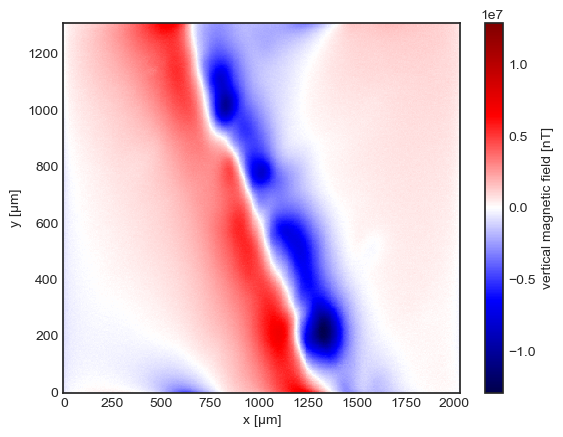

In [7]:
# Plot the vertical magnetic field map
### User Attention: define Vmin max for the plot, given it's very important parameter for seeing tiny dipoles

data.bz.plot.pcolormesh(cmap="seismic")#, vmax=500000, vmin=-500000)

### 2. Format data into Tomofast-x format [XYZBz]
This line reads the csv file output from the previous line or defined by user
* Also supports data clipping by definning the desired cells indeices {x_start = 0, x_end   = nx, y_start = 0, y_end   = ny}
* User Attention: define define CSV file name (filename_z=)

(137676, 4)
Plot saved to D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\bz.png


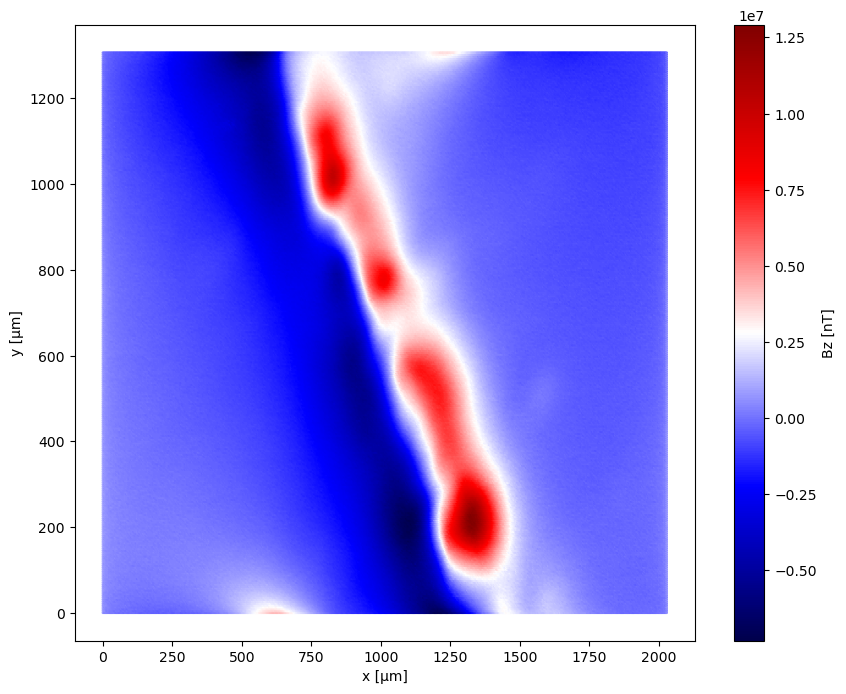

Grid dimensions: 462 298
(298, 462)
Plot saved to D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Clipped_bz.png


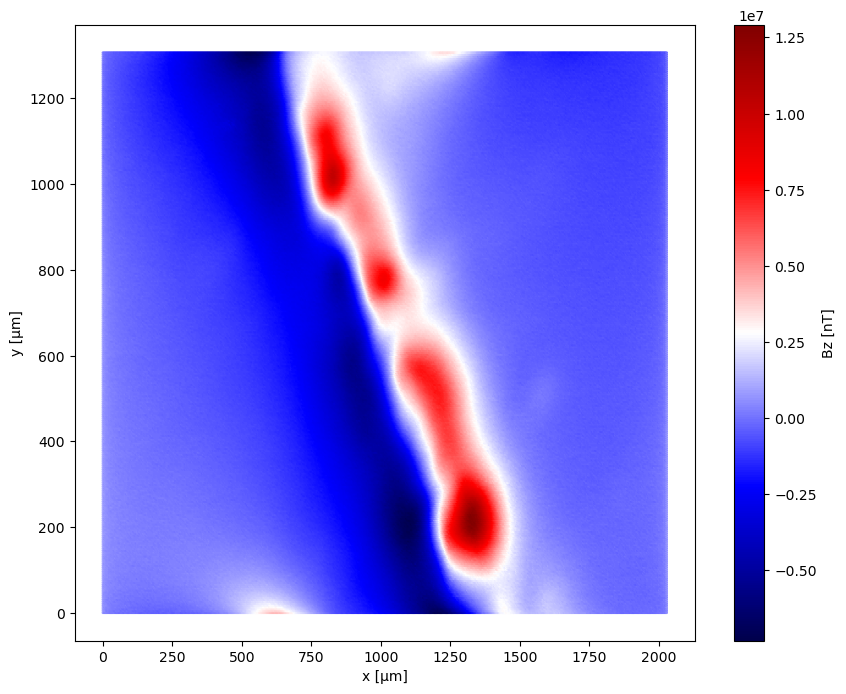

Xmin, Xmax = 0.0 2028.4
Ymin, Ymax = 0.0 1306.8000000000002
Ndata = 137676


In [3]:
#Data Perp. full scan ( or clip optional)
# also reads CsV
### User Attention: define define CSV file name (filename_z=)

   
def plot_data(x_coords, y_coords, values, title, out_dir= os.path.join(base_dir, "4-3D_Inversion_Filtered")):
    # Make sure output directory exists
    os.makedirs(out_dir, exist_ok=True)

    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(x_coords, y_coords, c=values, cmap='seismic', s=1)#, vmax=500000, vmin=-500000) # define Vmin max if wanted
    #plt.axis('equal')
    plt.colorbar(scatter, label='Bz [nT]')
    plt.xlabel('x [µm]')
    plt.ylabel('y [µm]')
    #plt.title(title)

    # Save plot to file
    filename = os.path.join(out_dir, f"{title.replace(' ', '_')}.png")
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"Plot saved to {filename}")

    plt.show()

# Reads CSV User input
#filename_z = os.path.join(base_dir, "2-Forward_Data","Tomofast_Output", "data", "mag_calc_prior_data.txt")
#data_z = np.loadtxt(filename_z, skiprows=1)

# Reads CSV  ouput from the previous line (Bz read)
filename_z = os.path.join(base_dir, "NC07-002-2Bz_uc0.csv")
data_z = np.loadtxt(filename_z, delimiter=",", skiprows=1)

print(data_z.shape)

x_coords = data_z[:, 0]
y_coords = data_z[:, 1]
z_coords = data_z[:, 2]
z_coords = 0*data_z[:, 2] #Make Z=0

#bz = data_z[:, 3] # dont flip  if tomofast forwarded

bz = -1*data_z[:, 3] #Flipping Bz for tomofast coordiante system Z is positive down, the QDM Bz is positive up

#bx = data_z[:, 3]
#by = data_z[:, 4]

#amplitude
#b_mag = np.sqrt(bx**2 + by**2 + bz**2)


# Plot the image of data.
plot_data(x_coords, y_coords, bz, 'bz')

#==============================================================
# Find unique coordinates to determine grid dimensions.
unique_x = np.unique(x_coords)
unique_y = np.unique(y_coords)

nx = len(unique_x)  # number of points in X direction
ny = len(unique_y)  # number of points in Y direction

print("Grid dimensions:", nx, ny)

x_coords = x_coords.reshape(ny, nx)
y_coords = y_coords.reshape(ny, nx)
z_coords = z_coords.reshape(ny, nx)

bz = bz.reshape(ny, nx)
#==============================================================
# Clipping the data.
#enter the cell index (given the one index equal 4.4 increment)
# to cover the full range (min → max)
x_start = 0
x_end   = nx
y_start = 0
y_end   = ny

x_coords = x_coords[y_start:y_end, x_start:x_end]
y_coords = y_coords[y_start:y_end, x_start:x_end]
z_coords = z_coords[y_start:y_end, x_start:x_end]
bz = bz[y_start:y_end, x_start:x_end]

print(bz.shape)

# Convert back to 1D array.
x_coords = x_coords.flatten()
y_coords = y_coords.flatten()
z_coords = z_coords.flatten()
bz = bz.flatten()

# Plot the image of data.
plot_data(x_coords, y_coords, bz, 'Clipped bz')

print('Xmin, Xmax =', np.min(x_coords), np.max(x_coords))
print('Ymin, Ymax =', np.min(y_coords), np.max(y_coords))

#==============================================================
# Write tomofast data grid.
# Bz only
data_combined = np.column_stack((x_coords, y_coords, z_coords, bz))
#data_combined = np.column_stack((x_coords, y_coords, z_coords, bx, by, bz))

Ndataz = len(bz)
print('Ndata =', Ndataz)

np.savetxt(os.path.join(base_dir, "4-3D_Inversion_Filtered", "Mag_Inversion.obs"), data_combined, delimiter=' ', fmt="%f %f %f %f", header=str(Ndataz), comments='')

### 3. Anomalies Detection
This line reads the Bz data and split the anomalies into windows, using a standard deviation-based thresholding approach to suppress the unwanted background signals, focus on the sources and reduce computational cost and also useful for the cases where the dipoles are very close and data interfers.

* User Attention: the following line needs user adjustment to capture relaiable anomlaies:
* threshold_factor : is the number where user decide which pixels in bz_grid count as “signal” (potential anomaly) vs “background/noise” (recommended to change with 0.25).
* Pad_X, and Pad_Y : extend the window size around the anomaly (good for 3D modelling, but not recommend in use in the case of interfering data : keep 0)
* MIN_BLOB_CELLS : this number ignores the noisy small anomalies based of the cell size printed (set 1 to keep everything)
* MAX_BLOB_CELLS: this number ignores the noisy huge anomalies based of the cell size printed (set very big number to keep everything e.g, 100000)
* NZ_FIXED : this number defines the number of depth cells required for the parfile (step 5); should match the mesh model in the next step.
* for the case where positive and negative dipoles detected as two anomlaies use labels, n_blobs = ndi.label(mask_dilated), otherwise use:labels, n_blobs = ndi.label(mask) 

Grid: 462 298
Blobs detected (raw): 8
Blob 1: 12 cells
Blob 2: 1 cells
Blob 3: 1262 cells
Blob 4: 130 cells
Blob 5: 431 cells
Blob 6: 211 cells
Blob 7: 702 cells
Blob 8: 23 cells
Skipping Blob 1 (too small: 12 cells)
Skipping Blob 2 (too small: 1 cells)

Blob 3:
  X range: [1060.400, 1592.800] µm
  Y range: [88.000, 374.000] µm
  nx ny nz: 122 66 120
  nData   : 8052
  Saved obs: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Blob_Clipped_obs_RECT\Blob_003_RECT.obs
Skipping Blob 4 (too small: 130 cells)

Blob 5:
  X range: [932.800, 1421.200] µm
  Y range: [378.400, 638.000] µm
  nx ny nz: 112 60 120
  nData   : 6720
  Saved obs: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Blob_Clipped_obs_RECT\Blob_005_RECT.obs

Blob 6:
  X range: [792.000, 1227.600] µm
  Y range: [699.600, 862.400] µm
  nx ny nz: 100 38 120
  nData   : 3800
  Saved obs: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3

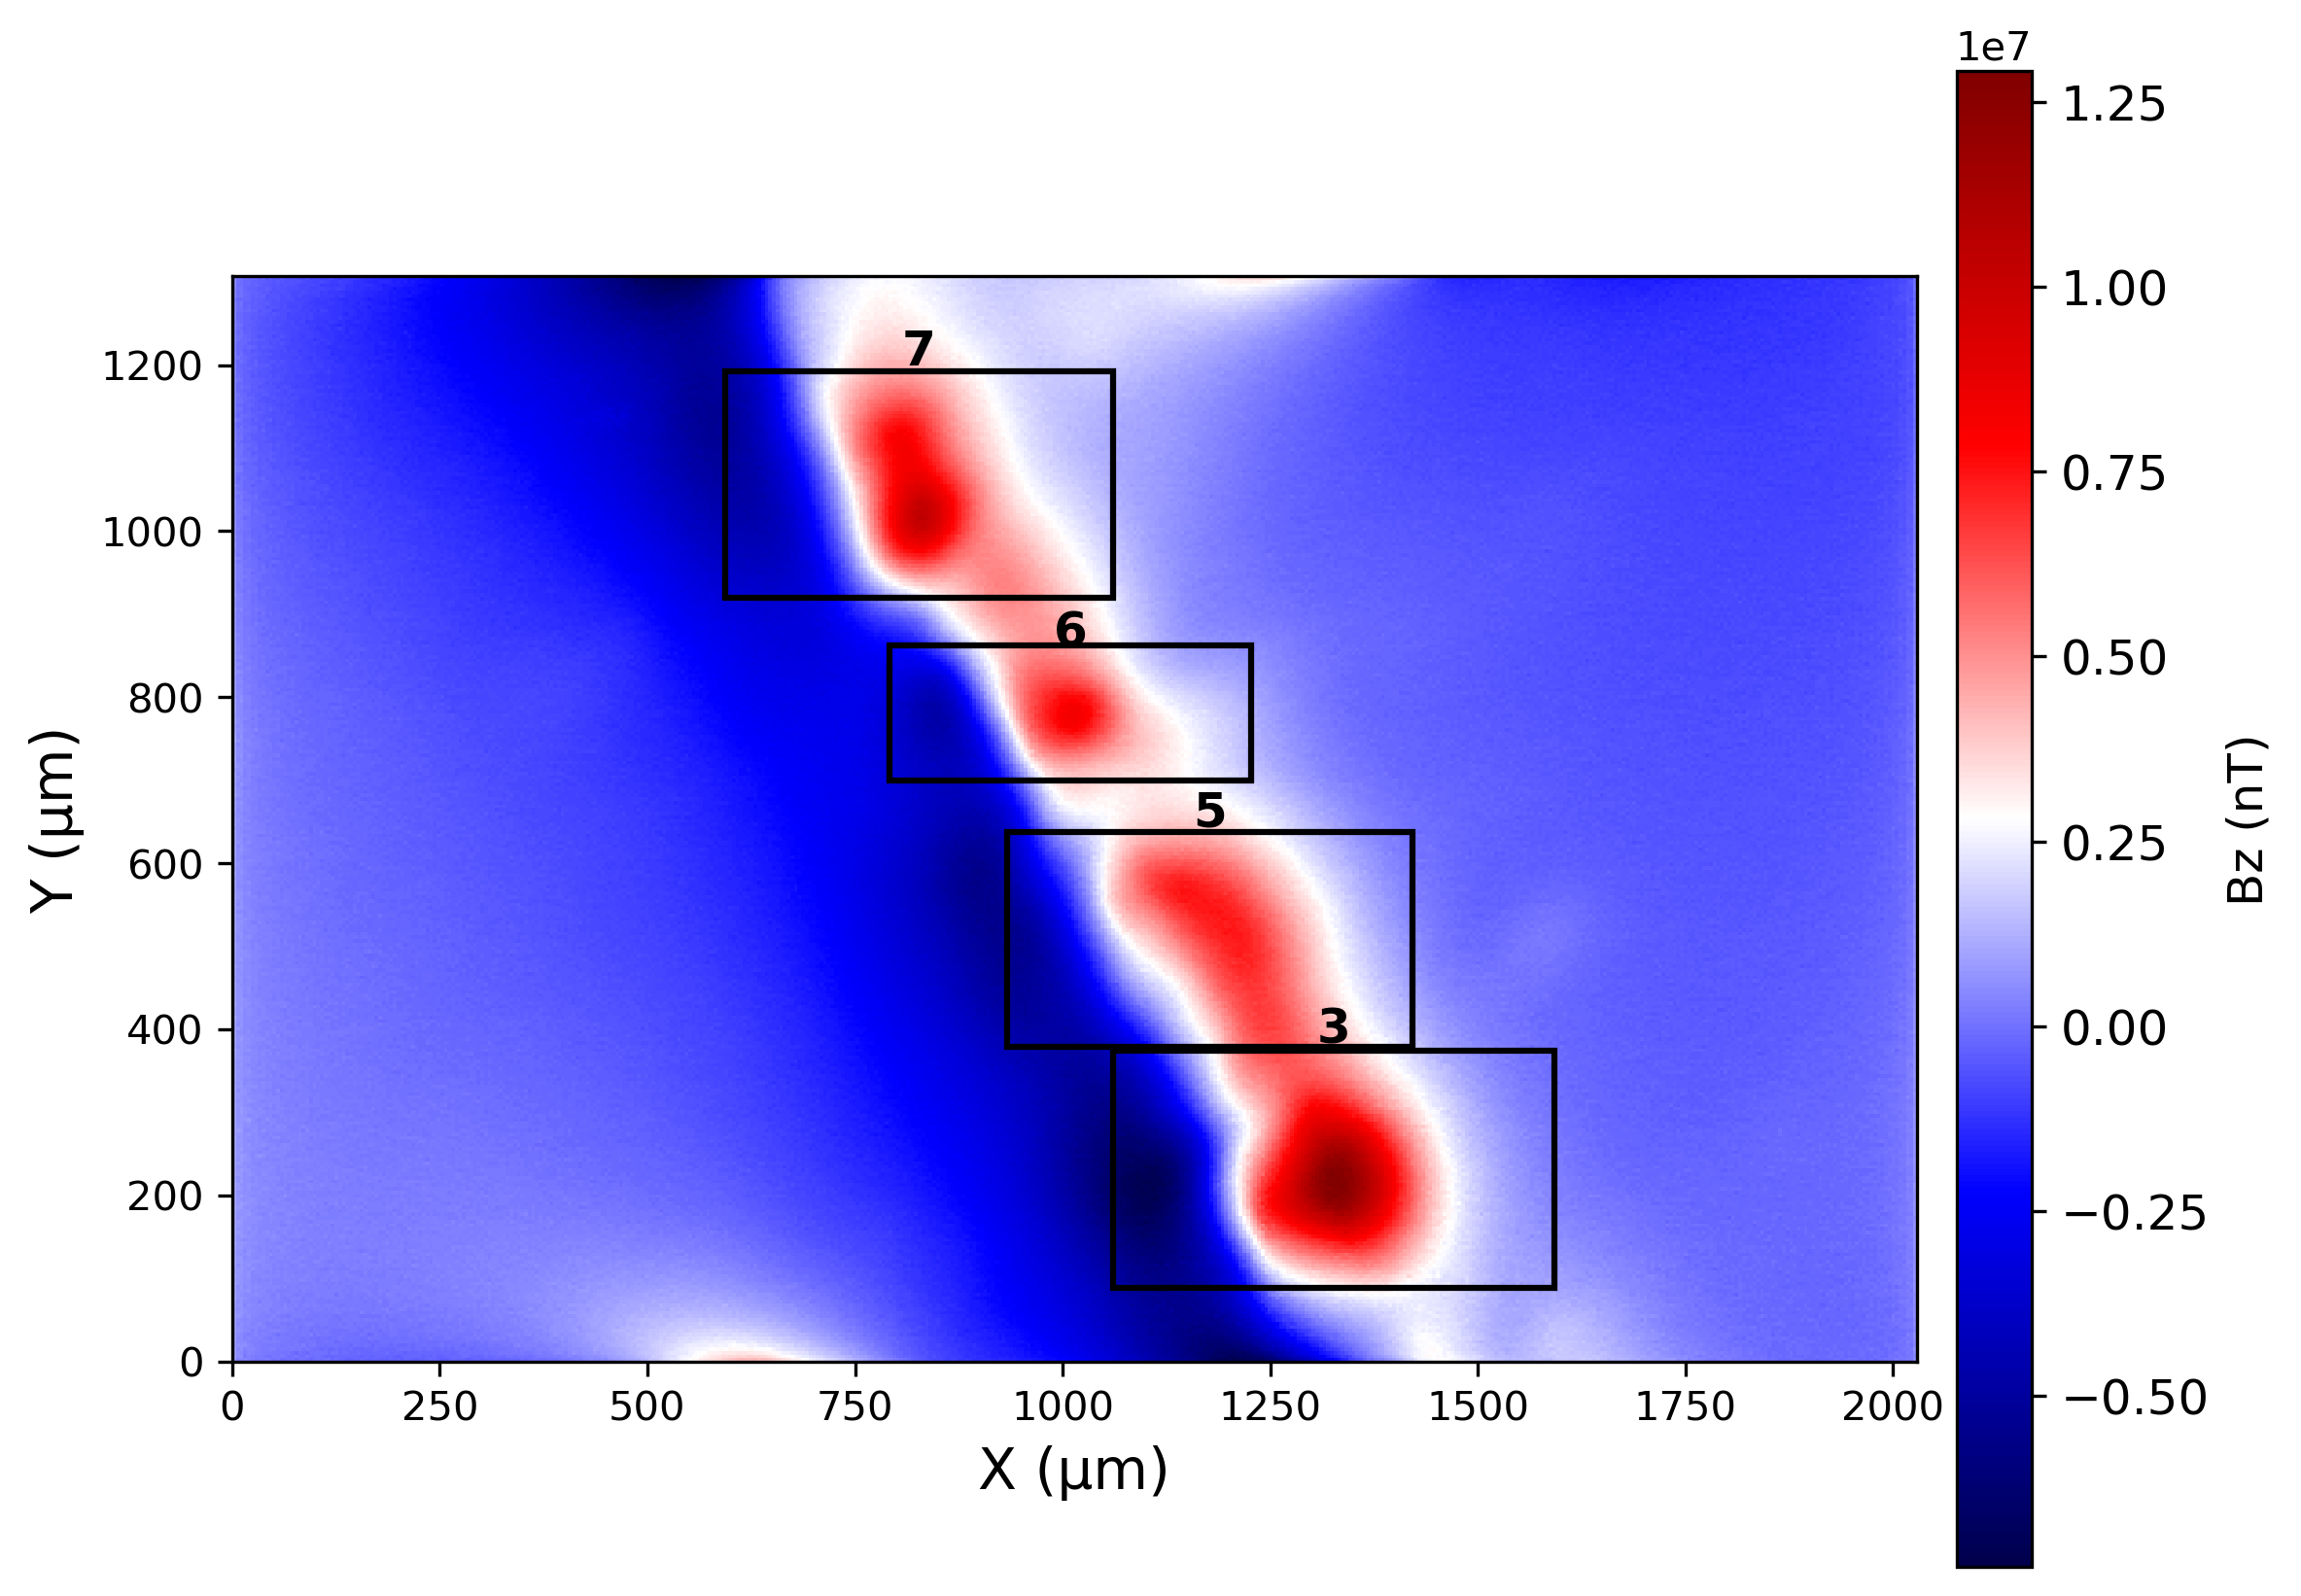


DONE
Kept blobs: 4
Obs folder: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Blob_Clipped_obs_RECT
Windows file: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\blob_windows.txt
Summary file: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\blob_window_summary.txt


In [6]:
# ============================================================
# SETTINGS
# ============================================================

threshold_factor = 2.75

PAD_X = 40   # extend rectangle in X (cols)
PAD_Y = 10 # extend rectangle in Y (rows)

MIN_BLOB_CELLS = 150   # ignore tiny blobs (set 1 to keep everything)
MAX_BLOB_CELLS = 100000   # ignore huge blobs (set very big number to keep everything e.g, 100000)
NZ_FIXED = 120        # nz for Tomofast (same for all blobs)

# ============================================================
# PATHS
# ============================================================
obs_path = os.path.join(base_dir, "4-3D_Inversion_Filtered", "Mag_Inversion.obs")

out_obs_dir = os.path.join(base_dir, "4-3D_Inversion_Filtered", "Blob_Clipped_obs_RECT")

# clear old outputs
if os.path.exists(out_obs_dir):
    for fname in os.listdir(out_obs_dir):
        fpath = os.path.join(out_obs_dir, fname)
        if os.path.isfile(fpath):
            os.remove(fpath)
else:
    os.makedirs(out_obs_dir)


# Output 1: blob windows (xmin xmax ymin ymax)
windows_path = os.path.join(base_dir, "4-3D_Inversion_Filtered", "blob_windows.txt")

# Output 2: summary for parfiles (nx ny nz ndata)
summary_path = os.path.join(base_dir, "4-3D_Inversion_Filtered", "blob_window_summary.txt")

# Write headers (overwrite each run)
with open(windows_path, "w") as fw:
    fw.write("# blob_id x_min x_max y_min y_max\n")

with open(summary_path, "w") as fs:
    fs.write("# blob_id nx ny nz ndata\n")

# ============================================================
# 1) READ OBS
# ============================================================
with open(obs_path, "r") as f:
    header_line = f.readline().strip()

data = np.loadtxt(obs_path, skiprows=1)
x  = data[:, 0]
y  = data[:, 1]
bz = data[:, 3]

# ============================================================
# 2) GRID RESHAPE
# ============================================================
nx = len(np.unique(x))
ny = len(np.unique(y))

# assumes grid-ordered obs
x_grid  = x.reshape(ny, nx)
y_grid  = y.reshape(ny, nx)
bz_grid = bz.reshape(ny, nx)

print("Grid:", nx, ny)

# ============================================================
# 3) DETECT BLOBS
# ============================================================
thr = threshold_factor * np.std(bz_grid)
mask = np.abs(bz_grid) > thr


# allows nearby high-amplitude regions to connect if they are spatially close.
structure = np.ones((3, 3))  # allows diagonal + small gaps
mask_dilated = binary_dilation(mask, structure=structure, iterations=1)

labels, n_blobs = ndi.label(mask_dilated)

# not merging .
#labels, n_blobs = ndi.label(mask)

print("Blobs detected (raw):", n_blobs)

sizes = ndi.sum(mask, labels, index=np.arange(1, n_blobs + 1))
for i, sz in enumerate(sizes, start=1):
    print(f"Blob {i}: {int(sz)} cells")

slices = ndi.find_objects(labels)

# ============================================================
# helper: write obs file with updated Ndata in header
# ============================================================
def write_obs(out_path, header, arr):
    parts = header.split()
    try:
        int(parts[0])           # if header starts with Ndata
        parts[0] = str(arr.shape[0])
        header = " ".join(parts)
    except:
        pass

    with open(out_path, "w") as f:
        f.write(header + "\n")
        np.savetxt(f, arr, fmt="%.6f")

# ============================================================
# 4) OVERVIEW PLOT
# ============================================================
plt.figure(figsize=(8, 6), dpi=300)
#im = plt.imshow(
#    bz_grid,
#    origin="lower",
#    extent=[x_grid.min(), x_grid.max(), y_grid.min(), y_grid.max()],
#    cmap="seismic",
 #   aspect="equal"
#)

im = plt.imshow(
    bz_grid,
    origin="lower",
    extent=[x_grid.min(), x_grid.max(), y_grid.min(), y_grid.max()],
    cmap="seismic",
    aspect="equal")#, vmax=500000, vmin=-500000)

cbar = plt.colorbar(im, pad=0.02, shrink=0.9)
cbar.set_label("Bz (nT)", fontsize=12)
cbar.ax.tick_params(labelsize=12)

plt.xlabel("X (µm)", fontsize=14)
plt.ylabel("Y (µm)", fontsize=14)

ax = plt.gca()
ax.tick_params(axis="both", labelsize=10)
#ax.grid(True, linestyle="--", alpha=0.3)
ax.margins(0)
#ax.text(
##    0.02, 0.98, "(a)",
#    transform=ax.transAxes,
#    fontsize=25,
#    fontweight="bold",
 #   va="top",
 #   ha="left"
#)

plt.tight_layout()

# ============================================================
# 5) LOOP BLOBS: SAVE obs + SAVE windows + SAVE summary
# ============================================================
kept = 0

for i, sl in enumerate(slices, start=1):
    if sl is None:
        continue

    # skip tiny blobs
    if sizes[i-1] < MIN_BLOB_CELLS:
        print(f"Skipping Blob {i} (too small: {int(sizes[i-1])} cells)")
        continue
        
    # skip Huge blobs
    if sizes[i-1] > MAX_BLOB_CELLS:
        print(f"Skipping Blob {i} (too small: {int(sizes[i-1])} cells)")
        continue
        
    ys, xs = sl
    r0, r1 = ys.start, ys.stop - 1
    c0, c1 = xs.start, xs.stop - 1

    # extend bbox (Y longer)
    r0e = max(0, r0 - PAD_Y)
    r1e = min(ny - 1, r1 + PAD_Y)
    c0e = max(0, c0 - PAD_X)
    c1e = min(nx - 1, c1 + PAD_X)

    # rectangular mask
    rect_mask = np.zeros((ny, nx), dtype=bool)
    rect_mask[r0e:r1e+1, c0e:c1e+1] = True

    # clip rows (RECTANGLE)
    blob_data = data[rect_mask.ravel(), :]

    # rectangle coords (µm)
    x_min = x_grid[r0e, c0e]
    x_max = x_grid[r1e, c1e]
    y_min = y_grid[r0e, c0e]
    y_max = y_grid[r1e, c1e]

    # window size in CELLS (for parfile modelGrid.size)
    nx_win = (c1e - c0e + 1)  # X = columns
    ny_win = (r1e - r0e + 1)  # Y = rows
    nz_win = NZ_FIXED

    # number of data points in clipped obs (for parfile nData)
    ndata = blob_data.shape[0]

    print(f"\nBlob {i}:")
    print(f"  X range: [{x_min:.3f}, {x_max:.3f}] µm")
    print(f"  Y range: [{y_min:.3f}, {y_max:.3f}] µm")
    print(f"  nx ny nz: {nx_win} {ny_win} {nz_win}")
    print(f"  nData   : {ndata}")

    # --------------------------
    # (A) SAVE BLOB OBS
    # --------------------------
    obs_out = os.path.join(out_obs_dir, f"Blob_{i:03d}_RECT.obs")
    write_obs(obs_out, header_line, blob_data)

    # --------------------------
    # (B) SAVE WINDOW FILE LINE
    # --------------------------
    with open(windows_path, "a") as fw:
        fw.write(f"{i} {x_min:.6f} {x_max:.6f} {y_min:.6f} {y_max:.6f}\n")

    # --------------------------
    # (C) SAVE SUMMARY FILE LINE
    # --------------------------
    with open(summary_path, "a") as fs:
        fs.write(f"{i} {nx_win} {ny_win} {nz_win} {ndata}\n")

    # draw rectangle + label on overview
    ax.add_patch(
        patches.Rectangle(
            (x_min, y_min),
            x_max - x_min, y_max - y_min,
            edgecolor="black", facecolor="none", linewidth=1.5
        )
    )
    ax.text(
        0.5*(x_min+x_max), y_max + 0.9 * (y_max - y_min) * 0.1, str(i),
       color="black", ha="center", va="center", fontsize=12, weight="bold"
    )

    kept += 1
    print("  Saved obs:", obs_out)

plt.tight_layout()
out_png = os.path.join(base_dir, "4-3D_Inversion_Filtered", "BZ_Blobs.png")
plt.savefig(out_png, dpi=300, bbox_inches='tight')
plt.show()

print("\n====================================")
print("DONE")
print("Kept blobs:", kept)
print("Obs folder:", out_obs_dir)
print("Windows file:", windows_path)
print("Summary file:", summary_path)
print("====================================")


### 4. Create Meshs
this line creates 3d Mesh model.  
this line supports non-uniform padding regions dx , dy (delta per layer), and dz (delta per layer) to reach maximum pads and depth with less computational resources)
* User Attention: define the model parameters:
* dx_core, dy_core: the x,y cell size in the core area below the anomlaies (must match the data spacing)
* npad_x, npad_y : Number of padding cell (outside the windows to ensure full 3D model recovery and overcome the edge effect)
* rx, ry : Padding growth (for example 1.15 means every cell is cummlatively 15% larger than the previous one)
* nz, dz0, rz: number of depth cells, depth cell size, and depth cell growth ( for example 60, 4.4, 1 mean 60 x 4.4 x 1 = 264 µm depth); non-uniform depth saves time and cost for 3d modelling, however, it is not recommended for dipole information as it might lead to non-accurate results. in all cases total depth should matches the sample thickness)

In [10]:

# ============================================================
#  INPUTS (EDIT ONLY THIS BLOCK)
# ============================================================

# Input blob windows file:
# Each line: blob_id x_min x_max y_min y_max
windows_path = os.path.join(base_dir, "4-3D_Inversion_Filtered", "blob_windows.txt")

# Output folder for meshgrids
out_dir = os.path.join(base_dir, "4-3D_Inversion_Filtered", "Blob_Meshgrids")
os.makedirs(out_dir, exist_ok=True)

# Output 2: summary for parfiles (nx ny nz ndata)
summary_path = os.path.join(base_dir, "4-3D_Inversion_Filtered", "blob_window_summary.txt")

# --- Core (data) cell sizes in X/Y (µm) ---
dx_core = 4.4
dy_core = 4.4

# Expand each window by half a core-cell (recommended so data falls inside nicely)
expand_half_cell = True

# --- Non-uniform padding in X/Y ---
npad_x = 20         # pad cells on EACH side in X
npad_y = 20       # pad cells on EACH side in Y
rx = 1.15         # pad growth factor in X (outwards)
ry = 1.15          # pad growth factor in Y (outwards)

# --- Non-uniform Z (layer thickness grows with depth) ---
z_min = 0.0         # top of model (positive down)
nz = 120             # number of z cells
dz0 = 4.4           # top layer thickness (µm)
rz = 1        # z growth factor per layer (depth)

# ------------------------------------------------------------
# ndata handling:
# If you already know ndata per blob, put it in blob_windows.txt
# (add 6th column: ndata). If not, we use a simple fallback:
# ndata = nx_core * ny_core (core grid count)
# ------------------------------------------------------------
use_ndata_from_file_if_present = True

# ============================================================


# ------------------------------------------------
# Write Tomofast meshgrid file (3-component model)
# ------------------------------------------------
def write_meshgrid_tomofast(filename, line_data):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    with open(filename, "w") as f:
        f.write(f"{line_data.shape[0]}\n")
        np.savetxt(
            f, line_data,
            fmt="%f %f %f %f %f %f %f %f %f %d %d %d"
        )


def make_edges(core_min, d_core, n_core, npad, r):
    """
    Build edges with:
      - uniform core widths = d_core (n_core cells)
      - geometric padding widths growing OUTWARD from the core
    Returns:
      edges: length (n_core + 2*npad + 1)
      widths: length (n_core + 2*npad)
    """
    core_widths = np.full(n_core, d_core, dtype=float)

    # padding widths: closest pad cell = d_core, then grows outward
    left_widths  = d_core * (r ** np.arange(npad - 1, -1, -1))  # big -> ... -> d_core (toward core)
    right_widths = d_core * (r ** np.arange(0, npad))           # d_core -> ... -> big (outward)

    widths = np.concatenate([left_widths, core_widths, right_widths])

    start_edge = core_min - left_widths.sum()
    edges = start_edge + np.concatenate(([0.0], np.cumsum(widths)))
    return edges, widths


def build_mesh_for_window(
    x_min, x_max, y_min, y_max, out_file,
    dx_core=dx_core, dy_core=dy_core,
    npad_x=npad_x, npad_y=npad_y, rx=rx, ry=ry,
    z_min=z_min, nz=nz, dz0=dz0, rz=rz,
    expand_half_cell=expand_half_cell
):
    # -----------------------------
    # 1) Define CORE extents
    # -----------------------------
    if expand_half_cell:
        x_core_min = x_min - 0.5 * dx_core
        x_core_max = x_max + 0.5 * dx_core
        y_core_min = y_min - 0.5 * dy_core
        y_core_max = y_max + 0.5 * dy_core
    else:
        x_core_min, x_core_max = x_min, x_max
        y_core_min, y_core_max = y_min, y_max

    # Core cell counts
    nx_core = int(np.round((x_core_max - x_core_min) / dx_core))
    ny_core = int(np.round((y_core_max - y_core_min) / dy_core))

    if nx_core < 1 or ny_core < 1:
        raise ValueError(
            f"Window too small for given dx/dy. "
            f"Got nx_core={nx_core}, ny_core={ny_core}. Check units/extents."
        )

    # Snap core max so it is exactly n_core * d_core from core_min
    x_core_max = x_core_min + nx_core * dx_core
    y_core_max = y_core_min + ny_core * dy_core

    # -----------------------------
    # 2) Build NON-UNIFORM X/Y edges
    # -----------------------------
    x_edges, x_widths = make_edges(x_core_min, dx_core, nx_core, npad_x, rx)
    y_edges, y_widths = make_edges(y_core_min, dy_core, ny_core, npad_y, ry)

    # Totals including pads
    nx_cells = nx_core + 2 * npad_x
    ny_cells = ny_core + 2 * npad_y
    nz_cells = nz

    # -----------------------------
    # 3) Build NON-UNIFORM Z edges (geometric growth)
    # -----------------------------
    dz_list = dz0 * (rz ** np.arange(nz_cells))                 # len = nz_cells
    z_edges = z_min + np.concatenate(([0.0], np.cumsum(dz_list)))

    # -----------------------------
    # 4) Create cell bounds grids (Tomofast ordering)
    # -----------------------------
    # Use indexing="ij" and flatten(order="F")
    X1, Y1, Z1 = np.meshgrid(x_edges[:-1], y_edges[:-1], z_edges[:-1], indexing="ij")
    X2, Y2, Z2 = np.meshgrid(x_edges[ 1:], y_edges[ 1:], z_edges[ 1:], indexing="ij")

    # 1-based indices for Tomofast
    I, J, K = np.meshgrid(
        np.arange(1, nx_cells + 1),
        np.arange(1, ny_cells + 1),
        np.arange(1, nz_cells + 1),
        indexing="ij"
    )

    # Flatten (Fortran order)
    x1 = X1.flatten(order="F"); x2 = X2.flatten(order="F")
    y1 = Y1.flatten(order="F"); y2 = Y2.flatten(order="F")
    z1 = Z1.flatten(order="F"); z2 = Z2.flatten(order="F")
    ii = I.flatten(order="F");  jj = J.flatten(order="F");  kk = K.flatten(order="F")

    N = x1.size
    zeros = np.zeros(N, dtype=float)

    # 3-comp model format:
    # X1 X2 Y1 Y2 Z1 Z2 0 0 0 I J K
    line_data = np.column_stack([x1, x2, y1, y2, z1, z2, zeros, zeros, zeros, ii, jj, kk])

    # Write file
    write_meshgrid_tomofast(out_file, line_data)

    # Return summary info
    info = {
        "nx_core": nx_core, "ny_core": ny_core, "nz": nz_cells,
        "nx": nx_cells, "ny": ny_cells,
        "x_min": x_edges[0], "x_max": x_edges[-1],
        "y_min": y_edges[0], "y_max": y_edges[-1],
        "z_min": z_edges[0], "z_max": z_edges[-1],
        "dz_top": dz_list[0], "dz_bottom": dz_list[-1],
        "dx_min": x_widths.min(), "dx_max": x_widths.max(),
        "dy_min": y_widths.min(), "dy_max": y_widths.max()
    }
    return info


# ------------------------------------------------
# MAIN
# ------------------------------------------------
windows = np.loadtxt(windows_path, comments="#", ndmin=2)

print("Windows loaded:", windows.shape[0])
print("Output folder:", out_dir)
print(f"Pads: npad_x={npad_x}, npad_y={npad_y}, rx={rx}, ry={ry}")
print(f"Z: nz={nz}, dz0={dz0}, rz={rz}\n")

# Write summary header once
with open(summary_path, "w") as fs:
    fs.write("# blob_id nx ny nz ndata\n")

for row in windows:
    blob_id = int(row[0])
    x_min, x_max, y_min, y_max = row[1], row[2], row[3], row[4]

    out_file = os.path.join(out_dir, f"Meshgrid_Blob_{blob_id:03d}.txt")
    info = build_mesh_for_window(x_min, x_max, y_min, y_max, out_file)

    # -----------------------------
    # ndata (keep simple, unchanged)
    # -----------------------------
    # If blob_windows.txt has a 6th column (ndata), use it
    if use_ndata_from_file_if_present and row.size >= 6:
        ndata = int(row[5])
    else:
        # fallback (simple): number of core cells in XY
        ndata = int(info["nx_core"] * info["ny_core"])

    # ---------------------------------------------------------
    # WRITE SUMMARY (UPDATED): use padded FINAL nx ny nz
    # ---------------------------------------------------------
    with open(summary_path, "a") as fs:
        fs.write(
            f"{blob_id:d} "
            f"{info['nx']:d} {info['ny']:d} {info['nz']:d} "
            f"{ndata:d}\n"
        )

    print(
        f"Blob {blob_id:03d}: "
        f"core(nx,ny)=({info['nx_core']},{info['ny_core']})  "
        f"total(nx,ny,nz)=({info['nx']},{info['ny']},{info['nz']})  "
        f"ndata={ndata}"
    )
    print(
        f"  X[{info['x_min']:.3f}, {info['x_max']:.3f}]  "
        f"Y[{info['y_min']:.3f}, {info['y_max']:.3f}]  "
        f"Z[{info['z_min']:.3f}, {info['z_max']:.3f}]"
    )
    print(
        f"  Δx(min,max)=({info['dx_min']:.3f},{info['dx_max']:.3f})  "
        f"Δy(min,max)=({info['dy_min']:.3f},{info['dy_max']:.3f})  "
        f"Δz(top,bottom)=({info['dz_top']:.3f},{info['dz_bottom']:.3f})"
    )
    print("  saved:", out_file, "\n")

print("Summary saved:", summary_path)
print("Done.")


Windows loaded: 4
Output folder: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Blob_Meshgrids
Pads: npad_x=20, npad_y=20, rx=1.15, ry=1.15
Z: nz=120, dz0=4.4, rz=1

Blob 003: core(nx,ny)=(122,66)  total(nx,ny,nz)=(162,106,120)  ndata=8052
  X[607.448, 2045.752]  Y[-364.952, 826.952]  Z[0.000, 528.000]
  Δx(min,max)=(4.400,62.620)  Δy(min,max)=(4.400,62.620)  Δz(top,bottom)=(4.400,4.400)
  saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Blob_Meshgrids\Meshgrid_Blob_003.txt 

Blob 005: core(nx,ny)=(112,60)  total(nx,ny,nz)=(152,100,120)  ndata=6720
  X[479.848, 1874.152]  Y[-74.552, 1090.952]  Z[0.000, 528.000]
  Δx(min,max)=(4.400,62.620)  Δy(min,max)=(4.400,62.620)  Δz(top,bottom)=(4.400,4.400)
  saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Blob_Meshgrids\Meshgrid_Blob_005.txt 

Blob 006: core(nx,ny)=(100,38)  total(nx,ny,nz)=(140,78,120)  ndata=3800
 

### 5. Create Parfiles
this line creates the parameter files for each anomaly required for the Tomofast-x 3D full vector inverions.
this line reads the number of data [Ndata] , mesh sizes [nx,ny,nz] from the anomalies output. 
* User Attention: Define the compression rate : (forward.matrixCompression.rate) for saving time, however not recommend to use extreme compression, best values between (0.1 - 0.01), where less than 0.01 makes some artifacts.


In [11]:
### User Attention: Define the compression rate : (forward.matrixCompression.rate) 

# ------------------------------------------------
# INPUT: reads anomalies detection output summary file
# ------------------------------------------------
# Format:
# blob_id nx ny nz ndata
summary_path = os.path.join(
    base_dir,
    "4-3D_Inversion_Filtered",
    "blob_window_summary.txt"
)

# ------------------------------------------------
# OUTPUT: parfiles
# ------------------------------------------------
par_out_dir = os.path.join(base_dir, "0-Parfiles")
os.makedirs(par_out_dir, exist_ok=True)

# ------------------------------------------------
# Parfile template (ONLY placeholders will change)
# ------------------------------------------------
PAR_TEMPLATE = """==================================================================================
GLOBAL
==================================================================================
global.outputFolderPath         = ./output/QDM/Blob_{blob_id:03d}
global.description              = QDM inversion – Blob {blob_id}

==================================================================================
MODEL GRID parameters
==================================================================================
# nx ny nz
modelGrid.size                        = {nx} {ny} {nz}
modelGrid.magn.file                   = data/QDM/Meshgrid_Blob_{blob_id:03d}.txt
modelGrid.magn.nModelComponents       = 3

==================================================================================
DATA parameters
==================================================================================
forward.data.magn.nData                = {ndata}
forward.data.magn.dataGridFile         = data/QDM/Blob_{blob_id:03d}_RECT.obs
forward.data.magn.dataValuesFile       = data/QDM/Blob_{blob_id:03d}_RECT.obs
forward.data.magn.nDataComponents      = 1

==================================================================================
MAGNETIC FIELD constants
==================================================================================
forward.magneticField.inclination              = 90.0
forward.magneticField.declination              = 0.0
forward.magneticField.XaxisDeclination         = 0.d0

==================================================================================
DEPTH WEIGHTING
==================================================================================
# 1-depth weight, 2-distance weight.
forward.depthWeighting.type                    = 1

==================================================================================
SENSITIVITY KERNEL
==================================================================================
sensit.readFromFiles                  = 0
sensit.folderPath                     = ./output/QDM/SENSIT/

==================================================================================
MATRIX COMPRESSION
==================================================================================
forward.matrixCompression.type                        = 1
forward.matrixCompression.rate                        = 0.01

==================================================================================
PRIOR MODEL
==================================================================================
inversion.priorModel.type                  = 1
inversion.priorModel.magn.value            = 0.000000

==================================================================================
INVERSION parameters
==================================================================================
inversion.nMajorIterations              = 3
inversion.nMinorIterations              = 100

==================================================================================
MODEL DAMPING (m - m_prior)
==================================================================================
inversion.modelDamping.magn.weight      = 0.0

==================================================================================
JOINT INVERSION parameters
==================================================================================
inversion.joint.grav.problemWeight      = 0.00000000
inversion.joint.magn.problemWeight      = 1.00000000
"""

# ------------------------------------------------
# LOAD SUMMARY + WRITE PARFILES
# ------------------------------------------------
summary = np.loadtxt(summary_path, comments="#", ndmin=2)

print("Creating Parfiles...")

for row in summary:
    blob_id = int(row[0])
    nx      = int(row[1])
    ny      = int(row[2])
    nz      = int(row[3])
    ndata   = int(row[4])

    par_text = PAR_TEMPLATE.format(
        blob_id=blob_id,
        nx=nx,
        ny=ny,
        nz=nz,
        ndata=ndata
    )

    out_path = os.path.join(
        par_out_dir,
        f"Parfile_QDM_Inversion_Blob_{blob_id:03d}.txt"
    )

    with open(out_path, "w") as f:
        f.write(par_text)

    print(f"  Blob {blob_id:03d}: nx={nx}, ny={ny}, nz={nz}, nData={ndata}")
    print("    ->", out_path)

print("\nDone. Parfiles written to:", par_out_dir)


Creating Parfiles...
  Blob 003: nx=162, ny=106, nz=120, nData=8052
    -> D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\0-Parfiles\Parfile_QDM_Inversion_Blob_003.txt
  Blob 005: nx=152, ny=100, nz=120, nData=6720
    -> D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\0-Parfiles\Parfile_QDM_Inversion_Blob_005.txt
  Blob 006: nx=140, ny=78, nz=120, nData=3800
    -> D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\0-Parfiles\Parfile_QDM_Inversion_Blob_006.txt
  Blob 007: nx=147, ny=103, nz=120, nData=6741
    -> D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\0-Parfiles\Parfile_QDM_Inversion_Blob_007.txt

Done. Parfiles written to: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\0-Parfiles


### 6. Run Tomofast-x 3D full vector inversion
this line runs tomofast inversion using the mag.obs, mesh and parfile per window. 
it's also handles transition between Linux (WSL) and windows [automatic copy inputs and outputs)
* for WSL use the first line, for Linux use the second line (just a simple directory change)

In [13]:
# WSL Tomofast-x Run

# Where blob files are (Windows paths)
OBS_DIR  = os.path.join(BASE_DIR, "4-3D_Inversion_Filtered", "Blob_Clipped_obs_RECT")
MESH_DIR = os.path.join(BASE_DIR, "4-3D_Inversion_Filtered","Blob_Meshgrids")               
PAR_DIR  = os.path.join(BASE_DIR, "0-Parfiles")

# Where to copy outputs back (Windows)
OUT_WIN_ROOT = os.path.join(BASE_DIR,  "4-3D_Inversion_Filtered","Tomofast_Output_Blobs")
os.makedirs(OUT_WIN_ROOT, exist_ok=True)

print("Base dir:", BASE_DIR)
print("Obs dir :", OBS_DIR)
print("Mesh dir:", MESH_DIR)
print("Par dir :", PAR_DIR)
print("Out dir :", OUT_WIN_ROOT)

# -----------------------------
# Helpers
# -----------------------------
def to_wsl_path(win_path: str) -> str:
    win_path = win_path.replace("\\", "/")
    drive = win_path[0].lower()
    rest = win_path[2:]
    return f"/mnt/{drive}/{rest}"


#Run live
def run_live(cmd):
    """Run WSL bash command WITHOUT live output (prevents crash)."""
    p = subprocess.Popen(
        [WSL, "bash", "-lc", cmd],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )

    _ = p.stdout.read()   # ← consume output, do NOT print
    p.wait()

    if p.returncode != 0:
        raise RuntimeError(f"Command failed: {cmd}")


#Run quiet

#def run_live(cmd):
 #   """Run WSL bash command with live output."""
#    p = subprocess.Popen(
  #      [WSL, "bash", "-lc", cmd],
   #     stdout=subprocess.PIPE,
    #    stderr=subprocess.STDOUT,
     #   text=True,
     #   bufsize=1
    #)
   # for line in p.stdout:
     #   print(line, end="")
      #  sys.stdout.flush()
   # p.wait()
    #print(f"\n[Return code: {p.returncode}]\n")
    #if p.returncode != 0:
     #   raise RuntimeError(f"Command failed: {cmd}")


        

# -----------------------------
# Find blob IDs from obs files
# -----------------------------
obs_files = sorted(glob.glob(os.path.join(OBS_DIR, "Blob_*_RECT.obs")))
if not obs_files:
    raise FileNotFoundError(f"No blob obs found in: {OBS_DIR}")

def blob_id_from_name(path):
    # Blob_001_RECT.obs -> 1
    name = os.path.basename(path)
    return int(name.split("_")[1])

blob_ids = [blob_id_from_name(f) for f in obs_files]
print("Found blobs:", blob_ids)

# WSL versions of key paths
OBS_DIR_WSL  = to_wsl_path(OBS_DIR)
MESH_DIR_WSL = to_wsl_path(MESH_DIR)
PAR_DIR_WSL  = to_wsl_path(PAR_DIR)
OUT_WIN_WSL  = to_wsl_path(OUT_WIN_ROOT)

# -----------------------------
# Loop over blobs
# -----------------------------
for bid in blob_ids:
    print("\n=======================================================")
    print(f"RUNNING BLOB {bid:03d}")
    print("=======================================================\n")

    # Filenames for this blob (Windows)
    obs_win  = os.path.join(OBS_DIR,  f"Blob_{bid:03d}_RECT.obs")
    mesh_win = os.path.join(MESH_DIR, f"Meshgrid_Blob_{bid:03d}.txt")
    par_win  = os.path.join(PAR_DIR,  f"Parfile_QDM_Inversion_Blob_{bid:03d}.txt")

    # Check they exist
    if not os.path.exists(obs_win):
        raise FileNotFoundError(obs_win)
    if not os.path.exists(mesh_win):
        raise FileNotFoundError(mesh_win)
    if not os.path.exists(par_win):
        raise FileNotFoundError(par_win)

    # Filenames in WSL (source)
    obs_wsl  = f"{OBS_DIR_WSL}/Blob_{bid:03d}_RECT.obs"
    mesh_wsl = f"{MESH_DIR_WSL}/Meshgrid_Blob_{bid:03d}.txt"
    par_wsl  = f"{PAR_DIR_WSL}/Parfile_QDM_Inversion_Blob_{bid:03d}.txt"


    run_live(f"cp '{par_wsl}'  {TOMOFAST_HOME_WSL}/parfiles/")
    run_live(f"cp '{obs_wsl}'  {TOMOFAST_HOME_WSL}/data/QDM/")
    run_live(f"cp '{mesh_wsl}' {TOMOFAST_HOME_WSL}/data/QDM/")

    # (Optional) clean previous output to avoid mixing
    run_live(f"rm -rf {TOMOFAST_HOME_WSL}/output/QDM/*")

    # Run Tomofast for this blob
    par_name = f"Parfile_QDM_Inversion_Blob_{bid:03d}.txt"
    log_name = f"QDM_log_Blob_{bid:03d}.txt"
    run_live(
        f"cd {TOMOFAST_HOME_WSL} && "
        f"mpirun -np {NPROC} ./tomofastx -p ./parfiles/{par_name} | tee ./output/QDM/{log_name}"
    )

    # Copy outputs back to Windows into a separate folder per blob
    out_blob_win = os.path.join(OUT_WIN_ROOT, f"Blob_{bid:03d}")
    os.makedirs(out_blob_win, exist_ok=True)
    out_blob_wsl = to_wsl_path(out_blob_win)

    # Copy everything from output/QDM into this blob folder
    #run_live(f"cp -r {TOMOFAST_HOME_WSL}/output/QDM/* '{out_blob_wsl}/'")
       
    # Copy everything from output/QDM into this blob folder excluding SENSIT
    run_live(
    f"rsync -av --exclude='SENSIT/' "
    f"{TOMOFAST_HOME_WSL}/output/QDM/ '{out_blob_wsl}/'"
    )

    print(f"\n Finished Blob {bid:03d}. Outputs -> {out_blob_win}\n")

print("\nALL BLOBS DONE.")


Base dir: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2
Obs dir : D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Blob_Clipped_obs_RECT
Mesh dir: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Blob_Meshgrids
Par dir : D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\0-Parfiles
Out dir : D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs
Found blobs: [3, 5, 6, 7]

RUNNING BLOB 003


 Finished Blob 003. Outputs -> D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003


RUNNING BLOB 005


 Finished Blob 005. Outputs -> D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_005


RUNNING BLOB 006


 Finished Blob 006. Outputs -> D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversio

### 7. Models Misfits

Reads and plots observed data, calculated data, and residuals

Found blobs: ['Blob_003', 'Blob_005', 'Blob_006', 'Blob_007']

Processing Blob_003


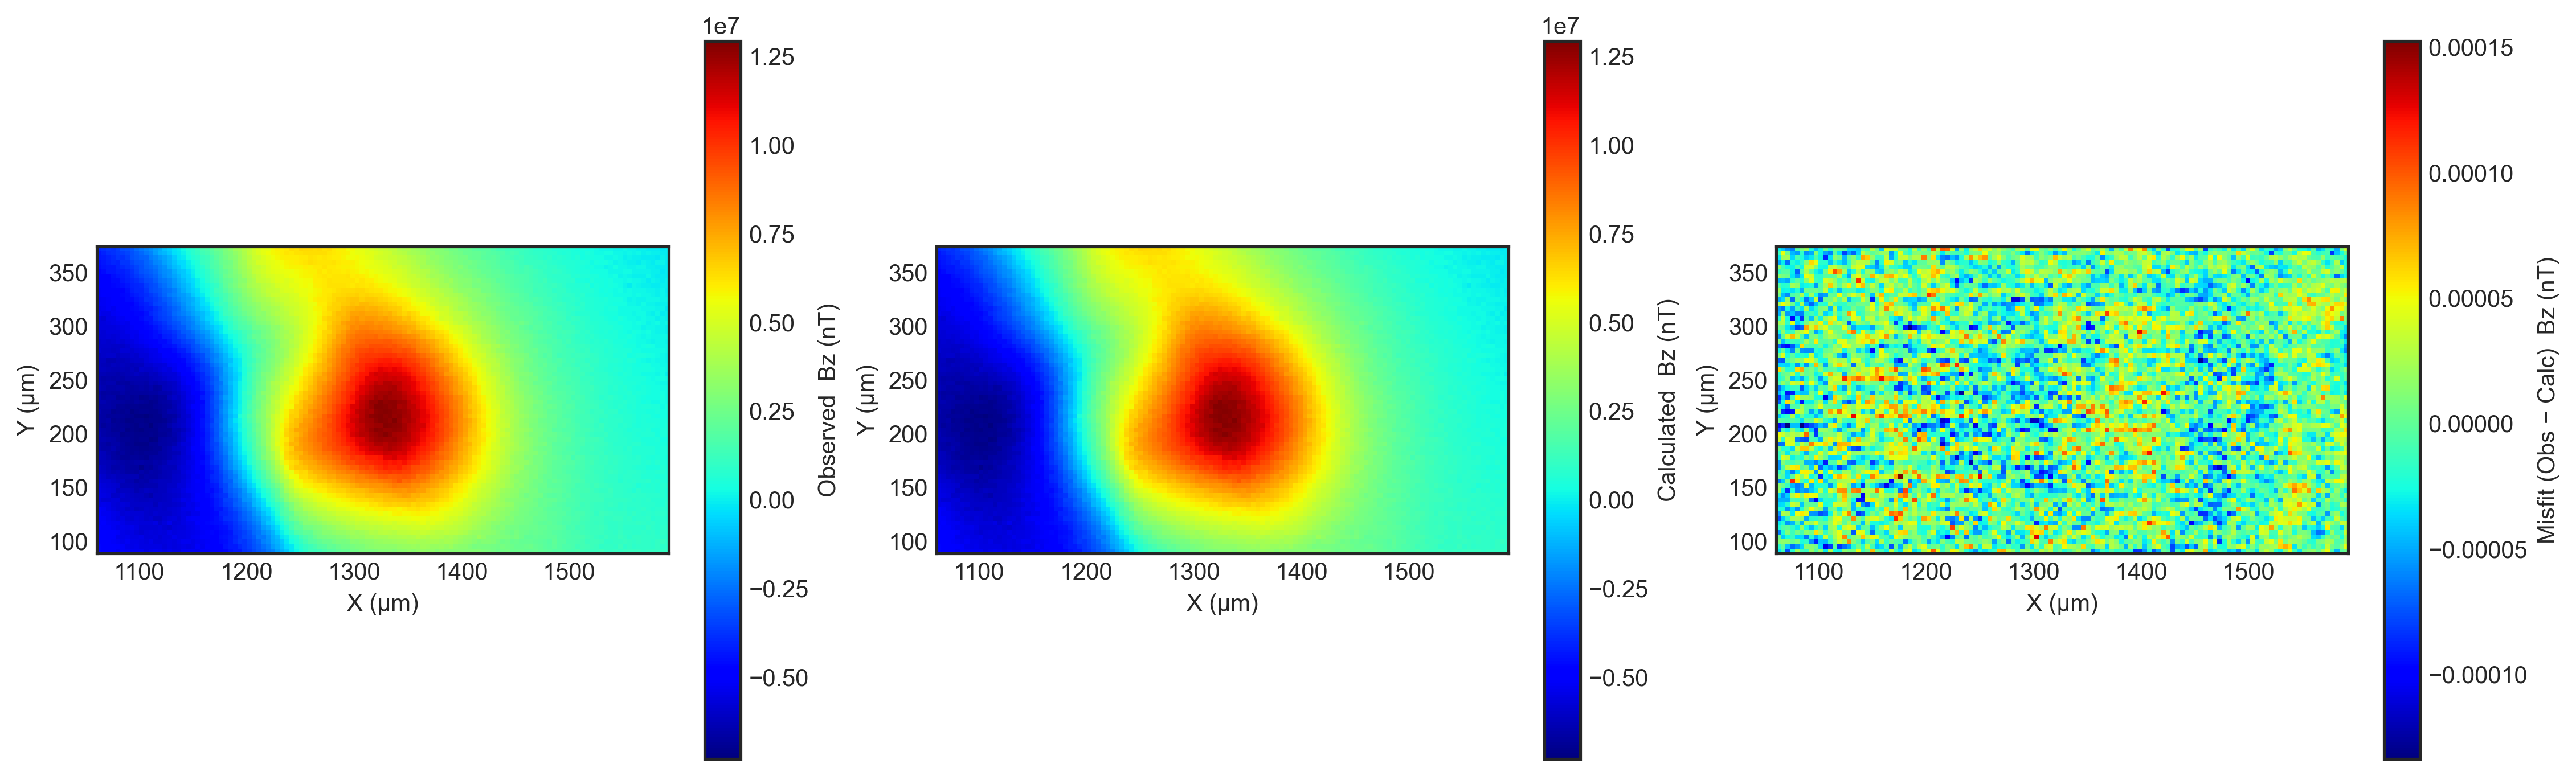

   Saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003\Blob_003_misfit.png

Processing Blob_005


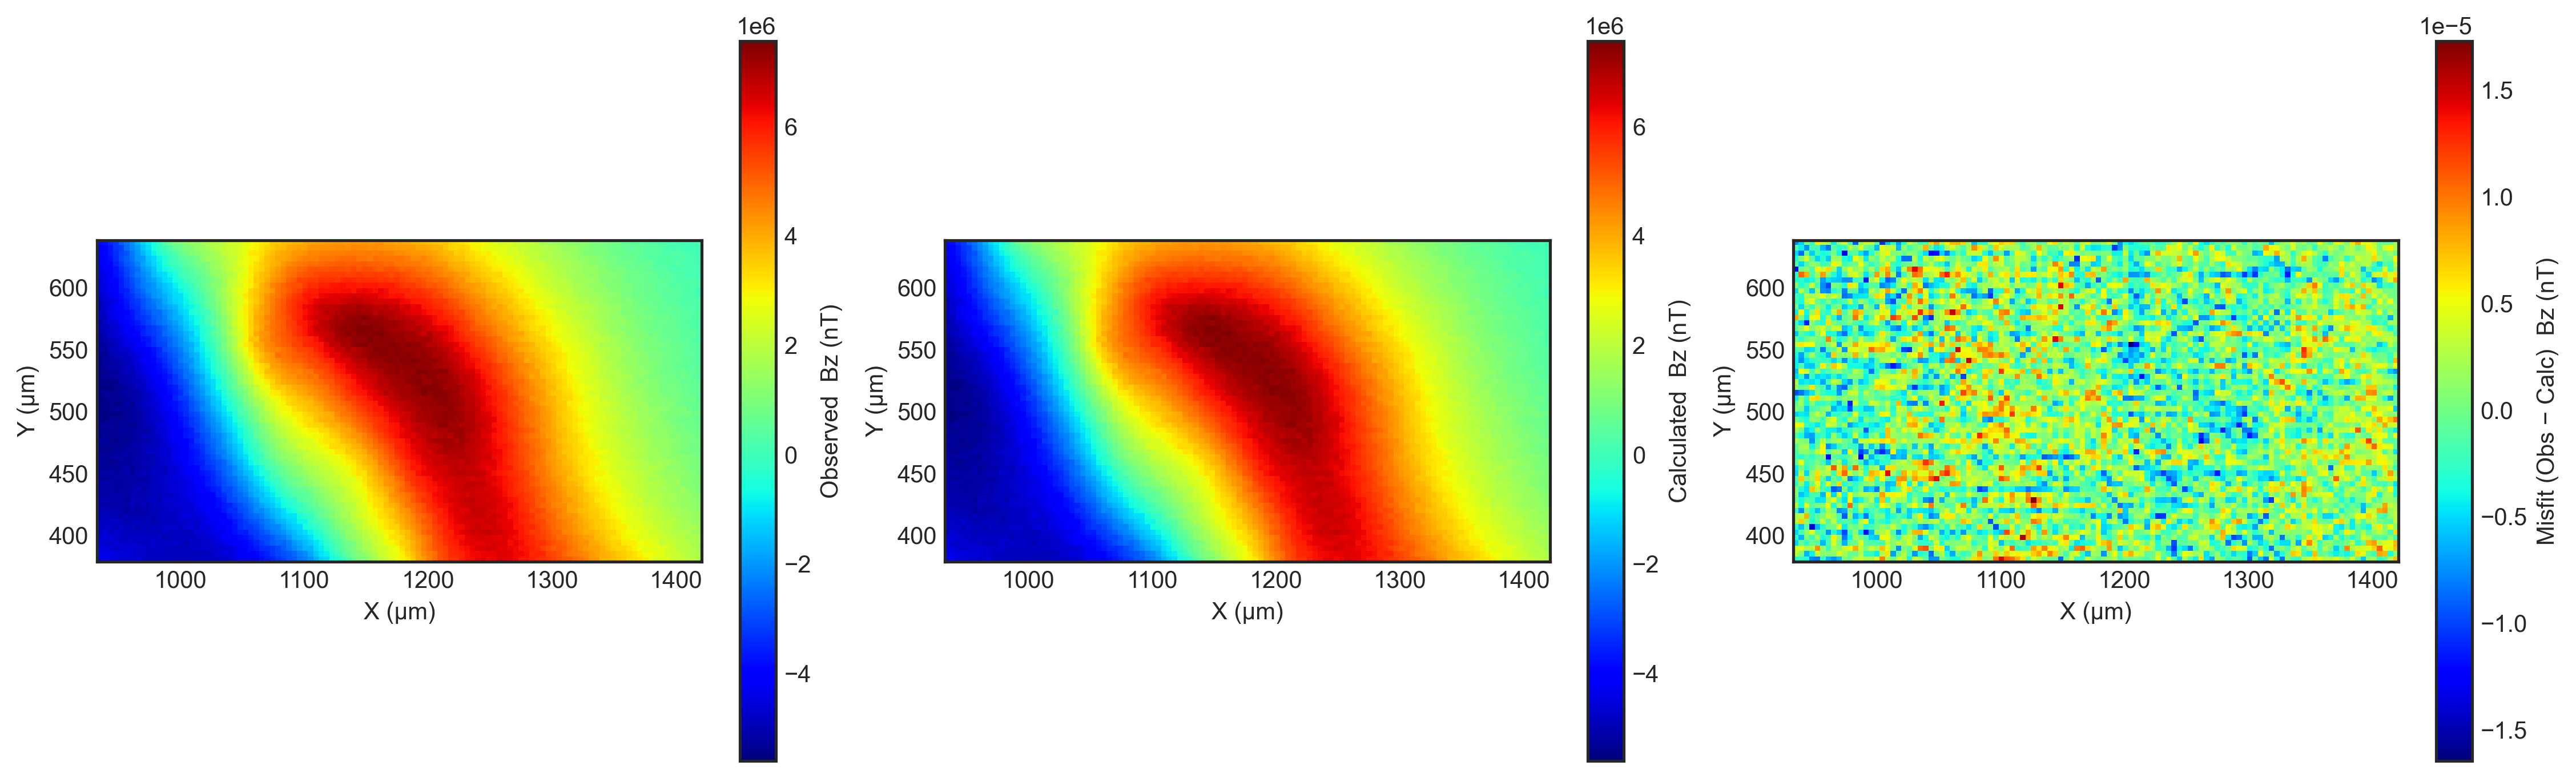

   Saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_005\Blob_005_misfit.png

Processing Blob_006


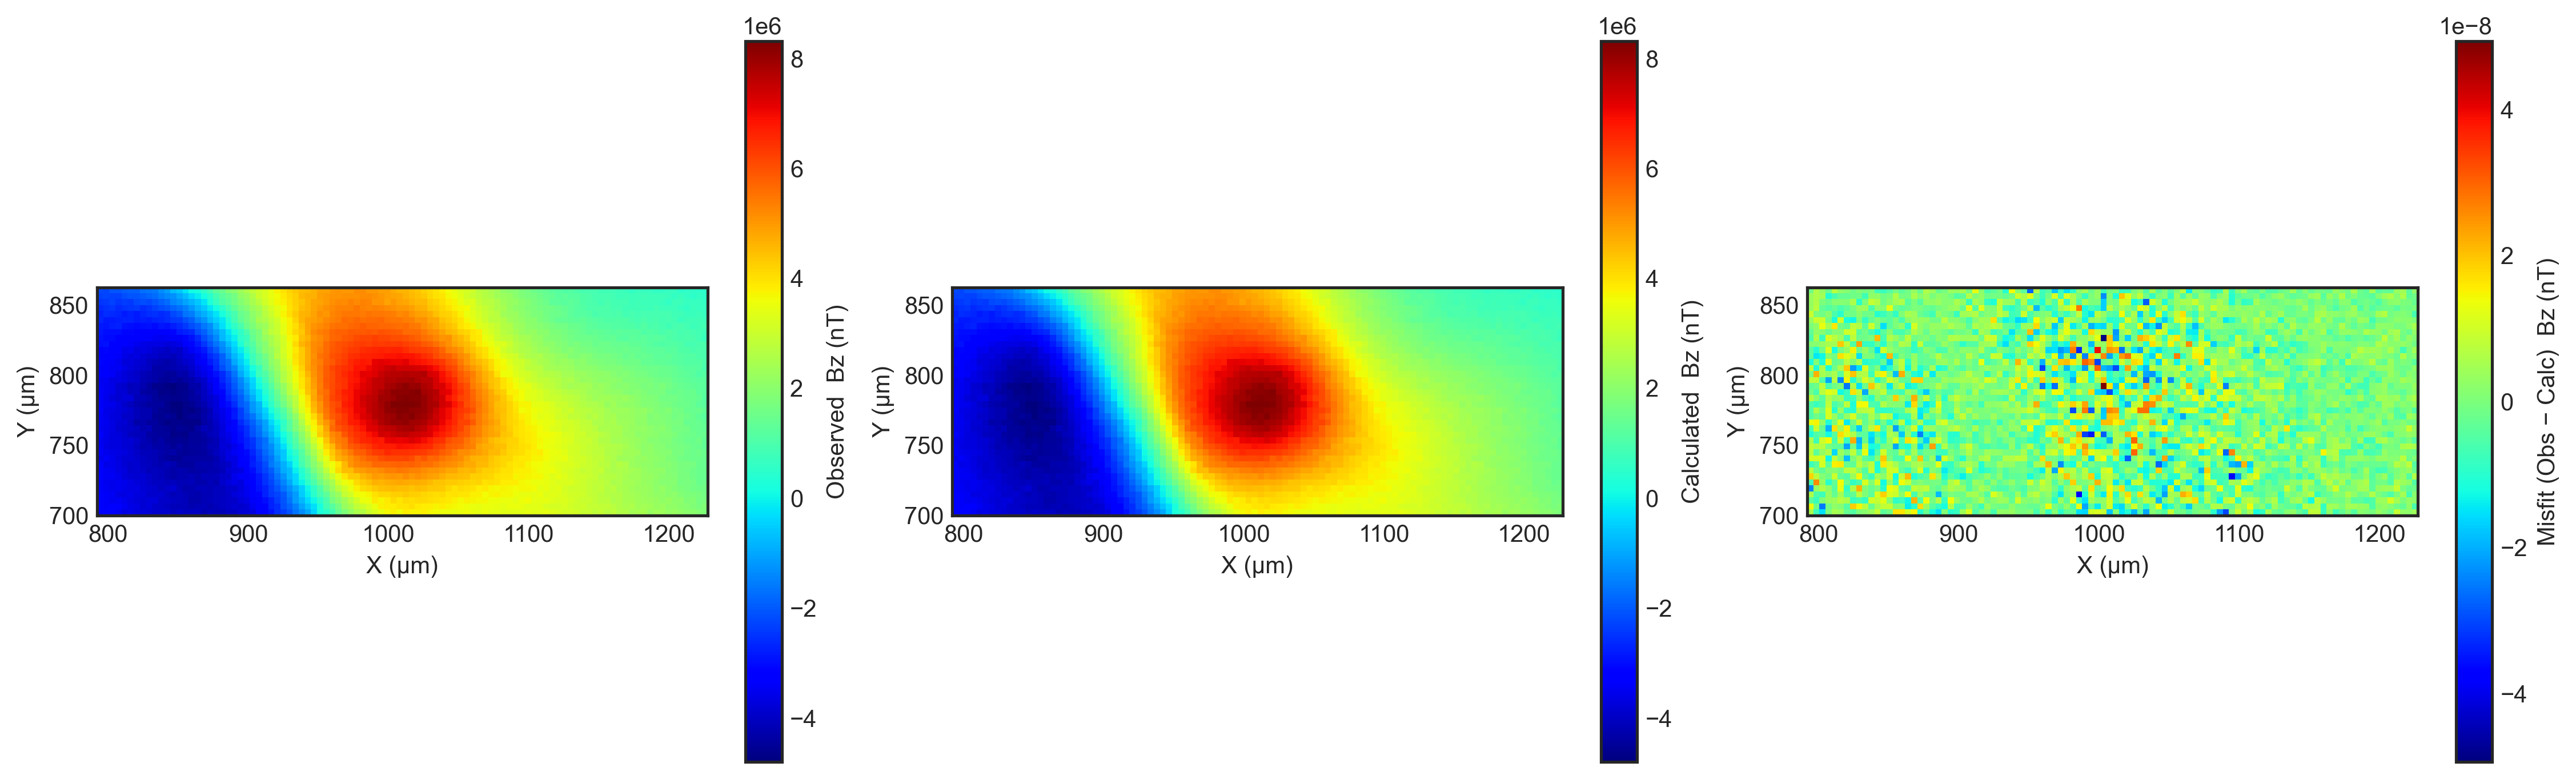

   Saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_006\Blob_006_misfit.png

Processing Blob_007


In [ ]:


# ------------------------------------------------
# Root folder containing Blob_XXX subfolders
# ------------------------------------------------
root_out = os.path.join(base_dir, "4-3D_Inversion_Filtered", "Tomofast_Output_Blobs")

# ------------------------------------------------
# Helpers
# ------------------------------------------------
def load_field_table(path, names=("x", "y", "z", "value")):
    return pd.read_csv(path, delim_whitespace=True, names=list(names))
    #return pd.read_csv(path, sep=r"\s+", names=list(names)) #alternative if error
    
def clean_df(df):
    df["x"] = pd.to_numeric(df["x"], errors="coerce")
    df["y"] = pd.to_numeric(df["y"], errors="coerce")
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = df.dropna(subset=["x", "y", "value"])
    df = df[np.isfinite(df["x"]) & np.isfinite(df["y"]) & np.isfinite(df["value"])]
    return df

def df_to_grid(df):
    xs = np.sort(df["x"].unique())
    ys = np.sort(df["y"].unique())
    if xs.size == 0 or ys.size == 0:
        return None, None, None
    grid = df.pivot_table(index="y", columns="x", values="value")
    grid = grid.reindex(index=ys, columns=xs)
    return grid.values, xs, ys

# ------------------------------------------------
# Loop over blobs
# ------------------------------------------------
blob_dirs = sorted(d for d in os.listdir(root_out) if d.startswith("Blob_"))

print("Found blobs:", blob_dirs)

for blob in blob_dirs:
    print(f"\nProcessing {blob}")

    data_dir = os.path.join(root_out, blob, blob, "data")

    obs_file    = os.path.join(data_dir, "mag_observed_data.txt")
    calc_file   = os.path.join(data_dir, "mag_calc_final_data.txt")
    misfit_file = os.path.join(data_dir, "mag_misfit_final_data.txt")

    # check files exist (skip blob if any missing)
    missing = False
    for f in [obs_file, calc_file, misfit_file]:
        if not os.path.exists(f):
            print("   Missing:", f)
            missing = True
    if missing:
        continue

    # load + clean
    obs_df    = clean_df(load_field_table(obs_file))
    calc_df   = clean_df(load_field_table(calc_file))
    misfit_df = clean_df(load_field_table(misfit_file))

    if obs_df.empty or calc_df.empty or misfit_df.empty:
        print(f"   Empty/invalid data after cleaning for {blob}, skipping.")
        continue

    # grid
    obs_grid, xs, ys      = df_to_grid(obs_df)
    calc_grid, xs2, ys2   = df_to_grid(calc_df)
    misfit_grid, xs3, ys3 = df_to_grid(misfit_df)

    if obs_grid is None or calc_grid is None or misfit_grid is None:
        print(f"   No valid grid for {blob}, skipping.")
        continue

    # use observed grid coords for extent (paper axes in Mm)
    extent = [xs.min(), xs.max(), ys.min(), ys.max()]
    if not np.all(np.isfinite(extent)):
        print(f"   Bad extent (NaN/Inf) for {blob}, skipping.")
        continue

    # ------------------------------------------------
    # Plot 3-panel figure
    # ------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=300)

    for ax, grid, cbar_label in zip(
        axes,
        [obs_grid, calc_grid, misfit_grid],
        ["Observed", "Calculated", "Misfit (Obs − Calc)"]
    ):
        im = ax.imshow(
            grid,
            origin="lower",
            cmap="jet",
            extent=extent,
            aspect="equal"
        )

    
        ax.set_xlabel("X (µm)")
        ax.set_ylabel("Y (µm)")
        ax.margins(0)

        cbar = plt.colorbar(im, ax=ax, shrink=0.85)
        #cbar.set_label(cbar_label)
        cbar.set_label(f"{cbar_label}  Bz (nT)")


    plt.tight_layout(pad=0.2)

    # save per blob
    out_png = os.path.join(root_out, blob, f"{blob}_misfit.png")
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"   Saved: {out_png}")

print("\nAll blob misfit plots done.")


### 8. 3D grains detection

this line uses scipy yo detect the 3d grains models based on cell connectivity and amplitude thresholds, calculate mean results per grain, and save 3d plots
* User: Attention: change cell size for mean magnitude (dx,dy,dz)

In [15]:
# grains extraction

# ------------------------------------------------------------
#  PATHS 
# ------------------------------------------------------------
# Root folder that contains Blob_001, Blob_002, ...
BLOB_ROOT = os.path.join(base_dir, "4-3D_Inversion_Filtered","Tomofast_Output_Blobs")

# Folder that contains Meshgrid_Blob_001.txt, Meshgrid_Blob_002.txt, ...
MESH_ROOT = os.path.join(base_dir, "4-3D_Inversion_Filtered","Blob_Meshgrids")

# thresholds
threshold_list = np.arange(0.1, 1.0, 0.1)  # 0.1..0.9

# 26-connectivity in 3D
structure = generate_binary_structure(3, 3)

# ------------------------------------------------------------
# LOOP BLOBS
# ------------------------------------------------------------
blob_dirs = sorted(
    d for d in os.listdir(BLOB_ROOT)
    if d.startswith("Blob_") and os.path.isdir(os.path.join(BLOB_ROOT, d))
)

print("Found blobs:", blob_dirs)

for blob in blob_dirs:
    print("\n===================================================")
    print("Processing", blob)
    print("===================================================")

    # Your structure: Blob_001/Blob_001/model/...
    model_file = os.path.join(BLOB_ROOT, blob, blob, "model", "mag_final_model_full.txt")
    mesh_file  = os.path.join(MESH_ROOT, f"Meshgrid_Blob_{blob.split('_')[1]}.txt")  # uses 001 etc.

    if not os.path.exists(model_file):
        print("   Missing model:", model_file)
        continue
    if not os.path.exists(mesh_file):
        print("   Missing mesh :", mesh_file)
        continue

    # ------------------------------------------------------------
    # 1) Load magnetization model
    # ------------------------------------------------------------
    data = np.genfromtxt(model_file, skip_header=1)

    # Tomofast model file expected columns: Mx My Mz ...
    Mx = data[:, 0]
    My = data[:, 1]
    Mz = data[:, 2]

    mag = np.sqrt(Mx**2 + My**2 + Mz**2)

    # ------------------------------------------------------------
    # 2) Load mesh (cell bounds) -> centers
    # ------------------------------------------------------------
    mesh = np.genfromtxt(mesh_file, skip_header=1)

    x_centers = (mesh[:, 0] + mesh[:, 1]) / 2
    y_centers = (mesh[:, 2] + mesh[:, 3]) / 2
    z_centers = (mesh[:, 4] + mesh[:, 5]) / 2

    # Infer nx, ny, nz from mesh size (IMPORTANT for per-blob)
    n_cells = mesh.shape[0]
    # For uniform grids: n_cells = nx * ny * nz

    nx = len(np.unique(x_centers))
    ny = len(np.unique(y_centers))
    nz = int(n_cells / (nx * ny))

    if nx * ny * nz != n_cells:
        print(f"   Cannot infer nx,ny,nz correctly for {blob}.")
        print(f"     nx*ny*nz={nx*ny*nz} but n_cells={n_cells}")
        continue

    print(f"  Mesh dims inferred: nx={nx}, ny={ny}, nz={nz}")

    # ------------------------------------------------------------
    # LOOP THRESHOLDS
    # ------------------------------------------------------------
    for threshold_per in threshold_list:
        print(f"   -> threshold = {threshold_per:.1f}")

        threshold = threshold_per * mag.max()
        mask = mag > threshold

        # reshape into (nz, ny, nx) like your original script
        mask_3d = mask.reshape((nz, ny, nx))

        labeled_grains_3d, num_grains = label(mask_3d, structure=structure)
        print(f"      grains detected: {num_grains}")

        # dataframe
        df = pd.DataFrame({
            "X": x_centers.ravel(),
            "Y": y_centers.ravel(),
            "Z": -1 * z_centers.ravel(),     # keep your sign convention
            "GrainID": labeled_grains_3d.ravel(),
            "Mx": Mx,
            "My": My,
            "Mz": Mz
        })

        df = df[df["GrainID"] != 0]

        # save inside each blob folder
        out_folder = os.path.join(BLOB_ROOT, blob, blob, "Grains_detection")
        os.makedirs(out_folder, exist_ok=True)

        csv_file = os.path.join(out_folder, f"grain_labels_{threshold_per:.1f}.csv")
        df.to_csv(csv_file, index=False)

        print(f"      saved: {csv_file}")

print("\nDONE.")


      saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003\Blob_003\Grains_detection\grain_labels_0.6.csv
   -> threshold = 0.7
      grains detected: 31
      saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003\Blob_003\Grains_detection\grain_labels_0.7.csv
   -> threshold = 0.8
      grains detected: 10
      saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003\Blob_003\Grains_detection\grain_labels_0.8.csv
   -> threshold = 0.9
      grains detected: 5
      saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003\Blob_003\Grains_detection\grain_labels_0.9.csv

Processing Blob_005
  Mesh dims inferred: nx=152, ny=100, nz=120
   -> threshold = 0.1
      grains detected: 1
      saved: D:\My_Work\Tomofast

In [16]:
# grains extraction largest picking (same as above but this keeps only the largest grains per blob) useful for flitering compression artifacts 

# ------------------------------------------------------------
#   PATHS 
# ------------------------------------------------------------
BLOB_ROOT = os.path.join(base_dir, "4-3D_Inversion_Filtered", "Tomofast_Output_Blobs")
MESH_ROOT = os.path.join(base_dir, "4-3D_Inversion_Filtered", "Blob_Meshgrids")

threshold_list = np.arange(0.1, 1.0, 0.1)  # 0.1..0.9

# 26-connectivity in 3D
structure = generate_binary_structure(3, 3)

# ------------------------------------------------------------
# LOOP BLOBS
# ------------------------------------------------------------
blob_dirs = sorted(
    d for d in os.listdir(BLOB_ROOT)
    if d.startswith("Blob_") and os.path.isdir(os.path.join(BLOB_ROOT, d))
)

print("Found blobs:", blob_dirs)

for blob in blob_dirs:
    print("\n===================================================")
    print("Processing", blob)
    print("===================================================")

    # Your structure: Blob_001/Blob_001/model/...
    model_file = os.path.join(BLOB_ROOT, blob, blob, "model", "mag_final_model_full.txt")
    mesh_file  = os.path.join(MESH_ROOT, f"Meshgrid_Blob_{blob.split('_')[1]}.txt")  # uses 001 etc.

    if not os.path.exists(model_file):
        print("   Missing model:", model_file)
        continue
    if not os.path.exists(mesh_file):
        print("   Missing mesh :", mesh_file)
        continue

    # Output folder for this blob
    out_folder = os.path.join(BLOB_ROOT, blob, blob, "Grains_detection")
    os.makedirs(out_folder, exist_ok=True)

    # Will store largest grain info per threshold (one row per threshold)
    blob_largest_summary = []

    # ------------------------------------------------------------
    # 1) Load magnetization model
    # ------------------------------------------------------------
    data = np.genfromtxt(model_file, skip_header=1)

    # Tomofast model file expected columns: Mx My Mz ...
    Mx = data[:, 0]
    My = data[:, 1]
    Mz = data[:, 2]

    mag = np.sqrt(Mx**2 + My**2 + Mz**2)

    # ------------------------------------------------------------
    # 2) Load mesh (cell bounds) -> centers
    # ------------------------------------------------------------
    mesh = np.genfromtxt(mesh_file, skip_header=1)

    x_centers = (mesh[:, 0] + mesh[:, 1]) / 2
    y_centers = (mesh[:, 2] + mesh[:, 3]) / 2
    z_centers = (mesh[:, 4] + mesh[:, 5]) / 2

    # Infer nx, ny, nz from mesh size
    n_cells = mesh.shape[0]
    nx = len(np.unique(x_centers))
    ny = len(np.unique(y_centers))
    nz = int(n_cells / (nx * ny))

    if nx * ny * nz != n_cells:
        print(f"   Cannot infer nx,ny,nz correctly for {blob}.")
        print(f"     nx*ny*nz={nx*ny*nz} but n_cells={n_cells}")
        continue

    print(f"  Mesh dims inferred: nx={nx}, ny={ny}, nz={nz}")

    # ------------------------------------------------------------
    # LOOP THRESHOLDS
    # ------------------------------------------------------------
    for threshold_per in threshold_list:
        thr_str = f"{threshold_per:.1f}"
        print(f"   -> threshold = {thr_str}")

        threshold = threshold_per * mag.max()
        mask = mag > threshold

        # reshape into (nz, ny, nx)
        mask_3d = mask.reshape((nz, ny, nx))

        labeled_grains_3d, num_grains = label(mask_3d, structure=structure)
        print(f"      grains detected: {num_grains}")

        # Build voxel table for ALL grains
        df = pd.DataFrame({
            "X": x_centers.ravel(),
            "Y": y_centers.ravel(),
            "Z": -1 * z_centers.ravel(),     # keep your sign convention
            "GrainID": labeled_grains_3d.ravel(),
            "Mx": Mx,
            "My": My,
            "Mz": Mz
        })

        # remove background
        df = df[df["GrainID"] != 0]

        # --- Save original labels file ---
        csv_file = os.path.join(out_folder, f"grain_labels_{thr_str}.csv")
        df.to_csv(csv_file, index=False)
        print(f"       saved: {csv_file}")

        # --- If no grains, skip largest outputs ---
        if df.empty:
            print("      (no voxels above threshold) skip largest")
            continue

        # --- Pick largest grain by voxel count ---
        # counts is a Series: index=GrainID, value=num voxels
        counts = df["GrainID"].value_counts()
        largest_id = int(counts.idxmax())
        largest_nvox = int(counts.max())

        df_largest = df[df["GrainID"] == largest_id].copy()

        largest_csv = os.path.join(out_folder, f"grain_labels_largest_{thr_str}.csv")
        df_largest.to_csv(largest_csv, index=False)
        print(f"       saved largest: {largest_csv} (GrainID={largest_id}, Num_Voxels={largest_nvox})")

        # store summary row for this threshold
        blob_largest_summary.append({
            "Blob": blob,
            "Threshold": float(threshold_per),
            "Threshold_abs": float(threshold),   # threshold in mag units (same as mag)
            "Largest_GrainID": largest_id,
            "Num_Voxels": largest_nvox
        })

    # ------------------------------------------------------------
    # Save per-blob ALL-threshold summary
    # ------------------------------------------------------------
    if blob_largest_summary:
        summary_df = pd.DataFrame(blob_largest_summary).sort_values("Threshold")
        summary_path = os.path.join(out_folder, "grain_labels_largest_ALL.csv")
        summary_df.to_csv(summary_path, index=False)
        print(f"\n   saved blob largest summary: {summary_path}")
    else:
        print("\n  (no largest summary rows written for this blob)")

print("\nDONE.")


Found blobs: ['Blob_003', 'Blob_005', 'Blob_006', 'Blob_007']

Processing Blob_003
  Mesh dims inferred: nx=162, ny=106, nz=120
   -> threshold = 0.1
      grains detected: 1
       saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003\Blob_003\Grains_detection\grain_labels_0.1.csv
       saved largest: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003\Blob_003\Grains_detection\grain_labels_largest_0.1.csv (GrainID=1, Num_Voxels=1413014)
   -> threshold = 0.2
      grains detected: 3
       saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003\Blob_003\Grains_detection\grain_labels_0.2.csv
       saved largest: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003\Blob_003\Grains_detection\grain_labels_largest_0.2.cs

In [17]:
#3d grains plots (Use paraview for better 3d visualziations)


# ------------------------------------------------------------
#   PATHS
# ------------------------------------------------------------
# Root folder that contains Blob_001, Blob_002, ...
BLOB_ROOT = os.path.join(base_dir, "4-3D_Inversion_Filtered","Tomofast_Output_Blobs")

# Folder that contains Meshgrid_Blob_001.txt, Meshgrid_Blob_002.txt, ...
MESH_ROOT = os.path.join(base_dir, "4-3D_Inversion_Filtered","Blob_Meshgrids")

threshold_list = np.arange(0.1, 1.0, 0.1)  # 0.1 .. 0.9
structure = generate_binary_structure(3, 3)  # 26-connectivity

# ------------------------------------------------------------
# Find blobs
# ------------------------------------------------------------
blob_dirs = sorted(
    d for d in os.listdir(BLOB_ROOT)
    if d.startswith("Blob_") and os.path.isdir(os.path.join(BLOB_ROOT, d))
)

print("Found blobs:", blob_dirs)

# ------------------------------------------------------------
# LOOP BLOBS
# ------------------------------------------------------------
for blob in blob_dirs:
    print("\n===================================================")
    print("Processing", blob)
    print("===================================================")

    #  structure: Blob_001/Blob_001/model/mag_final_model_full.txt
    model_file = os.path.join(BLOB_ROOT, blob, blob, "model", "mag_final_model_full.txt")

    # Meshgrid_Blob_001.txt etc (blob number is "001")
    blob_num = blob.split("_")[1]
    mesh_file = os.path.join(MESH_ROOT, f"Meshgrid_Blob_{blob_num}.txt")

    if not os.path.exists(model_file):
        print("   Missing model:", model_file)
        continue
    if not os.path.exists(mesh_file):
        print("   Missing mesh :", mesh_file)
        continue

    # ------------------------------------------------------------
    # Load model (Mx, My, Mz)
    # ------------------------------------------------------------
    model = np.genfromtxt(model_file, skip_header=1)
    Mx = model[:, 0]
    My = model[:, 1]
    Mz = model[:, 2]
    mag = np.sqrt(Mx**2 + My**2 + Mz**2)

    # ------------------------------------------------------------
    # Load mesh -> centers
    # ------------------------------------------------------------
    mesh = np.genfromtxt(mesh_file, skip_header=1)
    x_centers = (mesh[:, 0] + mesh[:, 1]) / 2
    y_centers = (mesh[:, 2] + mesh[:, 3]) / 2
    z_centers = (mesh[:, 4] + mesh[:, 5]) / 2

    # Infer nx, ny, nz per blob 
    n_cells = mesh.shape[0]
    nx = len(np.unique(x_centers))
    ny = len(np.unique(y_centers))
    nz = int(n_cells / (nx * ny))

    if nx * ny * nz != n_cells:
        print(f"   Bad dims: nx*ny*nz={nx*ny*nz} but cells={n_cells}")
        continue

    print(f"  Mesh dims: nx={nx}, ny={ny}, nz={nz}")

    # Output folder inside each blob
    out_folder = os.path.join(BLOB_ROOT, blob, blob, "Grains_detection_3D")
    os.makedirs(out_folder, exist_ok=True)

    # ------------------------------------------------------------
    # LOOP THRESHOLDS
    # ------------------------------------------------------------
    for threshold_per in threshold_list:
        print(f"   -> threshold = {threshold_per:.1f}")

        threshold = threshold_per * mag.max()
        mask = mag > threshold
        mask_3d = mask.reshape((nz, ny, nx))

        labeled_grains_3d, num_grains = label(mask_3d, structure=structure)
        print(f"      grains detected: {num_grains}")

        df = pd.DataFrame({
            "X": x_centers,
            "Y": y_centers,
            "Z": -1 * z_centers,
            "GrainID": labeled_grains_3d.ravel(),
            "Mx": Mx,
            "My": My,
            "Mz": Mz
        })
        df = df[df["GrainID"] != 0]

        # If nothing to plot, skip
        if len(df) == 0:
            print("      (no points above threshold) skip plot")
            continue

        # ------------------------------------------------
        # 3D Plot (sample for speed)
        # ------------------------------------------------
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection="3d")

        sample_df = df.sample(min(5000, len(df)), random_state=42)

        sc = ax.scatter(
            sample_df["X"],
            sample_df["Y"],
            sample_df["Z"],
            c=sample_df["GrainID"],
            cmap="turbo",
            s=5
        )

        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_zlabel("Z")
        ax.set_title(f"{blob} — 3D Grains (thr={threshold_per:.1f}, n={num_grains})")
        ax.invert_zaxis()

        plt.colorbar(sc, label="Grain ID")

        out_fig = os.path.join(out_folder, f"{blob}_grains_3D_{threshold_per:.1f}.png")
        plt.savefig(out_fig, dpi=300, bbox_inches="tight")
        plt.close(fig)

        print(f"      saved: {out_fig}")

print("\nDONE.")


Found blobs: ['Blob_003', 'Blob_005', 'Blob_006', 'Blob_007']

Processing Blob_003
  Mesh dims: nx=162, ny=106, nz=120
   -> threshold = 0.1
      grains detected: 1
      saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003\Blob_003\Grains_detection_3D\Blob_003_grains_3D_0.1.png
   -> threshold = 0.2
      grains detected: 3
      saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003\Blob_003\Grains_detection_3D\Blob_003_grains_3D_0.2.png
   -> threshold = 0.3
      grains detected: 12
      saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003\Blob_003\Grains_detection_3D\Blob_003_grains_3D_0.3.png
   -> threshold = 0.4
      grains detected: 44
      saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003

In [18]:
# 3D calculations (this is mean per grain not dipole result)
# User: Attention: change cell size for dipole moment
# ------------------------------------------------------------
#   PATH
# ------------------------------------------------------------
BLOB_ROOT = os.path.join(base_dir, "4-3D_Inversion_Filtered","Tomofast_Output_Blobs")

# Cell size 
dx = dy = dz = 4.4
V = dx * dy * dz

threshold_list = np.arange(0.1, 1.0, 0.1)  # 0.1..0.9

# ------------------------------------------------------------
# Find blob folders
# ------------------------------------------------------------
blob_dirs = sorted(
    d for d in os.listdir(BLOB_ROOT)
    if d.startswith("Blob_") and os.path.isdir(os.path.join(BLOB_ROOT, d))
)

print("Found blobs:", blob_dirs)

# ------------------------------------------------------------
# LOOP BLOBS
# ------------------------------------------------------------
for blob in blob_dirs:
    print("\n===================================================")
    print("Processing", blob)
    print("===================================================")

    #  structure: Blob_001/Blob_001/Grains_detection
    grains_folder = os.path.join(BLOB_ROOT, blob, blob, "Grains_detection")

    if not os.path.isdir(grains_folder):
        print("   Missing Grains_detection folder:", grains_folder)
        print("     (Run the grain_labels script first for this blob.)")
        continue

    # output folder (same)
    out_folder = grains_folder

    for threshold_per in threshold_list:
        print(f"\n  === threshold {threshold_per:.1f} ===")

        in_name = f"grain_labels_{threshold_per:.1f}.csv"
        csv_path = os.path.join(grains_folder, in_name)

        if not os.path.exists(csv_path):
            print("    Missing:", csv_path)
            continue

        df = pd.read_csv(csv_path)
        if df.empty:
            print("   (empty file) skip")
            continue

        results = []

        for grain_id, group in df.groupby("GrainID"):
            vectors = group[["Mx", "My", "Mz"]].to_numpy()
            n_vectors = len(vectors)

            mean_Mx, mean_My, mean_Mz = vectors.mean(axis=0)
            mean_vec = np.array([mean_Mx, mean_My, mean_Mz])

            mags = np.linalg.norm(vectors, axis=1)
            mean_magnitude = mags.mean()

            mean_vec_length = np.linalg.norm(mean_vec)
            if mean_magnitude > 0:
                R = mean_vec_length / mean_magnitude
            else:
                R = np.nan

            # angular standard deviation (fix nan logic)
            if (not np.isnan(R)) and (R > 0):
                sigma_rad = np.sqrt(-2 * np.log(R))
                sigma_deg = np.degrees(sigma_rad)
            else:
                sigma_deg = np.nan

            # dec/inc
            m = mean_vec_length
            if m == 0:
                dec, inc = np.nan, np.nan
            else:
                theta = np.degrees(np.arccos(mean_Mz / m))
                phi   = np.degrees(np.arctan2(mean_My, mean_Mx))
                inc = 90.0 - theta
                dec = phi
                if dec < 0:
                    dec += 360.0

            # moment amplitude
            moment_amp = mean_magnitude * V

            # moment-weighted dipole position
            Mi = mags
            Xi = group["X"].to_numpy()
            Yi = group["Y"].to_numpy()
            Zi = group["Z"].to_numpy()

            weight = Mi * V
            w_sum = weight.sum()

            if w_sum > 0:
                r_dip_x = (weight * Xi).sum() / w_sum
                r_dip_y = (weight * Yi).sum() / w_sum
                r_dip_z = (weight * Zi).sum() / w_sum
            else:
                r_dip_x = r_dip_y = r_dip_z = np.nan

            results.append({
                "Blob": blob,
                "Threshold": float(threshold_per),
                "GrainID": int(grain_id),
                "Num_Voxels": int(n_vectors),
                "Mx_mean": mean_Mx,
                "My_mean": mean_My,
                "Mz_mean": mean_Mz,
                "Mean_Magnitude": mean_magnitude,
                "Mean_Moment_Amplitude": moment_amp,
                "Resultant_R": R,
                "Angular_STD_deg": sigma_deg,
                "Dec": dec,
                "Inc": inc,
                "Dipole_X": r_dip_x,
                "Dipole_Y": r_dip_y,
                "Dipole_Z": r_dip_z,
            })

        out_name = f"grain_dec_inc_{threshold_per:.1f}.csv"
        out_path = os.path.join(out_folder, out_name)

        out_df = pd.DataFrame(results)
        out_df.to_csv(out_path, index=False)

        print("    Saved:", out_path)
        print(out_df.head())

print("\nDONE.")


Found blobs: ['Blob_003', 'Blob_005', 'Blob_006', 'Blob_007']

Processing Blob_003

  === threshold 0.1 ===
    Saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003\Blob_003\Grains_detection\grain_dec_inc_0.1.csv
       Blob  Threshold  GrainID  Num_Voxels      Mx_mean     My_mean  \
0  Blob_003        0.1        1     1413014 -2287.272527 -949.529553   

      Mz_mean  Mean_Magnitude  Mean_Moment_Amplitude  Resultant_R  \
0  2198.20114    11088.493337           944562.21639     0.298633   

   Angular_STD_deg         Dec        Inc     Dipole_X    Dipole_Y    Dipole_Z  
0        89.077511  202.545105  41.592639  1267.959646  228.149595 -318.645148  

  === threshold 0.2 ===
    Saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003\Blob_003\Grains_detection\grain_dec_inc_0.2.csv
       Blob  Threshold  GrainID  Num_Voxels      Mx_mean      My_me

In [19]:
# calculations  + largest grains (filter errors) (same as above but this keeps only the largest grains per blob) useful for flitering compression artifacts 

# ------------------------------------------------------------
#   PATH
# ------------------------------------------------------------
BLOB_ROOT = os.path.join(base_dir, "4-3D_Inversion_Filtered", "Tomofast_Output_Blobs")

# Cell size 
dx = dy = dz = 4.4
V = dx * dy * dz

threshold_list = np.arange(0.1, 1.0, 0.1)  # 0.1..0.9

# ------------------------------------------------------------
# Find blob folders
# ------------------------------------------------------------
blob_dirs = sorted(
    d for d in os.listdir(BLOB_ROOT)
    if d.startswith("Blob_") and os.path.isdir(os.path.join(BLOB_ROOT, d))
)

print("Found blobs:", blob_dirs)

# ------------------------------------------------------------
# LOOP BLOBS
# ------------------------------------------------------------
for blob in blob_dirs:
    print("\n===================================================")
    print("Processing", blob)
    print("===================================================")

    #  structure: Blob_001/Blob_001/Grains_detection
    grains_folder = os.path.join(BLOB_ROOT, blob, blob, "Grains_detection")

    if not os.path.isdir(grains_folder):
        print("   Missing Grains_detection folder:", grains_folder)
        print("     (Run the grain_labels script first for this blob.)")
        continue

    # output folder (same)
    out_folder = grains_folder

    # Collect "largest grain per threshold" for this blob
    blob_largest_rows = []

    for threshold_per in threshold_list:
        thr_str = f"{threshold_per:.1f}"
        print(f"\n  === threshold {thr_str} ===")

        in_name = f"grain_labels_{thr_str}.csv"
        csv_path = os.path.join(grains_folder, in_name)

        if not os.path.exists(csv_path):
            print("    Missing:", csv_path)
            continue

        df = pd.read_csv(csv_path)
        if df.empty:
            print("   (empty file) skip")
            continue

        results = []

        for grain_id, group in df.groupby("GrainID"):
            vectors = group[["Mx", "My", "Mz"]].to_numpy()
            n_vectors = len(vectors)

            mean_Mx, mean_My, mean_Mz = vectors.mean(axis=0)
            mean_vec = np.array([mean_Mx, mean_My, mean_Mz], dtype=float)

            mags = np.linalg.norm(vectors, axis=1)
            mean_magnitude = float(mags.mean()) if len(mags) else np.nan

            mean_vec_length = float(np.linalg.norm(mean_vec))
            if mean_magnitude and mean_magnitude > 0:
                R = mean_vec_length / mean_magnitude
            else:
                R = np.nan

            # angular standard deviation
            if (not np.isnan(R)) and (R > 0):
                sigma_rad = np.sqrt(-2.0 * np.log(R))
                sigma_deg = float(np.degrees(sigma_rad))
            else:
                sigma_deg = np.nan

            # dec/inc
            m = mean_vec_length
            if m == 0 or np.isnan(m):
                dec, inc = np.nan, np.nan
            else:
                theta = float(np.degrees(np.arccos(mean_Mz / m)))
                phi   = float(np.degrees(np.arctan2(mean_My, mean_Mx)))
                inc = 90.0 - theta
                dec = phi if phi >= 0 else phi + 360.0

            # moment amplitude
            moment_amp = mean_magnitude * V if not np.isnan(mean_magnitude) else np.nan

            # moment-weighted dipole position
            Mi = mags
            Xi = group["X"].to_numpy()
            Yi = group["Y"].to_numpy()
            Zi = group["Z"].to_numpy()

            weight = Mi * V
            w_sum = float(weight.sum())

            if w_sum > 0:
                r_dip_x = float((weight * Xi).sum() / w_sum)
                r_dip_y = float((weight * Yi).sum() / w_sum)
                r_dip_z = float((weight * Zi).sum() / w_sum)
            else:
                r_dip_x = r_dip_y = r_dip_z = np.nan

            results.append({
                "Blob": blob,
                "Threshold": float(threshold_per),
                "GrainID": int(grain_id),
                "Num_Voxels": int(n_vectors),
                "Mx_mean": mean_Mx,
                "My_mean": mean_My,
                "Mz_mean": mean_Mz,
                "Mean_Magnitude": mean_magnitude,
                "Mean_Moment_Amplitude": moment_amp,
                "Resultant_R": R,
                "Angular_STD_deg": sigma_deg,
                "Dec": dec,
                "Inc": inc,
                "Dipole_X": r_dip_x,
                "Dipole_Y": r_dip_y,
                "Dipole_Z": r_dip_z,
            })

        # --- Save full per-grain results 
        out_name = f"grain_dec_inc_{thr_str}.csv"
        out_path = os.path.join(out_folder, out_name)

        out_df = pd.DataFrame(results)
        out_df.to_csv(out_path, index=False)
        print("    Saved:", out_path)

        # --- Pick + save ONLY the largest grain (by Num_Voxels) ---
        if out_df.empty:
            print("   (no grains computed) skip largest")
            continue

        largest_row = out_df.loc[out_df["Num_Voxels"].idxmax()].copy()

        out_largest_name = f"grain_dec_inc_largest_{thr_str}.csv"
        out_largest_path = os.path.join(out_folder, out_largest_name)

        pd.DataFrame([largest_row]).to_csv(out_largest_path, index=False)
        print("    Saved largest:", out_largest_path,
              f"(GrainID={int(largest_row['GrainID'])}, Num_Voxels={int(largest_row['Num_Voxels'])})")

        blob_largest_rows.append(largest_row)

    # --- Save "largest per threshold" summary for this blob ---
    if blob_largest_rows:
        blob_largest_df = pd.DataFrame(blob_largest_rows).sort_values("Threshold")
        blob_largest_all_path = os.path.join(out_folder, "grain_dec_inc_largest_ALL.csv")
        blob_largest_df.to_csv(blob_largest_all_path, index=False)
        print("\n    Saved blob largest summary:", blob_largest_all_path)

print("\nDONE.")


Found blobs: ['Blob_003', 'Blob_005', 'Blob_006', 'Blob_007']

Processing Blob_003

  === threshold 0.1 ===
    Saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003\Blob_003\Grains_detection\grain_dec_inc_0.1.csv
    Saved largest: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003\Blob_003\Grains_detection\grain_dec_inc_largest_0.1.csv (GrainID=1, Num_Voxels=1413014)

  === threshold 0.2 ===
    Saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003\Blob_003\Grains_detection\grain_dec_inc_0.2.csv
    Saved largest: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003\Blob_003\Grains_detection\grain_dec_inc_largest_0.2.csv (GrainID=1, Num_Voxels=1151293)

  === threshold 0.3 ===
    Saved: D:\My_Work\Tomofast-x-µ\Wor

### 9. Maximum cell Extraction
this line detects the 3d location of the maximum cell per grain (it will be used as a guide for the source location searching)
* User attention: we assume here the best amplitude threshold is 0.9 (change THR = 0.9 if wanted)
* the output maxi cells shouldn't be very deep; if so increase the padding to make sure the model is fully covered.

In [20]:
# creating max cells per threshold for each grain

# ------------------------------------------------------------
#   PATHS
# ------------------------------------------------------------
# Root folder that contains Blob_001, Blob_002, ...
BLOB_ROOT = os.path.join(base_dir, "4-3D_Inversion_Filtered","Tomofast_Output_Blobs")

# Folder that contains Meshgrid_Blob_001.txt, Meshgrid_Blob_002.txt, ...
MESH_ROOT = os.path.join(base_dir, "4-3D_Inversion_Filtered","Blob_Meshgrids")

TARGET_GRAIN_IDS = None  # or e.g. [1,2,3]
tol = 1e-6

threshold_list = np.arange(0.1, 1.0, 0.1)

# ------------------------------------------------------------
# Find blobs
# ------------------------------------------------------------
blob_dirs = sorted(
    d for d in os.listdir(BLOB_ROOT)
    if d.startswith("Blob_") and os.path.isdir(os.path.join(BLOB_ROOT, d))
)

print("Found blobs:", blob_dirs)

# ------------------------------------------------------------
# LOOP BLOBS
# ------------------------------------------------------------
for blob in blob_dirs:
    print("\n===================================================")
    print("Processing", blob)
    print("===================================================")

    blob_num = blob.split("_")[1]

    # Blob grain labels folder
    grains_folder = os.path.join(BLOB_ROOT, blob, blob, "Grains_detection")
    if not os.path.isdir(grains_folder):
        print("   Missing Grains_detection:", grains_folder)
        continue

    # Blob mesh file
    mesh_path = os.path.join(MESH_ROOT, f"Meshgrid_Blob_{blob_num}.txt")
    if not os.path.exists(mesh_path):
        print("   Missing mesh file:", mesh_path)
        continue

    # Output folder inside blob
    meshs_folder = os.path.join(BLOB_ROOT, blob, blob, "Maxs_meshs")
    os.makedirs(meshs_folder, exist_ok=True)

    # ---- Load blob mesh once ----
    mesh = np.genfromtxt(mesh_path, skip_header=1)

    # centers
    x_c = (mesh[:, 0] + mesh[:, 1]) / 2
    y_c = (mesh[:, 2] + mesh[:, 3]) / 2
    z_c = (mesh[:, 4] + mesh[:, 5]) / 2  # positive down in Tomofast

    # ------------------------------------------------------------
    # LOOP THRESHOLDS (or pick largest cell)
    # ------------------------------------------------------------
    for threshold_per in threshold_list:
        print(f"\n  === Threshold {threshold_per:.1f} ===")
        
        # this picks normal file not filtered
        #csv_path = os.path.join(grains_folder, f"grain_labels_{threshold_per:.1f}.csv")

        # this picks largest grain per blob (flitered)
        csv_path = os.path.join(grains_folder, f"grain_labels_largest_{threshold_per:.1f}.csv")
        if not os.path.isfile(csv_path):
            print("   CSV not found:", csv_path)
            continue

        df = pd.read_csv(csv_path)

        if TARGET_GRAIN_IDS is not None:
            df = df[df["GrainID"].isin(TARGET_GRAIN_IDS)]

        if df.empty:
            print("   No rows in this CSV.")
            continue

        rows_out = []

        # For each grain: pick voxel with max |M|
        for grain_id, group in df.groupby("GrainID"):
            mags = np.sqrt(
                group["Mx"].values**2 +
                group["My"].values**2 +
                group["Mz"].values**2
            )

            i_max = np.argmax(mags)
            row = group.iloc[i_max]

            X0, Y0, Z0 = row["X"], row["Y"], row["Z"]

            # match to mesh centers (df stores Z = -z_center)
            idx_mesh_arr = np.where(
                (np.abs(x_c - X0) < tol) &
                (np.abs(y_c - Y0) < tol) &
                (np.abs(-z_c - Z0) < tol)
            )[0]

            if len(idx_mesh_arr) == 0:
                print(f"   Grain {grain_id}: no mesh match (float mismatch).")
                continue

            idx_mesh = idx_mesh_arr[0]

            # Store GrainID + mesh row
            rows_out.append(np.hstack(([grain_id], mesh[idx_mesh, :])))

        # ---- Save output ----
        if len(rows_out) > 0:
            rows_out = np.array(rows_out)

            out_txt = os.path.join(meshs_folder, f"grain_max_meshrow_{threshold_per:.1f}.txt")

            with open(out_txt, "w") as f:
                f.write(f"{rows_out.shape[0]}\n")
                for row in rows_out:
                    # GrainID as int, rest as floats
                    f.write(f"{int(row[0])} " + " ".join([f"{v:.6f}" for v in row[1:]]) + "\n")

            print("    Saved:", out_txt)
        else:
            print("   No mesh rows found for this threshold.")

print("\nDONE.")


Found blobs: ['Blob_003', 'Blob_005', 'Blob_006', 'Blob_007']

Processing Blob_003

  === Threshold 0.1 ===
    Saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003\Blob_003\Maxs_meshs\grain_max_meshrow_0.1.txt

  === Threshold 0.2 ===
    Saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003\Blob_003\Maxs_meshs\grain_max_meshrow_0.2.txt

  === Threshold 0.3 ===
    Saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003\Blob_003\Maxs_meshs\grain_max_meshrow_0.3.txt

  === Threshold 0.4 ===
    Saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\Blob_003\Blob_003\Maxs_meshs\grain_max_meshrow_0.4.txt

  === Threshold 0.5 ===
    Saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Fil

In [21]:
#summary of all
# this line combine all the maxi cells in one file for the source location searching
#User attention: we assume here the best amplitude threshold is 0.9 (change THR = 0.9 if wanted)
# ------------------------------------------------------------
#   PATH
# ------------------------------------------------------------
BLOB_ROOT = os.path.join(base_dir, "4-3D_Inversion_Filtered","Tomofast_Output_Blobs")

# define best threshold for combinning 

THR = 0.9
fname = f"grain_max_meshrow_{THR:.1f}.txt"

all_rows = []

# find blobs
blob_dirs = sorted(
    d for d in os.listdir(BLOB_ROOT)
    if d.startswith("Blob_") and os.path.isdir(os.path.join(BLOB_ROOT, d))
)

print("Found blobs:", blob_dirs)

for blob in blob_dirs:
    path_txt = os.path.join(BLOB_ROOT, blob, blob, "Maxs_meshs", fname)

    if not os.path.exists(path_txt):
        print("Missing:", path_txt)
        continue

    # first line is count -> skip it
    arr = np.loadtxt(path_txt, skiprows=1)

    # if only one row, make it 2D
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)

    # add blob column
    for row in arr:
        all_rows.append([blob] + row.tolist())

    print(f"Read {blob}: {arr.shape[0]} rows")

# ------------------------------------------------------------
# SAVE COMBINED CSV
# ------------------------------------------------------------
if len(all_rows) == 0:
    print("\nNo files found / no rows read.")
else:
    # Column names: Blob + GrainID + mesh columns
    cols = ["Blob", "GrainID",
            "X1","X2","Y1","Y2","Z1","Z2",
            "V1","V2","V3","I","J","K"]

    df = pd.DataFrame(all_rows, columns=cols)

    out_csv = os.path.join(BLOB_ROOT, f"ALL_BLOBS_grain_max_meshrow_{THR:.1f}.csv")
    df.to_csv(out_csv, index=False)

    print("\nSaved combined CSV:", out_csv)

    # ------------------------------------------------------------
    # SAVE COMBINED TXT (Tomofast-style: first line = total)
    # ------------------------------------------------------------
    out_txt = os.path.join(BLOB_ROOT, f"ALL_BLOBS_grain_max_meshrow_{THR:.1f}.txt")

    with open(out_txt, "w") as f:
        f.write(f"{len(df)}\n")
        for _, r in df.iterrows():
            # keep blob name first, then rest numbers
            f.write(
                f"{r['Blob']} {int(r['GrainID'])} "
                f"{r['X1']:.6f} {r['X2']:.6f} "
                f"{r['Y1']:.6f} {r['Y2']:.6f} "
                f"{r['Z1']:.6f} {r['Z2']:.6f} "
                f"{r['V1']:.6f} {r['V2']:.6f} {r['V3']:.6f} "
                f"{int(r['I'])} {int(r['J'])} {int(r['K'])}\n"
            )

    print("Saved combined TXT:", out_txt)

print("\nAll grains completed; max cells:")

print( df)

Found blobs: ['Blob_003', 'Blob_005', 'Blob_006', 'Blob_007']
Read Blob_003: 1 rows
Read Blob_005: 1 rows
Read Blob_006: 1 rows
Read Blob_007: 1 rows

Saved combined CSV: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\ALL_BLOBS_grain_max_meshrow_0.9.csv
Saved combined TXT: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Tomofast_Output_Blobs\ALL_BLOBS_grain_max_meshrow_0.9.txt

All grains completed; max cells:
       Blob  GrainID      X1      X2      Y1      Y2     Z1     Z2   V1   V2  \
0  Blob_003      1.0  1322.2  1326.6   209.0   213.4  206.8  211.2  0.0  0.0   
1  Blob_005      1.0  1133.0  1137.4   534.6   539.0  242.0  246.4  0.0  0.0   
2  Blob_006      1.0   983.4   987.8   785.4   789.8  136.4  140.8  0.0  0.0   
3  Blob_007      1.0   785.4   789.8  1040.6  1045.0  206.8  211.2  0.0  0.0   

    V3     I     J     K  
0  0.0  81.0  49.0  48.0  
1  0.0  67.0  57.0  56.0  
2  

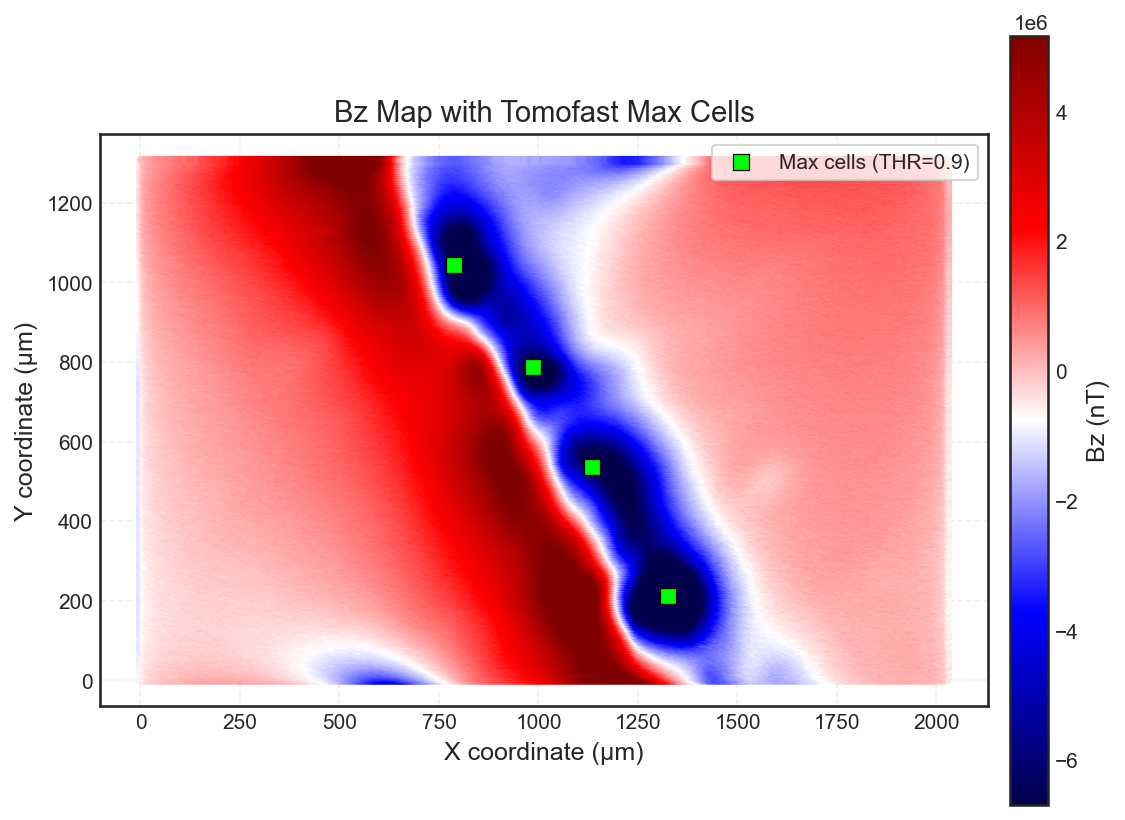

Saved figure: 4-3D_Inversion_Filtered\Tomofast_Output_Blobs\BZ_max_cells_THR_0.9.png


In [22]:
#max cells plot

#User attention: we assume here the best amplitude threshold is 0.9 (change THR = 0.9 if wanted)
# ============================================================
#  SETTINGS
# ============================================================

# define best threshold
THR = 0.9 

# ------------------------------------------------------------
# 1. Read Mag data (Bz)
# ------------------------------------------------------------
mag_path = os.path.join(base_dir, "4-3D_Inversion_Filtered", "Mag_Inversion.obs")
mag = np.loadtxt(mag_path, skiprows=1)

x = mag[:, 0]
y = mag[:, 1]
bz = -1 * mag[:, 3]   # QDM convention

# ------------------------------------------------------------
# 2. Read MAX CELLS (combined file)
# ------------------------------------------------------------
max_cells_path = os.path.join(
    base_dir,
    "4-3D_Inversion_Filtered",
    "Tomofast_Output_Blobs",
    f"ALL_BLOBS_grain_max_meshrow_{THR:.1f}.csv"
)

df = pd.read_csv(max_cells_path)

# Compute cell centres
mx = 0.5 * (df["X1"].values + df["X2"].values)
my = 0.5 * (df["Y1"].values + df["Y2"].values)

# ------------------------------------------------------------
# 3. Colour scaling (clip outliers)
# ------------------------------------------------------------
bz_min = np.percentile(bz, 2)
bz_max = np.percentile(bz, 98)

# ------------------------------------------------------------
# 4. Plot
# ------------------------------------------------------------
plt.style.use("seaborn-v0_8-white")

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

# Bz map
sc = ax.scatter(
    x, y,
    c=bz,
    s=10,
    cmap="seismic",
    vmin=bz_min,
    vmax=bz_max,
    rasterized=True
)

cbar = plt.colorbar(sc, ax=ax, shrink=0.9, pad=0.02)
cbar.set_label("Bz (nT)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

# ------------------------------------------------------------
# 5. Overlay MAX CELLS
# ------------------------------------------------------------
ax.scatter(
    mx, my,
    s=55,
    c="lime",
    edgecolors="black",
    linewidths=0.6,
    marker="s",
    label=f"Max cells (THR={THR:.1f})",
    zorder=3
)

# ------------------------------------------------------------
# 6. Labels & styling
# ------------------------------------------------------------
ax.set_xlabel("X coordinate (µm)", fontsize=12)
ax.set_ylabel("Y coordinate (µm)", fontsize=12)
ax.set_title("Bz Map with Tomofast Max Cells", fontsize=14)

ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", alpha=0.3)

ax.legend(frameon=True, fontsize=10, loc="upper right")
plt.tight_layout()

# ------------------------------------------------------------
# 7. Save figure (linked to max-cells file)
# ------------------------------------------------------------
out_png = os.path.join(
     "4-3D_Inversion_Filtered","Tomofast_Output_Blobs",
    f"BZ_max_cells_THR_{THR:.1f}.png"
)

plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure:", out_png)


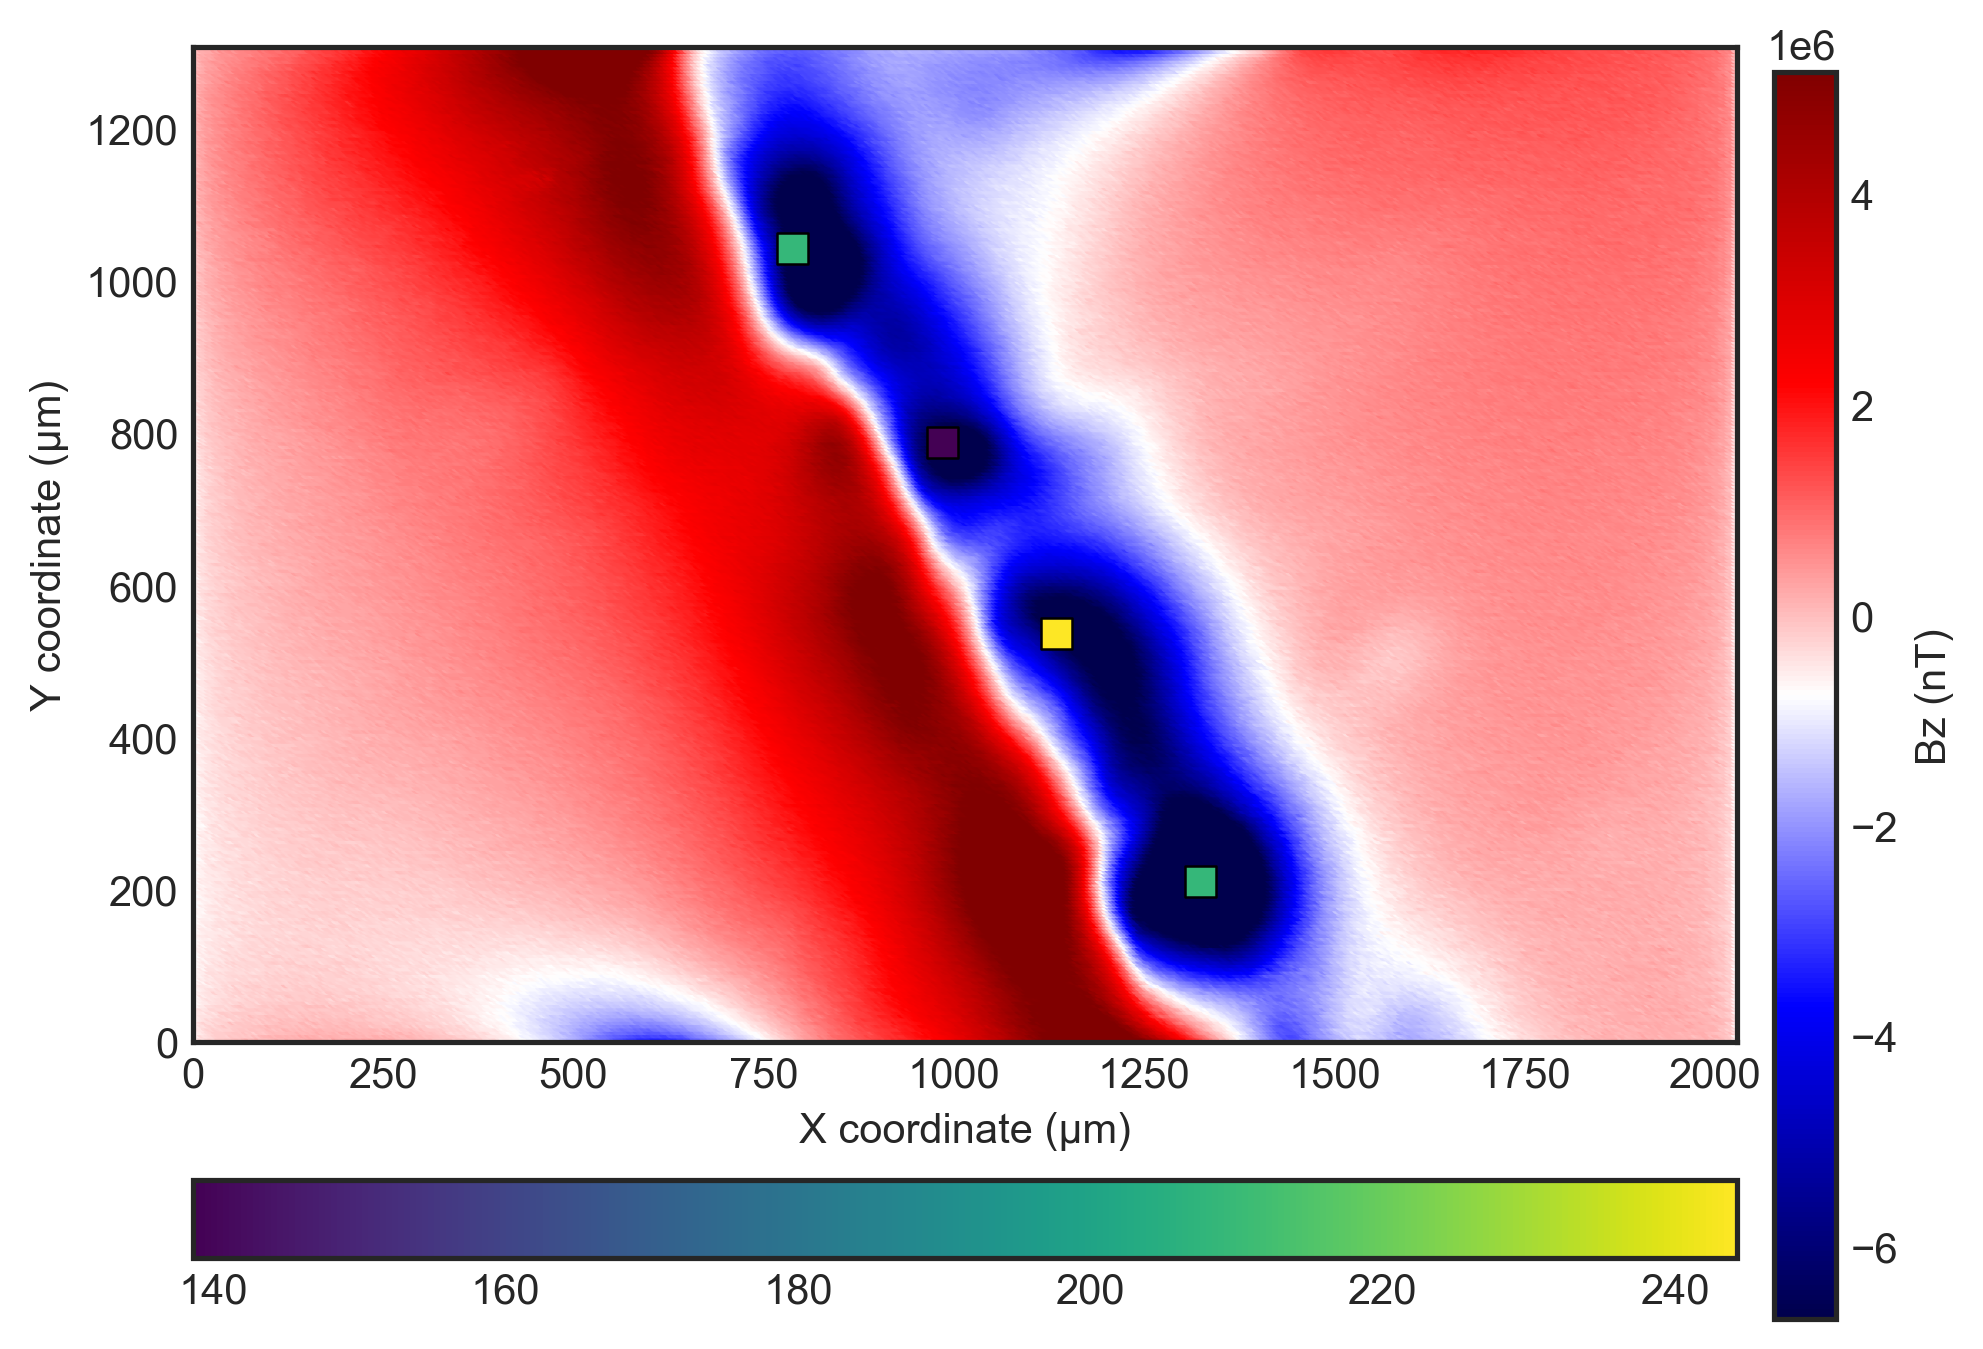

In [23]:
#max cells plot
#User attention: we assume here the best amplitude threshold is 0.9 (change THR = 0.9 if wanted)

THR = 0.9

# ------------------------------------------------------------
# 1. Read Mag data (Bz)
# ------------------------------------------------------------
mag_path = os.path.join(base_dir, "4-3D_Inversion_Filtered", "Mag_Inversion.obs")
mag = np.loadtxt(mag_path, skiprows=1)

x = mag[:, 0]
y = mag[:, 1]
bz = -1 * mag[:, 3] #flip for qdm convention

# ------------------------------------------------------------
# 2. Read MAX CELLS
# ------------------------------------------------------------
max_cells_path = os.path.join(
    base_dir,
    "4-3D_Inversion_Filtered",
    "Tomofast_Output_Blobs",
    f"ALL_BLOBS_grain_max_meshrow_{THR:.1f}.csv"
)

df = pd.read_csv(max_cells_path)

mx = 0.5 * (df["X1"].values + df["X2"].values)
my = 0.5 * (df["Y1"].values + df["Y2"].values)
mz = 0.5 * (df["Z1"].values + df["Z2"].values)   # depth

# ------------------------------------------------------------
# 3. Colour scaling 
# ------------------------------------------------------------
bz_min = np.percentile(bz, 2)
bz_max = np.percentile(bz, 98)

# ------------------------------------------------------------
# 4. Plot
# ------------------------------------------------------------
plt.style.use("seaborn-v0_8-white")
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

sc = ax.scatter(
    x, y,
    c=bz,
    s=5,
    cmap="seismic",
    vmin=bz_min,
    vmax=bz_max,
    rasterized=True
)

cbar = plt.colorbar(sc, ax=ax, shrink=0.9, pad=0.02)
cbar.set_label("Bz (nT)")

# ------------------------------------------------------------
# 5. Overlay MAX CELLS (depth coloured)
# ------------------------------------------------------------
sc_max = ax.scatter(
    mx, my,
    s=55,
    c=mz,
    cmap="viridis",
    edgecolors="black",
    linewidths=0.6,
    marker="s",
    zorder=3
)

plt.colorbar(sc_max, ax=ax, orientation="horizontal", pad=0.10)

# ------------------------------------------------------------
# 6. Labels & save (unchanged)
# ------------------------------------------------------------
ax.set_xlabel("X coordinate (µm)")
ax.set_ylabel("Y coordinate (µm)")
ax.set_aspect("equal")
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())

out_png = os.path.join(
    "4-3D_Inversion_Filtered",
    "Tomofast_Output_Blobs",
    f"BZ_max_cells_THR_{THR:.1f}.png"
)

plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()


# Tool 2: Source Location Detection
This tool runs a series of single cell Tomofast-x full magnetic vector inversion in order to obtain the true source location which matches the minimum data cost(misfit). 
* User attention: (this line takes some time for finding the true location)
* inputs are guide cell (maxi cells), single meshs, anomalies windows data
* THR : define the threshold of the maximums that matches the model (e.g, one grain per one dipole)
* RX : (define here the range around the maximum cell in x axis and step)
* RY :  (define here the range around the maximum cell in x axis and step)
* RZ: (define here the range around the maximum cell in x axis and step)
* try RX,RY,RZ rough step and then refine when you know the approximate location
* the output data costs should increase every where around the true locations  the analysis plots should show this shape <
* if you starting the code from here you need to define the guide cell (we use the maximum cells output from the 3d inversion tool above) aroud which the single cell inversions run.

### 1. Create Meshs
this line creates mesh for every  single cell 

In [24]:
# ======  Create MESHES AROUND maxi GRAIN CENTERS — PER BLOB  ======
# Input format (first line = count):
#   Line 1: number_of_grains
#   Line 2+: grain_id xmin xmax ymin ymax zmin zmax ...

import os
base_dir = os.getcwd()

# ------------------------------------------------------------
#   PATH
# ------------------------------------------------------------
BLOB_ROOT = os.path.join(base_dir, "4-3D_Inversion_Filtered","Tomofast_Output_Blobs")

# If you want a different threshold file, change this but make sure  you pick thresholds that have one grain per one blob:
THR = 0.9
in_name = f"grain_max_meshrow_{THR:.1f}.txt"


# ------------------------------------------------------------
# OUTPUT ROOT
# ------------------------------------------------------------
#outer_root = os.path.join(base_dir, "4-Source_Detection", "Single_cell_meshs")
#os.makedirs(outer_root, exist_ok=True)

outer_root = os.path.join(base_dir, "4-Source_Detection", "Single_cell_meshs")

# clear old outputs
if os.path.exists(outer_root):
    for fname in os.listdir(outer_root):
        fpath = os.path.join(outer_root, fname)
        if os.path.isfile(fpath):
            os.remove(fpath)
else:
    os.makedirs(outer_root)

# ------------------------------------------------------------
# Search window 
#start with rough range then refine
# ------------------------------------------------------------
#RX = (-30, 30, 10)     # ix range
#RY = (-30, 30, 10)     # iy range  
#RZ = (-30, 30, 10)   # iz range

RX = (-25, 5, 1)     # ix range
RY = (-10, 5, 1)     # iy range  
RZ = (-5, 5, 1)   # iz range


# ------------------------------------------------------------
# Find blobs
# ------------------------------------------------------------
blob_dirs = sorted(
    d for d in os.listdir(BLOB_ROOT)
    if d.startswith("Blob_") and os.path.isdir(os.path.join(BLOB_ROOT, d))
)

print("Found blobs:", blob_dirs)
print("Outputs will be written to:", outer_root)

# ------------------------------------------------------------
# Loop blobs
# ------------------------------------------------------------
for blob in blob_dirs:
    print("\n===================================================")
    print("Processing", blob)
    print("===================================================")

    # Input file for this blob
    input_path = os.path.join(BLOB_ROOT, blob, blob, "Maxs_meshs", in_name)
    if not os.path.exists(input_path):
        print("   Missing:", input_path)
        continue

    # Output folder for this blob (UNDER 4-Source_Detection)
    blob_out = os.path.join(outer_root, blob)
    os.makedirs(blob_out, exist_ok=True)

    # --- 1) Read grain rows ---
    grains = []  # list of (grain_id, xmin, xmax, ymin, ymax, zmin, zmax)

    with open(input_path, "r") as f:
        first = f.readline().strip()
        try:
            _ = int(first)  # header count, not needed
        except ValueError:
            f.seek(0)

        for line in f:
            line = line.strip()
            if not line:
                continue

            cols = line.split()
            if len(cols) < 7:
                continue

            grain_id = int(float(cols[0]))
            xmin = float(cols[1]); xmax = float(cols[2])
            ymin = float(cols[3]); ymax = float(cols[4])
            zmin = float(cols[5]); zmax = float(cols[6])

            grains.append((grain_id, xmin, xmax, ymin, ymax, zmin, zmax))

    print(f"  Loaded {len(grains)} grains:", [g[0] for g in grains])

    # --- 2) Process each grain ---
    for (grain_id, xmin, xmax, ymin, ymax, zmin, zmax) in grains:

        dx = xmax - xmin
        dy = ymax - ymin
        dz = zmax - zmin

        cx0 = 0.5 * (xmin + xmax)
        cy0 = 0.5 * (ymin + ymax)
        cz0 = 0.5 * (zmin + zmax)

        # Output folder: 4-Source_Detection/Single_cell_meshs/Blob_XXX/grain_ID/
        grain_folder = os.path.join(blob_out, f"grain_{grain_id}")
        os.makedirs(grain_folder, exist_ok=True)

        count = 0

        #for ix in range(RX[0], RX[1]):
            #for iy in range(RY[0], RY[1]):
                #for iz in range(RZ[0], RZ[1]):

        for ix in range(RX[0], RX[1], RX[2]):
            for iy in range(RY[0], RY[1], RY[2]):
                for iz in range(RZ[0], RZ[1], RZ[2]):
                    
                    cx = cx0 + ix * dx
                    cy = cy0 + iy * dy
                    cz = cz0 + iz * dz

                    xmin_new = cx - dx / 2
                    xmax_new = cx + dx / 2
                    ymin_new = cy - dy / 2
                    ymax_new = cy + dy / 2
                    zmin_new = cz - dz / 2
                    zmax_new = cz + dz / 2

                    count += 1
                    out_name = f"meshgrid_{count:03d}.txt"
                    out_path = os.path.join(grain_folder, out_name)

                    with open(out_path, "w") as fout:
                        fout.write("1\n")
                        fout.write(
                            f"{xmin_new:.6f} {xmax_new:.6f} "
                            f"{ymin_new:.6f} {ymax_new:.6f} "
                            f"{zmin_new:.6f} {zmax_new:.6f} "
                            f"0.000000 0.000000 0.000000 1 1 1\n"
                        )

        print(f"  {blob} Grain {grain_id}: created {count} mesh files → {grain_folder}")

print("\nAll grains completed.")


Found blobs: ['Blob_003', 'Blob_005', 'Blob_006', 'Blob_007']
Outputs will be written to: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-Source_Detection\Single_cell_meshs

Processing Blob_003
  Loaded 1 grains: [1]
  Blob_003 Grain 1: created 4500 mesh files → D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-Source_Detection\Single_cell_meshs\Blob_003\grain_1

Processing Blob_005
  Loaded 1 grains: [1]
  Blob_005 Grain 1: created 4500 mesh files → D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-Source_Detection\Single_cell_meshs\Blob_005\grain_1

Processing Blob_006
  Loaded 1 grains: [1]
  Blob_006 Grain 1: created 4500 mesh files → D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-Source_Detection\Single_cell_meshs\Blob_006\grain_1

Processing Blob_007
  Loaded 1 grains: [1]
  Blob_007 Grain 1: created 4500 mesh files → D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-Source_Detection\Single_cell_meshs

### 2. Create Parfile
this line creates parfiles for the single cell inversions

In [25]:

# ------------------------------------------------
# INPUT: window summary file
# ------------------------------------------------
# Format:
# blob_id nx ny nz ndata
summary_path = os.path.join(
    base_dir,
    "4-3D_Inversion_Filtered",
    "blob_window_summary.txt"
)

# ------------------------------------------------
# OUTPUT: parfiles
# ------------------------------------------------
par_out_dir = os.path.join(base_dir, "0-Parfiles")
os.makedirs(par_out_dir, exist_ok=True)

# ------------------------------------------------
# Parfile template 
# ------------------------------------------------
PAR_TEMPLATE = """==================================================================================
GLOBAL
==================================================================================
global.outputFolderPath         = ./output/QDM/Blob_{blob_id:03d}
global.description              = QDM inversion – Blob {blob_id}

==================================================================================
MODEL GRID parameters
==================================================================================
# nx ny nz
modelGrid.size                        = 1 1 1
modelGrid.magn.file                   = data/QDM/meshgrid.txt
modelGrid.magn.nModelComponents       = 3

==================================================================================
DATA parameters
==================================================================================
forward.data.magn.nData                = {ndata}
forward.data.magn.dataGridFile         = data/QDM/Blob_{blob_id:03d}_RECT.obs
forward.data.magn.dataValuesFile       = data/QDM/Blob_{blob_id:03d}_RECT.obs
forward.data.magn.nDataComponents      = 1

==================================================================================
MAGNETIC FIELD constants
==================================================================================
forward.magneticField.inclination              = 90.0
forward.magneticField.declination              = 0.0
forward.magneticField.XaxisDeclination         = 0.d0

==================================================================================
DEPTH WEIGHTING
==================================================================================
# 1-depth weight, 2-distance weight.
forward.depthWeighting.type                    = 1

==================================================================================
SENSITIVITY KERNEL
==================================================================================
sensit.readFromFiles                  = 0
sensit.folderPath                     = ./output/QDM/SENSIT/

==================================================================================
MATRIX COMPRESSION
==================================================================================
forward.matrixCompression.type                        = 0
forward.matrixCompression.rate                        = 0.1

==================================================================================
PRIOR MODEL
==================================================================================
inversion.priorModel.type                  = 1
inversion.priorModel.magn.value            = 0.000000

==================================================================================
INVERSION parameters
==================================================================================
inversion.nMajorIterations              = 3
inversion.nMinorIterations              = 100

==================================================================================
MODEL DAMPING (m - m_prior)
==================================================================================
inversion.modelDamping.magn.weight      = 0.0

==================================================================================
JOINT INVERSION parameters
==================================================================================
inversion.joint.grav.problemWeight      = 0.00000000
inversion.joint.magn.problemWeight      = 1.00000000
"""

# ------------------------------------------------
# LOAD SUMMARY + WRITE PARFILES
# ------------------------------------------------
summary = np.loadtxt(summary_path, comments="#", ndmin=2)

print("Creating Parfiles...")

for row in summary:
    blob_id = int(row[0])
    nx      = int(row[1])
    ny      = int(row[2])
    nz      = int(row[3])
    ndata   = int(row[4])

    par_text = PAR_TEMPLATE.format(
        blob_id=blob_id,
        nx=nx,
        ny=ny,
        nz=nz,
        ndata=ndata
    )

    out_path = os.path.join(
        par_out_dir,
        f"Parfile_QDM_Inversion_Blob_{blob_id:03d}.txt"
    )

    with open(out_path, "w") as f:
        f.write(par_text)

    print(f"  Blob {blob_id:03d}: nx={nx}, ny={ny}, nz={nz}, nData={ndata}")
    print("    ->", out_path)

print("\nDone. Parfiles written to:", par_out_dir)


Creating Parfiles...
  Blob 003: nx=162, ny=106, nz=120, nData=8052
    -> D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\0-Parfiles\Parfile_QDM_Inversion_Blob_003.txt
  Blob 005: nx=152, ny=100, nz=120, nData=6720
    -> D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\0-Parfiles\Parfile_QDM_Inversion_Blob_005.txt
  Blob 006: nx=140, ny=78, nz=120, nData=3800
    -> D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\0-Parfiles\Parfile_QDM_Inversion_Blob_006.txt
  Blob 007: nx=147, ny=103, nz=120, nData=6741
    -> D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\0-Parfiles\Parfile_QDM_Inversion_Blob_007.txt

Done. Parfiles written to: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\0-Parfiles


### 3. Run Tomofast for minimum Data Cost Detection
run Tomofast-x series of single cell inversions (based on the created meshs above) to pick the source locations
* for WSL use the first line, for Linux use the second line (just a simple directory change)

In [26]:
# WSL Tomofast-x run

# TomoFast loop: per BLOB -> per grain -> per meshgrid_*.txt
# Quiet run, no spam printing. Shows progress line only.


# =====  SETTINGS =====
SAVE_LOG_PER_RUN = False  # True = write each run stdout to a log file ( no printing)
# =========================

# -------- globals --------
last_data_cost = None
summary_rows = []  # (blob_name, grain_name, mesh_name, xmin, xmax, ymin, ymax, zmin, zmax, cost)

base_dir = os.getcwd()
print("Current working directory (Windows):", base_dir)

def to_wsl_path(win_path: str) -> str:
    win_path = win_path.replace("\\", "/")
    drive = win_path[0].lower()
    rest = win_path[2:]
    return f"/mnt/{drive}/{rest}"

base_dir_wsl = to_wsl_path(base_dir)

# -------- paths (Windows) --------
mesh_root = os.path.join(base_dir, "4-Source_Detection", "Single_cell_meshs")
obs_dir   = os.path.join(base_dir, "4-3D_Inversion_Filtered", "Blob_Clipped_obs_RECT")
par_dir   = os.path.join(base_dir, "0-Parfiles")

print("Mesh root (Windows):", mesh_root)
print("Obs dir   (Windows):", obs_dir)
print("Par dir   (Windows):", par_dir)

def run_quiet(cmd: str):
    """
    Run WSL bash command. Capture stdout (no printing).
    Parse and store last 'data cost (new)' from stdout.
    """
    global last_data_cost
    last_data_cost = None

    p = subprocess.Popen(
        [WSL, "bash", "-lc", cmd],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True
    )

    stdout_lines = []
    for line in p.stdout:
        stdout_lines.append(line)
        if "data cost (new)" in line:
            try:
                last_data_cost = float(line.split("=")[-1].strip())
            except Exception:
                pass

    p.wait()
    return p.returncode, "".join(stdout_lines)

def read_mesh_bounds(mesh_path):
    with open(mesh_path, "r") as f:
        lines = f.readlines()
    if len(lines) < 2:
        return None
    s = lines[1].split()
    return float(s[0]), float(s[1]), float(s[2]), float(s[3]), float(s[4]), float(s[5])

def print_progress(done, total, blob, grain, mesh, cost):
    """
    Single-line progress update (no spam).
    """
    if cost is None or math.isnan(cost):
        cost_str = "NaN"
    else:
        cost_str = f"{cost:.6e}"

    msg = f"\rProgress: {done}/{total} | {blob} {grain} {mesh} | cost={cost_str}   "
    sys.stdout.write(msg)
    sys.stdout.flush()

# -------- find Blob_* folders --------
blob_folders = sorted(
    d for d in glob.glob(os.path.join(mesh_root, "Blob_*"))
    if os.path.isdir(d)
)

if not blob_folders:
    raise FileNotFoundError("No Blob_* folders found in: " + mesh_root)

print("\nFound blob folders:")
for bf in blob_folders:
    print("  ", os.path.basename(bf))

# ============================================================
# PRECOUNT TOTAL MESHES (for progress)
# ============================================================
total_meshes = 0
for blob_folder in blob_folders:
    grain_folders = sorted(
        d for d in glob.glob(os.path.join(blob_folder, "grain_*"))
        if os.path.isdir(d)
    )
    for grain_folder in grain_folders:
        total_meshes += len(glob.glob(os.path.join(grain_folder, "meshgrid_*.txt")))

print(f"\nTotal meshes to run: {total_meshes}\n")

done_meshes = 0

# ============================================================
# LOOP OVER BLOBS
# ============================================================
for blob_folder in blob_folders:
    blob_name = os.path.basename(blob_folder)  # Blob_001
    blob_id = int(blob_name.split("_")[1])

    # per-blob obs + parfile (Windows)
    obs_win = os.path.join(obs_dir, f"Blob_{blob_id:03d}_RECT.obs")
    par_win = os.path.join(par_dir, f"Parfile_QDM_Inversion_Blob_{blob_id:03d}.txt")

    if not os.path.exists(obs_win):
        print("\n   Missing obs:", obs_win)
        continue
    if not os.path.exists(par_win):
        print("\n   Missing parfile:", par_win)
        continue

    # copy per-blob parfile
    rc, _ = run_quiet(f"cp '{to_wsl_path(par_win)}' {TOMOFAST_HOME_WSL}/parfiles/")
    if rc != 0:
        print("\n   Failed copying parfile for", blob_name)
        continue

    # copy blob obs as Mag_Inversion.obs ( parfile doesn't need edits)
    rc, _ = run_quiet(f"cp '{to_wsl_path(obs_win)}' {TOMOFAST_HOME_WSL}/data/QDM/Mag_Inversion.obs")
    if rc != 0:
        print("\n   Failed copying obs for", blob_name)
        continue

    par_name = f"Parfile_QDM_Inversion_Blob_{blob_id:03d}.txt"

    # -------- find grain_* folders inside this blob --------
    grain_folders = sorted(
        d for d in glob.glob(os.path.join(blob_folder, "grain_*"))
        if os.path.isdir(d)
    )

    if not grain_folders:
        print("\n  No grain_* folders in:", blob_folder)
        continue

    # ========================================================
    # LOOP GRAINS -> MESHES
    # ========================================================
    for grain_folder in grain_folders:
        grain_name = os.path.basename(grain_folder)
        grain_folder_wsl = to_wsl_path(grain_folder)

        mesh_files = sorted(glob.glob(os.path.join(grain_folder, "meshgrid_*.txt")))
        if not mesh_files:
            continue

        for mesh_path in mesh_files:
            mesh_name = os.path.basename(mesh_path)

            bounds = read_mesh_bounds(mesh_path)
            if bounds is None:
                done_meshes += 1
                print_progress(done_meshes, total_meshes, blob_name, grain_name, mesh_name, float("nan"))
                summary_rows.append((blob_name, grain_name, mesh_name, float("nan"), float("nan"),
                                     float("nan"), float("nan"), float("nan"), float("nan"), float("nan")))
                continue

            xmin, xmax, ymin, ymax, zmin, zmax = bounds

            # copy mesh as meshgrid.txt
            rc, _ = run_quiet(
                f"cp '{grain_folder_wsl}/{mesh_name}' "
                f"{TOMOFAST_HOME_WSL}/data/QDM/meshgrid.txt"
            )
            if rc != 0:
                done_meshes += 1
                final_cost = float("nan")
                print_progress(done_meshes, total_meshes, blob_name, grain_name, mesh_name, final_cost)
                summary_rows.append((blob_name, grain_name, mesh_name, xmin, xmax, ymin, ymax, zmin, zmax, final_cost))
                continue

            # run TomoFast quietly (NO tee, NO live printing)
            cmd = (
                f"cd {TOMOFAST_HOME_WSL} && "
                f"./tomofastx -p ./parfiles/{par_name}"
            )
            rc, out_text = run_quiet(cmd)

            if SAVE_LOG_PER_RUN:
                # Optional: store stdout for debugging without printing
                log_dir_win = os.path.join(base_dir, "4-Source_Detection", "Results_DataCost", "logs")
                os.makedirs(log_dir_win, exist_ok=True)
                log_path_win = os.path.join(log_dir_win, f"{blob_name}_{grain_name}_{mesh_name}.log")
                with open(log_path_win, "w", encoding="utf-8") as lf:
                    lf.write(out_text)

            if rc != 0:
                final_cost = float("nan")
            else:
                final_cost = last_data_cost if last_data_cost is not None else float("nan")

            done_meshes += 1
            print_progress(done_meshes, total_meshes, blob_name, grain_name, mesh_name, final_cost)

            summary_rows.append(
                (blob_name, grain_name, mesh_name, xmin, xmax, ymin, ymax, zmin, zmax, final_cost)
            )

# finish the progress line nicely
print("\n\nDone running all meshes.")

# ============================================================
# WRITE SUMMARY + BESTS
# ============================================================
summary_dir = os.path.join(base_dir, "4-Source_Detection", "Results_DataCost")
os.makedirs(summary_dir, exist_ok=True)

summary_path = os.path.join(summary_dir, "all_final_data_costs_ALL_BLOBS.txt")
with open(summary_path, "w") as f:
    f.write("# blob grain meshfile xmin xmax ymin ymax zmin zmax final_data_cost\n")
    for r in summary_rows:
        f.write(
            f"{r[0]} {r[1]} {r[2]} "
            f"{r[3]:.6f} {r[4]:.6f} {r[5]:.6f} {r[6]:.6f} "
            f"{r[7]:.6f} {r[8]:.6f} {r[9]:.16e}\n"
        )

print("\n Global summary written to:", summary_path)

# ---- best per blob ----
print("\n=== Best per blob ===")
blob_names = sorted(set(r[0] for r in summary_rows))
for b in blob_names:
    rows_b = [r for r in summary_rows if r[0] == b and not math.isnan(r[9])]
    if not rows_b:
        print(f"  {b}: no valid costs")
        continue
    best_b = min(rows_b, key=lambda x: x[9])
    print(f"  {b}: best={best_b[1]}/{best_b[2]} cost={best_b[9]:.6e}")

# ---- best per (blob, grain) ----
print("\n=== Best per blob/grain ===")
pairs = sorted(set((r[0], r[1]) for r in summary_rows))
for (b, g) in pairs:
    rows_bg = [r for r in summary_rows if r[0] == b and r[1] == g and not math.isnan(r[9])]
    if not rows_bg:
        continue
    best_bg = min(rows_bg, key=lambda x: x[9])
    print(f"  {b} {g}: best={best_bg[2]} cost={best_bg[9]:.6e}")

# ---- global best ----
valid = [r for r in summary_rows if not math.isnan(r[9])]
if valid:
    best = min(valid, key=lambda x: x[9])
    print("\n=== Global best over all blobs ===")
    print(f"  blob={best[0]} grain={best[1]} mesh={best[2]} cost={best[9]:.6e}")
else:
    print("\nNo valid costs at all.")


Current working directory (Windows): D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2
Mesh root (Windows): D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-Source_Detection\Single_cell_meshs
Obs dir   (Windows): D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-3D_Inversion_Filtered\Blob_Clipped_obs_RECT
Par dir   (Windows): D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\0-Parfiles

Found blob folders:
   Blob_003
   Blob_005
   Blob_006
   Blob_007

Total meshes to run: 18000

Progress: 2997/18000 | Blob_003 grain_1 meshgrid_3633.txt | cost=4.800376e-01   

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



### 4. Analysis Plots
* the output data costs should increase every where around the true locations  the analysis plots should show this shape < < < in x y z 

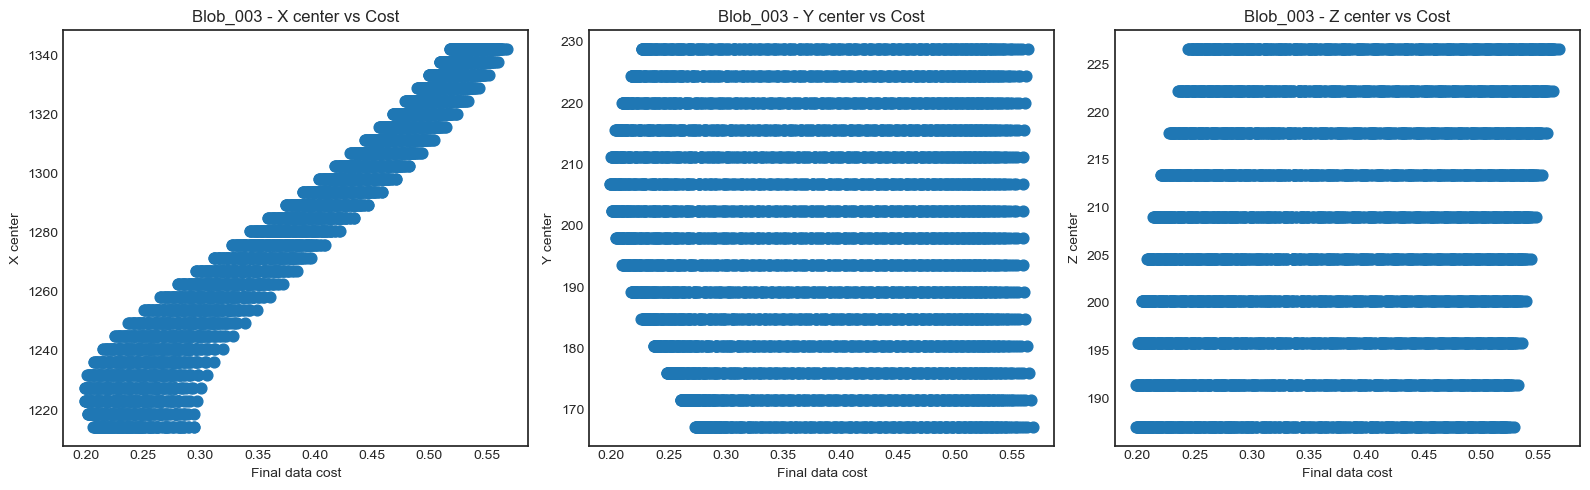


-------------------------------------
Blob: Blob_003
Minimum final data cost = 0.199015378393365
Best meshfile           = meshgrid_541.txt
Bounds xmin xmax ymin ymax zmin zmax:
xmin    1225.4
xmax    1229.8
ymin     204.6
ymax     209.0
zmin     184.8
zmax     189.2
Name: 4041, dtype: object
-------------------------------------



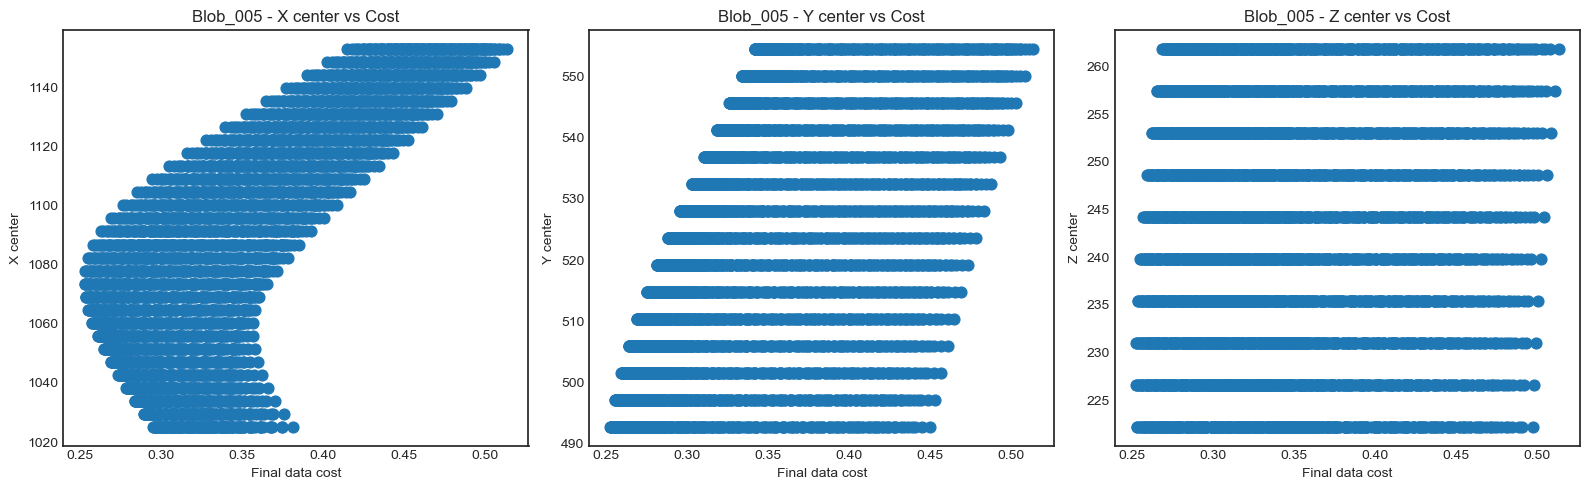


-------------------------------------
Blob: Blob_005
Minimum final data cost = 0.2526637447961648
Best meshfile           = meshgrid_1652.txt
Bounds xmin xmax ymin ymax zmin zmax:
xmin    1071.4
xmax    1075.8
ymin     490.6
ymax     495.0
zmin     224.4
zmax     228.8
Name: 5317, dtype: object
-------------------------------------



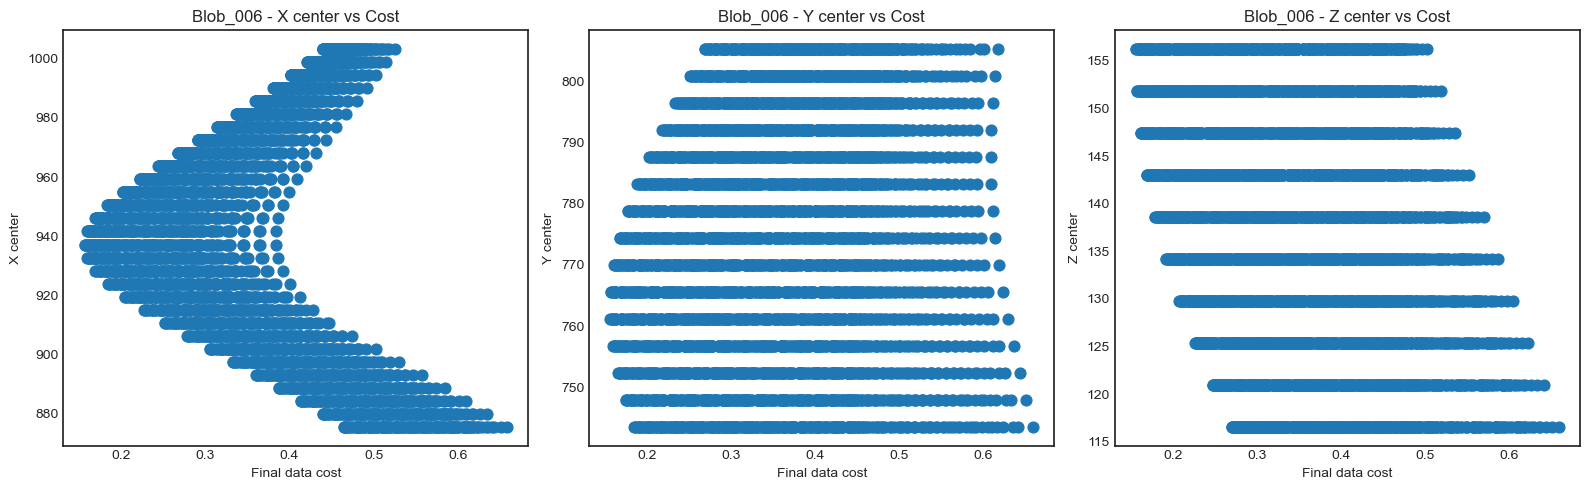


-------------------------------------
Blob: Blob_006
Minimum final data cost = 0.15642828071759413
Best meshfile           = meshgrid_2150.txt
Bounds xmin xmax ymin ymax zmin zmax:
xmin    935.0
xmax    939.4
ymin    759.0
ymax    763.4
zmin    154.0
zmax    158.4
Name: 10365, dtype: object
-------------------------------------



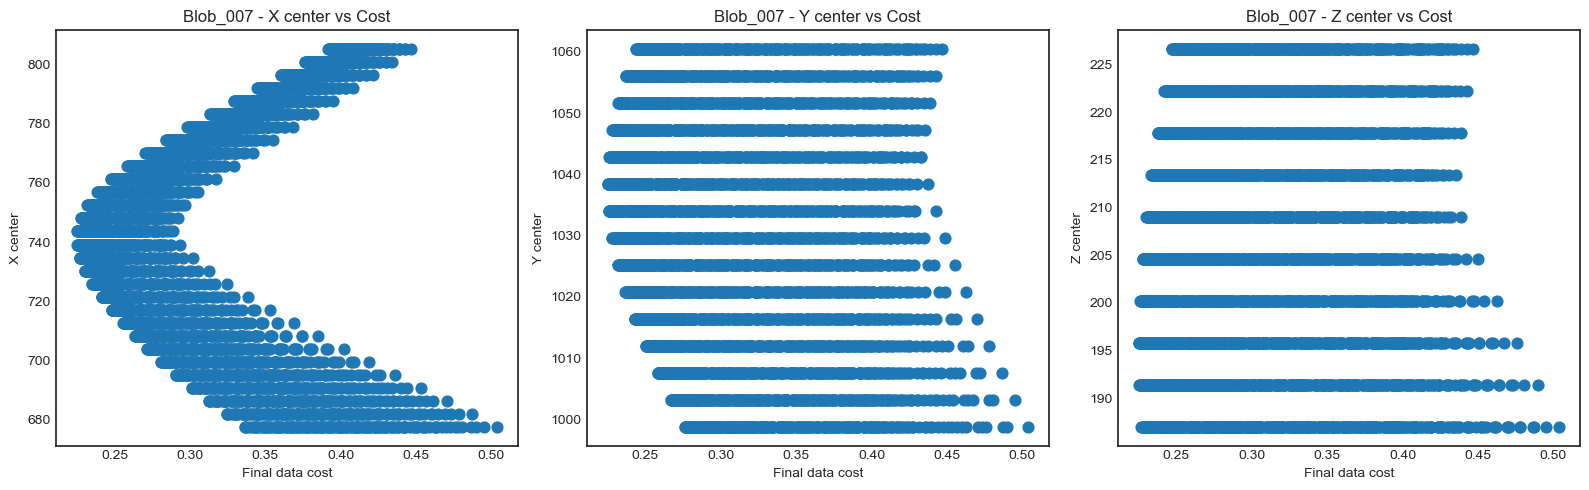


-------------------------------------
Blob: Blob_007
Minimum final data cost = 0.22490604156116817
Best meshfile           = meshgrid_2193.txt
Bounds xmin xmax ymin ymax zmin zmax:
xmin     737.0
xmax     741.4
ymin    1036.2
ymax    1040.6
zmin     193.6
zmax     198.0
Name: 14912, dtype: object
-------------------------------------



In [27]:
# Plot Locations (per BLOB) — each blob is one grain

#  new summary file (all blobs)
txt_path = os.path.join(base_dir, "4-Source_Detection", "Results_DataCost", "all_final_data_costs_ALL_BLOBS.txt")

# columns in that file:
# blob grain meshfile xmin xmax ymin ymax zmin zmax final_data_cost
colnames = ["blob","grain","meshfile","xmin","xmax","ymin","ymax","zmin","zmax","final_data_cost"]
df = pd.read_csv(txt_path, sep=r"\s+", names=colnames, skiprows=1)

# make sure output folder exists
out_dir = os.path.join(base_dir, "4-Source_Detection", "Results_DataCost")
os.makedirs(out_dir, exist_ok=True)

# ---------------------------------------------------------
# Loop over BLOBS (each blob is one grain  case)
# ---------------------------------------------------------
for blob_name, bdf in df.groupby("blob"):

    bdf = bdf.copy()

    # drop NaNs (failed runs)
    bdf = bdf[np.isfinite(bdf["final_data_cost"])]
    if bdf.empty:
        print(f"{blob_name}: no valid costs (all NaN)")
        continue

    # centers
    bdf["x_center"] = 0.5 * (bdf["xmin"] + bdf["xmax"])
    bdf["y_center"] = 0.5 * (bdf["ymin"] + bdf["ymax"])
    bdf["z_center"] = 0.5 * (bdf["zmin"] + bdf["zmax"])

    data_cost = bdf["final_data_cost"].values

    # plots
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    axes[0].scatter(data_cost, bdf["x_center"], s=60)
    axes[0].set_xlabel("Final data cost")
    axes[0].set_ylabel("X center")
    axes[0].set_title(f"{blob_name} - X center vs Cost")

    axes[1].scatter(data_cost, bdf["y_center"], s=60)
    axes[1].set_xlabel("Final data cost")
    axes[1].set_ylabel("Y center")
    axes[1].set_title(f"{blob_name} - Y center vs Cost")

    axes[2].scatter(data_cost, bdf["z_center"], s=60)
    axes[2].set_xlabel("Final data cost")
    axes[2].set_ylabel("Z center")
    axes[2].set_title(f"{blob_name} - Z center vs Cost")

    plt.tight_layout()

    out_png = os.path.join(out_dir, f"Mini_Cost_{blob_name}.png")
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()

    # best for this blob
    min_row = bdf.loc[bdf["final_data_cost"].idxmin()]
    print("\n-------------------------------------")
    print(f"Blob: {blob_name}")
    print("Minimum final data cost =", min_row["final_data_cost"])
    print("Best meshfile           =", min_row["meshfile"])
    print("Bounds xmin xmax ymin ymax zmin zmax:")
    print(min_row[["xmin","xmax","ymin","ymax","zmin","zmax"]])
    print("-------------------------------------\n")


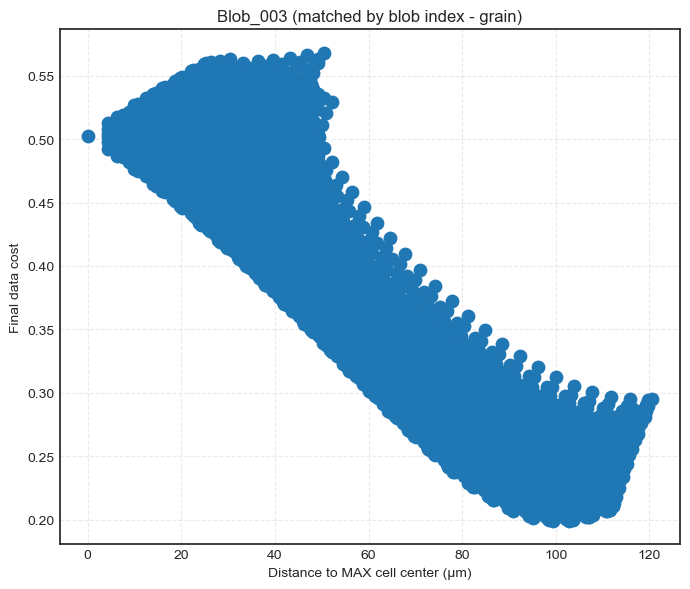


-------------------------------------
Blob: Blob_003
Min final data cost     = 0.199015378393365
Best meshfile           = meshgrid_541.txt
Grain (from file)       = 1
Expected grain (blob#)  = 3
Distance to MAX cell    = 99.36599015759887
-------------------------------------



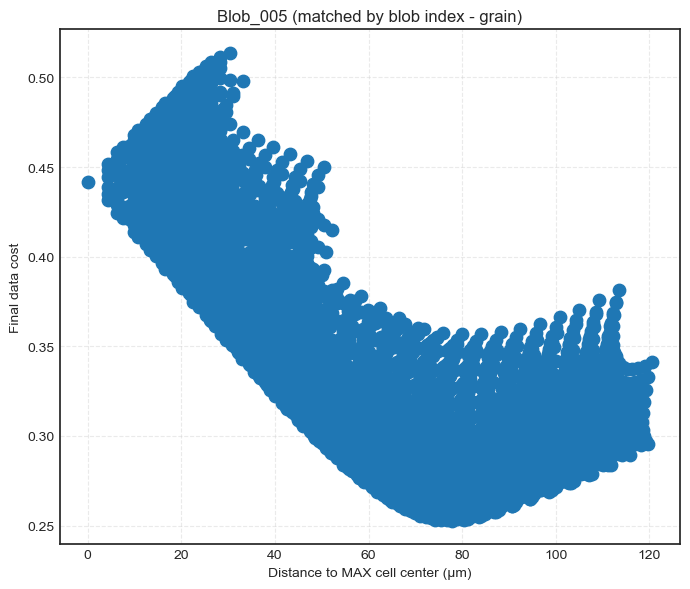


-------------------------------------
Blob: Blob_005
Min final data cost     = 0.2526637447961648
Best meshfile           = meshgrid_1652.txt
Grain (from file)       = 1
Expected grain (blob#)  = 5
Distance to MAX cell    = 77.71949562368512
-------------------------------------



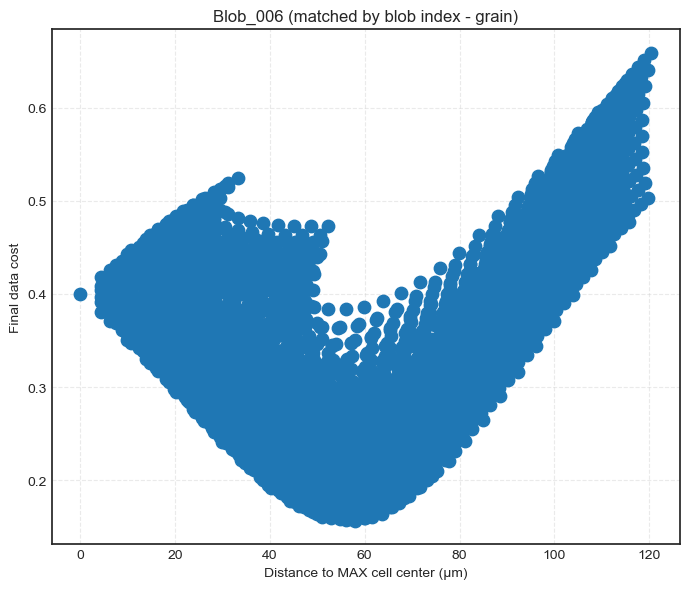


-------------------------------------
Blob: Blob_006
Min final data cost     = 0.15642828071759413
Best meshfile           = meshgrid_2150.txt
Grain (from file)       = 1
Expected grain (blob#)  = 6
Distance to MAX cell    = 57.8729643270498
-------------------------------------



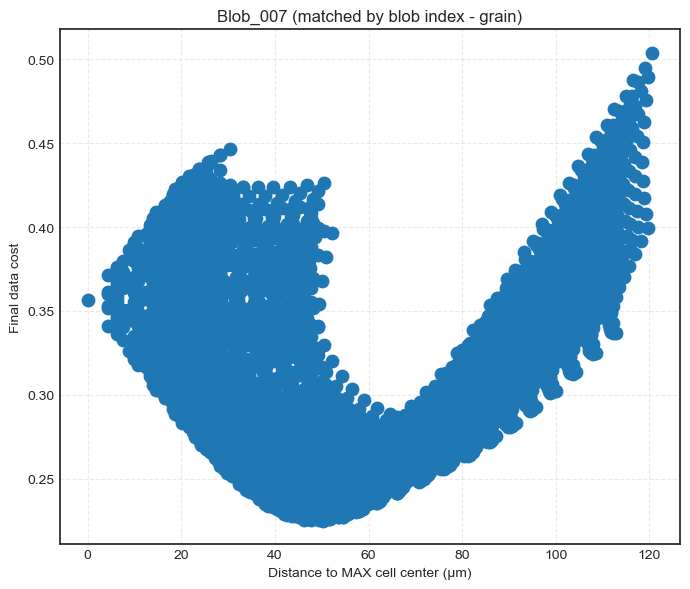


-------------------------------------
Blob: Blob_007
Min final data cost     = 0.22490604156116817
Best meshfile           = meshgrid_2193.txt
Grain (from file)       = 1
Expected grain (blob#)  = 7
Distance to MAX cell    = 50.36030182594208
-------------------------------------



In [28]:
#distance from maxs 

# =========================================================
# INPUTS
# =========================================================
# Data-cost file (ALL BLOBS)
cost_txt_path = os.path.join(
    base_dir,
    "4-Source_Detection", "Results_DataCost",
    "all_final_data_costs_ALL_BLOBS.txt"
)

# Max-cells combined CSV (from  summary script)
BLOB_ROOT = os.path.join(base_dir, "4-3D_Inversion_Filtered", "Tomofast_Output_Blobs")
THR = 0.9
max_csv_path = os.path.join(BLOB_ROOT, f"ALL_BLOBS_grain_max_meshrow_{THR:.1f}.csv")

# Output plots folder
out_dir = os.path.join(base_dir, "4-Source_Detection", "Results_DataCost")
os.makedirs(out_dir, exist_ok=True)

# =========================================================
# HELPERS
# =========================================================
def blob_index(blob_name: str) -> int:
    """
    Extract numeric index from 'Blob_001' -> 1
    """
    m = re.search(r"(\d+)", str(blob_name))
    if not m:
        return np.nan
    return int(m.group(1))

# =========================================================
# 1) READ DATA COST FILE
# =========================================================
# file columns:
# blob grain meshfile xmin xmax ymin ymax zmin zmax final_data_cost
colnames = ["blob","grain","meshfile","xmin","xmax","ymin","ymax","zmin","zmax","final_data_cost"]
df = pd.read_csv(cost_txt_path, sep=r"\s+", names=colnames, skiprows=1)

# Keep only finite costs
df = df[np.isfinite(df["final_data_cost"])].copy()

# Grain may be like "grain_2" -> extract the number
df["grain"] = df["grain"].astype(str).str.extract(r"(\d+)", expand=False)
df["grain"] = pd.to_numeric(df["grain"], errors="coerce")
df = df.dropna(subset=["grain"]).copy()
df["grain"] = df["grain"].astype(int)

# Compute centers for each tested cell/window
df["x_center"] = 0.5 * (df["xmin"] + df["xmax"])
df["y_center"] = 0.5 * (df["ymin"] + df["ymax"])
df["z_center"] = 0.5 * (df["zmin"] + df["zmax"])

# =========================================================
# 2) READ MAX CELLS CSV (IGNORE GrainID, use blob index rule)
# =========================================================
if not os.path.exists(max_csv_path):
    raise FileNotFoundError(f"Max-cells CSV not found:\n{max_csv_path}")

maxdf = pd.read_csv(max_csv_path)

# Normalize column name
if "Blob" in maxdf.columns:
    maxdf = maxdf.rename(columns={"Blob": "blob"})

# Compute max-cell centers from X1..Z2
maxdf["x_max_center"] = 0.5 * (maxdf["X1"] + maxdf["X2"])
maxdf["y_max_center"] = 0.5 * (maxdf["Y1"] + maxdf["Y2"])
maxdf["z_max_center"] = 0.5 * (maxdf["Z1"] + maxdf["Z2"])

# Create "expected grain" using YOUR rule: Blob_001 -> grain 1, Blob_002 -> grain 2, ...
maxdf["expected_grain"] = maxdf["blob"].apply(blob_index)
maxdf = maxdf.dropna(subset=["expected_grain"]).copy()
maxdf["expected_grain"] = maxdf["expected_grain"].astype(int)

# If multiple rows per blob, keep first (usually one row per blob)
maxdf = maxdf.drop_duplicates(subset=["blob"], keep="first")

# =========================================================
# 3) MERGE: match cost rows by (blob, expected_grain)
# =========================================================
# Add expected grain to cost df using the same rule
df["expected_grain"] = df["blob"].apply(blob_index)
df = df.dropna(subset=["expected_grain"]).copy()
df["expected_grain"] = df["expected_grain"].astype(int)

# OPTIONAL sanity check:
# If you want to ENFORCE blob index = grain number, uncomment:
# df = df[df["grain"] == df["expected_grain"]].copy()

dfm = df.merge(
    maxdf[["blob", "expected_grain", "x_max_center", "y_max_center", "z_max_center"]],
    on=["blob", "expected_grain"],
    how="left"
)

missing = dfm[dfm["x_max_center"].isna()][["blob","grain","expected_grain"]].drop_duplicates()
if len(missing) > 0:
    print("\nWARNING: Missing max-cell match for these rows (blob, grain, expected_grain):")
    print(missing.to_string(index=False))
    print("Those will be skipped in plotting.\n")

# Distance to max-cell center
dfm["distance_to_maxcell"] = np.sqrt(
    (dfm["x_center"] - dfm["x_max_center"])**2 +
    (dfm["y_center"] - dfm["y_max_center"])**2 +
    (dfm["z_center"] - dfm["z_max_center"])**2
)

# =========================================================
# 4) PLOT PER BLOB (and show best-fit)
# =========================================================
for blob_name, bdf in dfm.groupby("blob"):

    bdf = bdf.copy()
    bdf = bdf[np.isfinite(bdf["distance_to_maxcell"])].copy()
    if len(bdf) == 0:
        print(f"Skip {blob_name}: no max-cell center found (after matching).")
        continue

    # Scatter: distance vs data cost
    plt.figure(figsize=(7, 6))
    plt.scatter(bdf["distance_to_maxcell"], bdf["final_data_cost"], s=80)

    plt.xlabel("Distance to MAX cell center (µm)")
    plt.ylabel("Final data cost")
    plt.title(f"{blob_name} (matched by blob index - grain)")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()

    out_png = os.path.join(out_dir, f"Cost_vs_DistToMaxCell_{blob_name}.png")
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()

    # Best-fit (minimum cost) within this blob
    best_row = bdf.loc[bdf["final_data_cost"].idxmin()]

    print("\n-------------------------------------")
    print("Blob:", blob_name)
    print("Min final data cost     =", best_row["final_data_cost"])
    print("Best meshfile           =", best_row["meshfile"])
    print("Grain (from file)       =", best_row["grain"])
    print("Expected grain (blob#)  =", best_row["expected_grain"])
    print("Distance to MAX cell    =", best_row["distance_to_maxcell"])
    print("-------------------------------------\n")


# Tool 3: Source Vector Direction and Intensity Detection
this tool fits the full data with the detected true sources locations in a single inversion run

### 1. Combine best locations 
(into one mesh file)

In [29]:
## combine best meshs: BEST location per anomaly  (i from X, j=1, k=1)
## reads: 4-Source_Detection/Results_DataCost/all_final_data_costs_ALL_BLOBS.txt
## writes: 4-Source_Detection/combined_best_blobs_mesh.txt


# -----------------------------
# 1) Paths
# -----------------------------

summary_path = os.path.join(
    base_dir, "4-Source_Detection", "Results_DataCost", "all_final_data_costs_ALL_BLOBS.txt"
)
out_path = os.path.join(
    base_dir, "4-Source_Detection", "combined_best_blobs_mesh.txt"
)

# -----------------------------
# 2) Read summary table (blob, grain, meshfile, bounds, cost)
# -----------------------------
colnames = ["blob", "grain", "meshfile", "xmin", "xmax", "ymin", "ymax",
            "zmin", "zmax", "final_data_cost"]

df = pd.read_csv(summary_path, sep=r"\s+", names=colnames, skiprows=1)

# -----------------------------
# 3) Best mesh per BLOB
# -----------------------------
best = df.loc[df.groupby("blob")["final_data_cost"].idxmin()].reset_index(drop=True)

n_blobs = len(best)
print("Number of blobs detected:", n_blobs)

# -----------------------------
# 4) Assign simple indices
# i = 1 ... n_blobs
# -----------------------------
best = best.reset_index(drop=True)
best["i"] = best.index + 1
best["j"] = 1
best["k"] = 1

best_sorted = best.copy()

# -----------------------------
# 5) Write combined mesh file
# -----------------------------
with open(out_path, "w") as f:
    f.write(f"{n_blobs}\n")

    print("\nWriting mesh entries (best per blob):")
    for _, row in best_sorted.iterrows():
        xmin, xmax = row["xmin"], row["xmax"]
        ymin, ymax = row["ymin"], row["ymax"]
        zmin, zmax = row["zmin"], row["zmax"]
        i = int(row["i"]); j = 1; k = 1

        print(f"  {row['blob']}  {row['meshfile']}  -> i={i}, j={j}, k={k}")
        f.write(f"{xmin} {xmax} {ymin} {ymax} {zmin} {zmax} 0 0 0 {i} {j} {k}\n")

# -----------------------------
# 6) Print max i, j, k
# -----------------------------
imax = int(best_sorted["i"].max()) if n_blobs else 0

print("\n====================================")
print(" Mesh Index Summary")
print("====================================")
print(f"Max i = {imax}")
print("j is fixed to 1")
print("k is fixed to 1")
print("====================================")

print("\nCombined mesh file saved to:")
print(out_path)


Number of blobs detected: 4

Writing mesh entries (best per blob):
  Blob_003  meshgrid_541.txt  -> i=1, j=1, k=1
  Blob_005  meshgrid_1652.txt  -> i=2, j=1, k=1
  Blob_006  meshgrid_2150.txt  -> i=3, j=1, k=1
  Blob_007  meshgrid_2193.txt  -> i=4, j=1, k=1

 Mesh Index Summary
Max i = 4
j is fixed to 1
k is fixed to 1

Combined mesh file saved to:
D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-Source_Detection\combined_best_blobs_mesh.txt


### 2. Create Parfile
create parfile for data fitting in a single run inversion
*  User Attention: define num of grains (true locations) nx and data size Ndata (full data) from the most first line

In [30]:
#Create Parfile
# User Attention: define num of grains nx and data size Ndata

output_path = os.path.join(base_dir, "0-Parfiles","Parfile_QDM_Dipole.txt")

par_text = """==================================================================================
GLOBAL
==================================================================================
global.outputFolderPath         = ./output/QDM
global.description              = QDM inversion data

==================================================================================
MODEL GRID parameters
==================================================================================
# nx ny nz
modelGrid.size                        = 4 1 1
modelGrid.magn.file                   = ./data/QDM/meshgrid.txt
modelGrid.magn.nModelComponents       = 3
==================================================================================
DATA parameters
==================================================================================
forward.data.magn.nData                = 137676
forward.data.magn.dataGridFile         = ./data/QDM/Mag_Inversion.obs
forward.data.magn.dataValuesFile       = ./data/QDM/Mag_Inversion.obs
forward.data.magn.nDataComponents      = 1

==================================================================================
MAGNETIC FIELD constants
==================================================================================
forward.magneticField.inclination              = 90.0
forward.magneticField.declination              = 0.0
forward.magneticField.XaxisDeclination         = 0.d0

==================================================================================
DEPTH WEIGHTING
==================================================================================
# 1-depth weight, 2-distance weight.
forward.depthWeighting.type                    = 1

==================================================================================
SENSITIVITY KERNEL
==================================================================================
# 0-calculate the sensitivity, 1-read from files at the specified folder.
sensit.readFromFiles                  = 0
sensit.folderPath                     = ./output/QDM/SENSIT/

==================================================================================
MATRIX COMPRESSION
==================================================================================
# 0-none, 1-wavelet compression.
forward.matrixCompression.type                        = 0
# The minimum compressed sensitivity absolute value.
forward.matrixCompression.rate                        = 0.1

==================================================================================
PRIOR MODEL
==================================================================================
# 1-set value, 2-read from file.
inversion.priorModel.type                  = 1
inversion.priorModel.magn.value            = 0.000000

==================================================================================
INVERSION parameters
==================================================================================
inversion.nMajorIterations              = 3
inversion.nMinorIterations              = 100
#inversion.modelDamping.normPower        = 1.4d0

==================================================================================
MODEL DAMPING (m - m_prior)
==================================================================================
inversion.modelDamping.magn.weight      = 0.d0


==================================================================================
JOINT INVERSION parameters
==================================================================================
inversion.joint.grav.problemWeight      = 0.00000000
inversion.joint.magn.problemWeight      = 1.00000000

===================================================================================
ADMM constraints
===================================================================================
inversion.admm.enableADMM           = 0
inversion.admm.nLithologies         = 1
inversion.admm.magn.bounds          = 0. 1.d10
inversion.admm.magn.weight          = 50.d0

#inversion.admm.magn.bounds          = -1.d10 0.d0
"""

with open(output_path, "w") as f:
    f.write(par_text)

print("Parfile created:", output_path)


Parfile created: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\0-Parfiles\Parfile_QDM_Dipole.txt


### 3. Run Tomofast inversion for Dipole Fitting
fit the true detected locations with the full data
* for WSL use the first line, for Linux use the second line (just a simple directory change)

In [31]:
# WSL Tomofast-x Run

### Run Tomofast Inversion Data (combined grains, one run)

# Convert Windows path (e.g. C:\Users\USER\...) to WSL path (/mnt/c/Users/USER/...)
def to_wsl_path(win_path: str) -> str:
    win_path = win_path.replace("\\", "/")   # C:/Users/USER/OneDrive - Curtin/...
    drive = win_path[0].lower()              # 'c'
    rest = win_path[2:]                      # /Users/USER/OneDrive - Curtin/...
    return f"/mnt/{drive}/{rest}"

base_dir_wsl = to_wsl_path(base_dir)
print("WSL version of current dir:", base_dir_wsl)

WSL = r"C:\Windows\System32\wsl.exe"

# Helper function to run a WSL command with live output
def run_live(cmd):
    process = subprocess.Popen(
        [WSL, "bash", "-lc", cmd],  # If running directly in Ubuntu VM, use cmd only
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1
    )
    for line in process.stdout:
        print(line, end="")
        sys.stdout.flush()
    process.wait()
    print(f"\n[Return code: {process.returncode}]\n")


print("=== COPYING FILES TO TOMOFAST-x ===\n")

# ---------------------------------------------------------
# 1) Copy parfile + Mag_Inversion.obs to TomoFast-x
# ---------------------------------------------------------
run_live(f"cp '{base_dir_wsl}/0-Parfiles/Parfile_QDM_Dipole.txt'  {TOMOFAST_HOME_WSL}/parfiles/")
run_live(f"cp '{base_dir_wsl}/4-3D_Inversion_Filtered/Mag_Inversion.obs'   {TOMOFAST_HOME_WSL}/data/QDM/")

# ---------------------------------------------------------
# 2) Copy combined mesh file as meshgrid.txt (many grains, one run)
# ---------------------------------------------------------
combined_mesh_win = os.path.join(base_dir, "4-Source_Detection", "combined_best_blobs_mesh.txt")
combined_mesh_wsl = to_wsl_path(combined_mesh_win)

print("Using combined mesh file:")
print("Windows:", combined_mesh_win)
print("WSL:    ", combined_mesh_wsl)

run_live(f"cp '{combined_mesh_wsl}' '{TOMOFAST_HOME_WSL}/data/QDM/meshgrid.txt'")

# ---------------------------------------------------------
# 3) Run TomoFast-x once
# ---------------------------------------------------------
print("\n=== RUNNING TOMOFAST-X (combined grains) ===\n")

run_live(f"cd {TOMOFAST_HOME_WSL} && ./tomofastx -p ./parfiles/Parfile_QDM_Dipole.txt | tee ./output/QDM/QDM_log.txt")

# ---------------------------------------------------------
# 4) Copy TomoFast-x output from Linux -> Windows
# ---------------------------------------------------------
output_win = os.path.join(base_dir, "4-Source_Detection", "Tomofast_Output", "combined_grains")
os.makedirs(output_win, exist_ok=True)

output_wsl = to_wsl_path(output_win)

print("Copying Tomofast-x output from Linux → Windows folder:")
print("Linux source:   /home/abekhit/Tomofast-x/output/QDM/")
print("Windows target:", output_win)

run_live(f"cp -r {TOMOFAST_HOME_WSL}/output/QDM/data '{output_wsl}/'")
run_live(f"cp -r {TOMOFAST_HOME_WSL}/output/QDM/model '{output_wsl}/'")
run_live(f"cp -r {TOMOFAST_HOME_WSL}/output/QDM/Paraview '{output_wsl}/'")
run_live(f"cp -r {TOMOFAST_HOME_WSL}/output/QDM/QDM_log.txt '{output_wsl}/'")
run_live(f"cp -r {TOMOFAST_HOME_WSL}/output/QDM/Parfile_copy.txt '{output_wsl}/'")
run_live(f"cp -r {TOMOFAST_HOME_WSL}/output/QDM/costs.txt '{output_wsl}/'")
# run_live(f"cp -r {TOMOFAST_HOME_WSL}/output/QDM/SENSIT '{output_wsl}/'")  # optional, very large

print("\nDone: combined mesh inversion finished and outputs copied.\n")



WSL version of current dir: /mnt/d//My_Work/Tomofast-x-µ/Work/Natural_applications/Origin_Fix/2
=== COPYING FILES TO TOMOFAST-x ===


[Return code: 0]


[Return code: 0]

Using combined mesh file:
Windows: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-Source_Detection\combined_best_blobs_mesh.txt
WSL:     /mnt/d//My_Work/Tomofast-x-µ/Work/Natural_applications/Origin_Fix/2/4-Source_Detection/combined_best_blobs_mesh.txt

[Return code: 0]


=== RUNNING TOMOFAST-X (combined grains) ===

 MEMORY USED (mpi init) [GB] =   9.3688964843750000E-003
 Started Tomofast-x, version >= 2.0.8.4
 global.outputFolderPath =./output/QDM
 global.description = QDM inversion data
 modelGrid.size =           4           1           1
 modelGrid.magn.file =./data/QDM/meshgrid.txt
 modelGrid.magn.nModelComponents =           3
 forward.data.magn.nData =      137676
 forward.data.magn.dataGridFile =./data/QDM/Mag_Inversion.obs
 forward.data.magn.dataValuesFile =./data/QDM/Mag_Inversion.obs
 fo

### 4. Vectors Directions Analysis
* User Attention define cell sizes (dx,dy,dz) [cell volume] for dipole moment calculation 

In [32]:
# Vector Direction Calculation (Double Check Step)
# Each cell in the model = one grain
# User Attention define cell sizes (dx,dy,dz) [cell volume] for dipole moment calculation 

# folder containing Tomofast outputs
root_folder = os.path.join(base_dir, "4-Source_Detection", "Tomofast_Output")

# combined-grains run
grain_folders = ["combined_grains"]
print("Found model folder(s):", grain_folders)

# --------------------------------------
# LOOP OVER (here only 'combined_grains')
# --------------------------------------
for grain in grain_folders:
    print("\n=====================================")
    print("Processing", grain)
    print("=====================================\n")

    Model = os.path.join(root_folder, grain, "model", "mag_final_model_full.txt")

    # -----------------------------
    # Load the model:
    # first line = number of grains
    # following lines = Mx My Mz per grain
    # -----------------------------
    with open(Model, "r") as f:
        lines = f.readlines()

    Ngrains = int(lines[0].strip())
    print("Number of grains in model:", Ngrains)

    # convert remaining lines (one per grain) into array
    data = np.loadtxt(lines[1:])  # read from second line onward
    data = np.atleast_2d(data)    # ensure 2D even if Ngrains = 1

    # -----------------------------
    # Process each grain
    # -----------------------------
    for grain_idx, (Mx, My, Mz_raw) in enumerate(data, start=1):

        print(f"\n--- Grain {grain_idx} ---")

        # Apply sign flip (same as your original code)
        Mz = -Mz_raw

        m = np.sqrt(Mx**2 + My**2 + Mz**2)

        if m == 0:
            dec, inc = np.nan, np.nan
        else:
            theta = np.degrees(np.arccos(Mz / m))
            phi   = np.degrees(np.arctan2(My, Mx))

            inc = theta - 90
            #dec= phi - 90
            dec = 90- phi

            change = True
            while change:
                change = False

                if inc > 90:
                    inc = 180 - inc 
                    dec = dec + 180
                    change = True

                if inc < -90:
                    inc = -180 - inc
                    dec = dec + 180
                    change = True

                if dec < 0:
                    dec = dec + 360
                    change = True

                if dec >= 360:
                    dec = dec - 360
                    change = True

        print("phi=", phi, "theta=", theta)
        print("dec=", dec, "inc=", inc)

        # Cell size (m)
        dx = 4.4e-6
        dy = 4.4e-6
        dz = 4.4e-6
        V = dx * dy * dz  # m^3

        # Horizontal magnitude
        H = np.hypot(Mx, My)

        # Inclination (positive down)
        inc_rad = np.arctan2(Mz, H)
        inc_deg = np.degrees(inc_rad)

        # Magnetization amplitude (A/m)
        M_amp = np.sqrt(Mx**2 + My**2 + Mz**2)

        # Magnetic moment amplitude (A·m^2)
        moment_amp = M_amp * V

        print("Magnetization amplitude:", M_amp*1e-6, "A/m")
        print("Magnetic moment amplitude:", moment_amp, "A·m²")


Found model folder(s): ['combined_grains']

Processing combined_grains

Number of grains in model: 4

--- Grain 1 ---
phi= -168.0902654965991 theta= 101.50116520547932
dec= 258.0902654965991 inc= 11.501165205479325
Magnetization amplitude: 7755.087339849812 A/m
Magnetic moment amplitude: 6.606093599577665e-07 A·m²

--- Grain 2 ---
phi= -163.78329912965867 theta= 101.98654184339144
dec= 253.78329912965867 inc= 11.986541843391436
Magnetization amplitude: 7746.577716979481 A/m
Magnetic moment amplitude: 6.598844762431802e-07 A·m²

--- Grain 3 ---
phi= -159.83966927173168 theta= 101.92363815281198
dec= 249.83966927173168 inc= 11.923638152811975
Magnetization amplitude: 2749.646936957126 A/m
Magnetic moment amplitude: 2.3422592467775586e-07 A·m²

--- Grain 4 ---
phi= -169.1138051575015 theta= 102.90694967334903
dec= 259.1138051575015 inc= 12.906949673349033
Magnetization amplitude: 7760.167301013908 A/m
Magnetic moment amplitude: 6.610420913695688e-07 A·m²


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Using combined-grains model: ['combined_grains']

Processing: combined_grains
Number of grains detected: 4
Grain 1: dec=258.09, inc=11.50
Grain 2: dec=253.78, inc=11.99
Grain 3: dec=249.84, inc=11.92
Grain 4: dec=259.11, inc=12.91


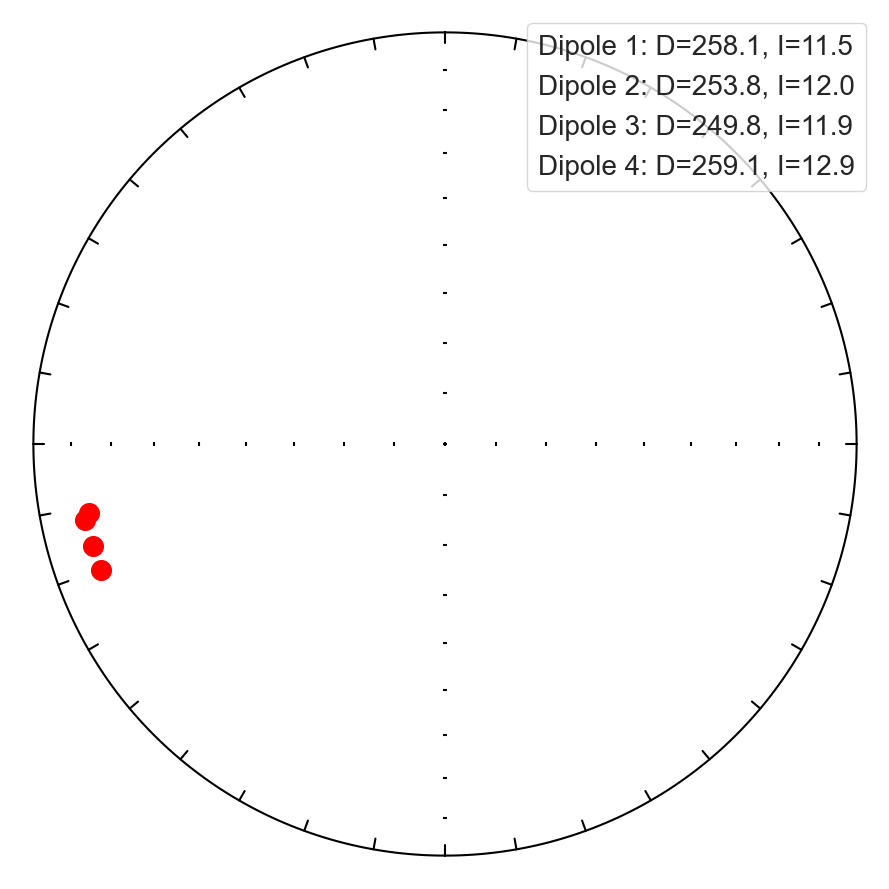

Saved combined plot: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-Source_Detection\aAll_Combined_Grains_DecInc.png


In [33]:
### Stereonet plot (combined grains)

# Root folder of Tomofast outputs
root_folder = os.path.join(base_dir, "4-Source_Detection", "Tomofast_Output")

#  use combined_grains model
grain_folders = ["combined_grains"]
print("Using combined-grains model:", grain_folders)

results = []  # store (grain_index, dec, inc)

for folder in grain_folders:

    print("\nProcessing:", folder)

    # path to final model
    Model = os.path.join(root_folder, folder, "model", "mag_final_model_full.txt")

    # ---- Load model: first line = Ngrains, rest = Mx My Mz ----
    with open(Model, "r") as f:
        lines = f.readlines()

    Ngrains = int(lines[0].strip())
    print("Number of grains detected:", Ngrains)

    data = np.loadtxt(lines[1:])
    data = np.atleast_2d(data)  # ensure 2D

    # --------------------------------------
    # Compute dec/inc for each grain cell
    # --------------------------------------
    for idx, (Mx, My, Mz_raw) in enumerate(data, start=1):

        Mz = -Mz_raw  # same sign flip
        m = np.sqrt(Mx**2 + My**2 + Mz**2)

        if m == 0:
            dec, inc = np.nan, np.nan
        else:
            theta = np.degrees(np.arccos(Mz / m))
            phi   = np.degrees(np.arctan2(My, Mx))

            inc = theta - 90
            #dec= phi - 90
            dec = 90- phi

            change = True
            while change:
                change = False

                if inc > 90:
                    inc = 180 - inc
                    dec = dec + 180
                    change = True

                if inc < -90:
                    inc = -180 - inc
                    dec = dec + 180
                    change = True

                if dec < 0:
                    dec = dec + 360
                    change = True

                if dec >= 360:
                    dec = dec - 360
                    change = True

        print(f"Grain {idx}: dec={dec:.2f}, inc={inc:.2f}")
        results.append((idx, dec, inc))


# ======================================
# Plot on Stereonet
# ======================================

plt.figure(figsize=(9, 9))
ipmag.plot_net()

ax = plt.gca()

#ax.text(
#    0.02, 0.98, "(d)",
#    transform=ax.transAxes,
#    fontsize=30,
 #   fontweight="bold",
 #   va="top",
 #   ha="left"
#)

#colors = plt.cm.tab10(np.linspace(0, 1, len(results)))

colors = ["r"] * len(results)   # all points same color (black)

for (grain_idx, dec, inc), col in zip(results, colors):
    ipmag.plot_di(dec, inc, color=col, marker='o', markersize=200)
    
    #plt.plot([], [], marker='o', color=col, 
            # label=f"Dipole {grain_idx}: D={dec:.1f}, I={inc:.1f}")
    plt.plot([], [], color="r", linestyle="None",
         label=f"Dipole {grain_idx}: D={dec:.1f}, I={inc:.1f}")


#plt.legend(loc="upper right", fontsize=10, frameon=True)
plt.legend(loc="upper right", handlelength=0, handletextpad=0, fontsize=20, frameon=True)

#plt.title("Dec–Inc of Combined Grains (Equal-Area Net)", fontsize=14)

out_png = os.path.join(base_dir, "4-Source_Detection", "aAll_Combined_Grains_DecInc.png")
plt.savefig(out_png, dpi=300, bbox_inches='tight')

plt.show()

print("Saved combined plot:", out_png)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Using combined-grains model: ['combined_grains']

Processing: combined_grains
Number of grains detected: 4
Grain 1: dec=258.09, inc=11.50, moment=6.606e-07
Grain 2: dec=253.78, inc=11.99, moment=6.599e-07
Grain 3: dec=249.84, inc=11.92, moment=2.342e-07
Grain 4: dec=259.11, inc=12.91, moment=6.610e-07


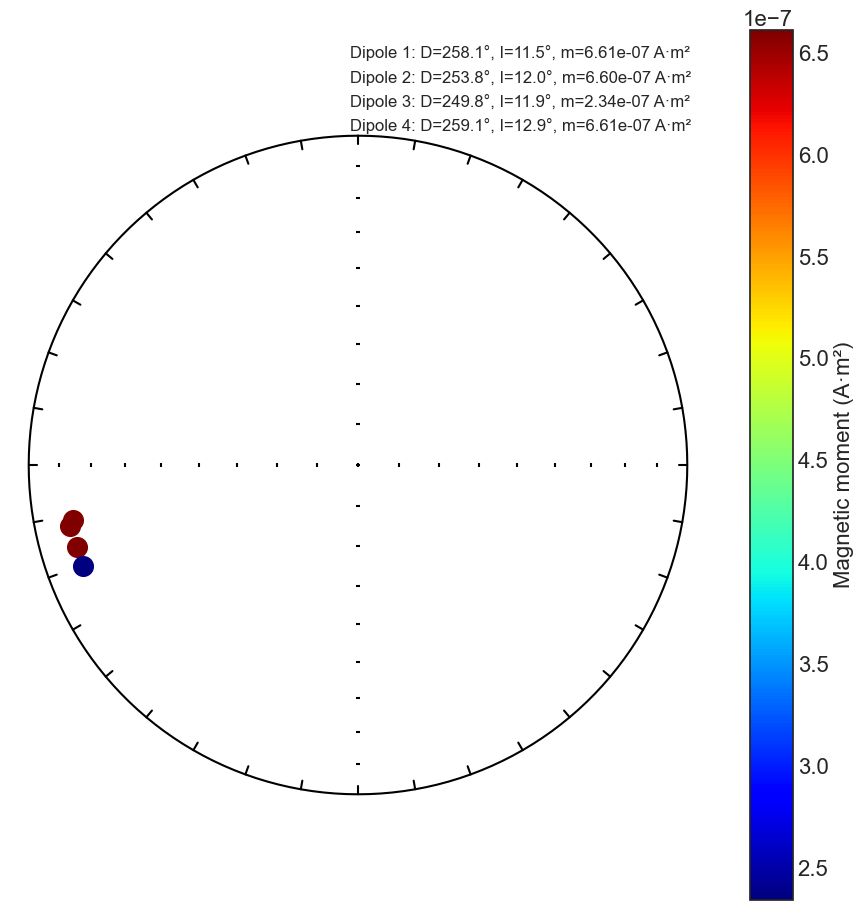

Saved combined plot: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-Source_Detection\All_Combined_Grains_DecInc_byMoment.png


In [34]:
### Stereonet plot (combined grains) — color by moment
# ============================================================
#  User Attention define cell sizes (dx,dy,dz) [cell volume] for dipole moment calculation  
# ============================================================
dx = 4.4* 1e-6   # cell size in X 
dy = 4.4* 1e-6   # cell size in Y
dz = 4.4* 1e-6   # cell size in Z
volume = dx * dy * dz

base_dir = os.getcwd()
root_folder = os.path.join(base_dir, "4-Source_Detection", "Tomofast_Output")

grain_folders = ["combined_grains"]
print("Using combined-grains model:", grain_folders)

results = []  # store (grain_index, dec, inc, moment)

for folder in grain_folders:

    print("\nProcessing:", folder)
    Model = os.path.join(root_folder, folder, "model", "mag_final_model_full.txt")

    with open(Model, "r") as f:
        lines = f.readlines()

    Ngrains = int(lines[0].strip())
    print("Number of grains detected:", Ngrains)

    data = np.loadtxt(lines[1:])
    data = np.atleast_2d(data)

    for idx, (Mx, My, Mz_raw) in enumerate(data, start=1):

        Mz = -Mz_raw
        mag = np.sqrt(Mx**2 + My**2 + Mz**2)     # magnetization magnitude
        moment = mag * volume                    # moment intensity (your definition)

        if mag == 0:
            dec, inc = np.nan, np.nan
        else:
            theta = np.degrees(np.arccos(Mz / mag))
            phi   = np.degrees(np.arctan2(My, Mx))

            inc = theta - 90
            dec = 90 - phi

            change = True
            while change:
                change = False
                if inc > 90:
                    inc = 180 - inc
                    dec = dec + 180
                    change = True
                if inc < -90:
                    inc = -180 - inc
                    dec = dec + 180
                    change = True
                if dec < 0:
                    dec = dec + 360
                    change = True
                if dec >= 360:
                    dec = dec - 360
                    change = True

        print(f"Grain {idx}: dec={dec:.2f}, inc={inc:.2f}, moment={moment:.3e}")
        results.append((idx, dec, inc, moment))


# ======================================
# Plot on Stereonet
# ======================================
plt.figure(figsize=(9, 9))
ipmag.plot_net()
ax = plt.gca()

#ax.text(0.02, 0.98, "(d)", transform=ax.transAxes,
#        fontsize=30, fontweight="bold", va="top", ha="left")

# --- color by moment ---
moments = np.array([r[3] for r in results], dtype=float)
good = np.isfinite(moments)

vmin = np.nanmin(moments[good])
vmax = np.nanmax(moments[good])
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.jet

for (grain_idx, dec, inc, moment) in results:
    if not (np.isfinite(dec) and np.isfinite(inc) and np.isfinite(moment)):
        continue
    col = cmap(norm(moment))
    ipmag.plot_di(dec, inc, color=col, marker='o', markersize=200)

# colorbar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.05)
cbar.set_label("Magnetic moment (A·m²)", fontsize=16)
cbar.ax.tick_params(labelsize=16)
cbar.ax.yaxis.get_offset_text().set_fontsize(16)

#legend
for (grain_idx, dec, inc, moment) in results:
    plt.plot([], [], color="k", linestyle="None",
             label=f"Dipole {grain_idx}: D={dec:.1f}°, I={inc:.1f}°, m={moment:.2e} A·m²")



plt.legend(loc="upper right", handlelength=0, handletextpad=0, fontsize=12)

out_png = os.path.join(base_dir, "4-Source_Detection", "All_Combined_Grains_DecInc_byMoment.png")
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved combined plot:", out_png)


### 5. Final Report and plots
* User Attention define cell sizes (dx,dy,dz) [cell volume] for dipole moment calculation 

In [35]:
# Vector Direction Calculation + Best Mesh Centers as TABLE (ONE MODEL, MANY BLOB LOCATIONS)
# User Attention define cell sizes (dx,dy,dz) [cell volume] for dipole moment calculation 

# ---------------------------------------------------------
# 1) Paths
# ---------------------------------------------------------
summary_path = os.path.join(
    base_dir,
    "4-Source_Detection",
    "Results_DataCost",
    "all_final_data_costs_ALL_BLOBS.txt"
)


Model = os.path.join(
    base_dir,
    "4-Source_Detection",
    "Tomofast_Output",
    "combined_grains",          # or whatever your single-run folder is
    "model",
    "mag_final_model_full.txt"
)

out_csv = os.path.join(base_dir, "4-Source_Detection", "Blob_Vector_Summary.csv")

# ---------------------------------------------------------
# 2) Read summary + best per blob
# ---------------------------------------------------------
df = pd.read_csv(
    summary_path,
    sep=r"\s+",
    skiprows=1,
    names=["blob", "grain", "meshfile", "xmin", "xmax", "ymin", "ymax",
           "zmin", "zmax", "final_data_cost"]
)

# best mesh row per blob
best = df.loc[df.groupby("blob")["final_data_cost"].idxmin()].reset_index(drop=True)

# sort blobs Blob_001, Blob_002, ...
def blob_num(b):
    m = re.search(r"(\d+)$", b)
    return int(m.group(1)) if m else 10**9

best = best.sort_values("blob", key=lambda s: s.map(blob_num)).reset_index(drop=True)

print("Number of blobs (best rows):", len(best))
print("First blobs:", best["blob"].head().tolist())

# compute centers
best["x_center"] = 0.5 * (best["xmin"] + best["xmax"])
best["y_center"] = 0.5 * (best["ymin"] + best["ymax"])
best["z_center"] = 0.5 * (best["zmin"] + best["zmax"])

# ---------------------------------------------------------
# 3) Load the ONE model file (Mx My Mz rows)
# ---------------------------------------------------------
print("\nModel file:", Model)
with open(Model, "r") as f:
    lines = f.readlines()

Nmodel = int(lines[0].strip())
data = np.loadtxt(lines[1:])
data = np.atleast_2d(data)

print("Number of cells in model:", Nmodel)

# check matching
if Nmodel != len(best):
    print("WARNING: model cells != number of blobs in best table")
    print("  Nmodel =", Nmodel)
    print("  Nblobs =", len(best))
    print("Fix by: (1) ensuring blob list matches model order, (2) removing extra blobs, or (3) using the correct model file.")

# ---------------------------------------------------------
# 4) Compute directions per blob (row i = blob i after sorting)
# ---------------------------------------------------------
dx = dy = dz = 4.4e-6
V = dx * dy * dz

table_rows = []

n = min(Nmodel, len(best))  # safe loop

for i in range(n):
    blob_name = best.loc[i, "blob"]
    Mx, My, Mz_raw = data[i]

    # sign flip (same as your original)
    Mz = -Mz_raw
    m = np.sqrt(Mx**2 + My**2 + Mz**2)

    if m == 0:
        dec, inc = np.nan, np.nan
    else:
        theta = np.degrees(np.arccos(Mz / m))
        phi   = np.degrees(np.arctan2(My, Mx))

        inc = theta - 90
        #dec= phi - 90
        dec = 90- phi

        change = True
        while change:
            change = False
            if inc > 90:
                inc = 180 - inc
                dec = dec + 180
                change = True
            if inc < -90:
                inc = -180 - inc
                dec = dec + 180
                change = True
            if dec < 0:
                dec = dec + 360
                change = True
            if dec >= 360:
                dec = dec - 360
                change = True

    M_amp = np.sqrt(Mx**2 + My**2 + Mz**2)
    moment_amp = M_amp * V

    table_rows.append({
        "blob": blob_name,
        "meshfile": best.loc[i, "meshfile"],
        "final_data_cost": best.loc[i, "final_data_cost"],
        "x_center": best.loc[i, "x_center"],
        "y_center": best.loc[i, "y_center"],
        "z_center": best.loc[i, "z_center"],
       # "Mx": Mx,
       # "My": My,
       # "Mz_raw": Mz_raw,
      #  "Mz_flipped": Mz,
        "dec": dec,
        "inc": inc,
        #"M_amp(A/m)": M_amp,
        "moment(A·m²)": moment_amp
    })

results_table = pd.DataFrame(table_rows)

print("\n================= FINAL Report (PER BLOB) =================\n")
print(results_table.to_string(index=False))

results_table.to_csv(out_csv, index=False)
print("\n Saved:", out_csv)


Number of blobs (best rows): 4
First blobs: ['Blob_003', 'Blob_005', 'Blob_006', 'Blob_007']

Model file: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-Source_Detection\Tomofast_Output\combined_grains\model\mag_final_model_full.txt
Number of cells in model: 4

================= FINAL Report (PER BLOB) =================

    blob          meshfile  final_data_cost  x_center  y_center  z_center        dec       inc  moment(A·m²)
Blob_003  meshgrid_541.txt         0.199015    1227.6     206.8     187.0 258.090265 11.501165  6.606094e-07
Blob_005 meshgrid_1652.txt         0.252664    1073.6     492.8     226.6 253.783299 11.986542  6.598845e-07
Blob_006 meshgrid_2150.txt         0.156428     937.2     761.2     156.2 249.839669 11.923638  2.342259e-07
Blob_007 meshgrid_2193.txt         0.224906     739.2    1038.4     195.8 259.113805 12.906950  6.610421e-07

 Saved: D:\My_Work\Tomofast-x-µ\Work\Natural_applications\Origin_Fix\2\4-Source_Detection\Blob_Vector_Summary.csv

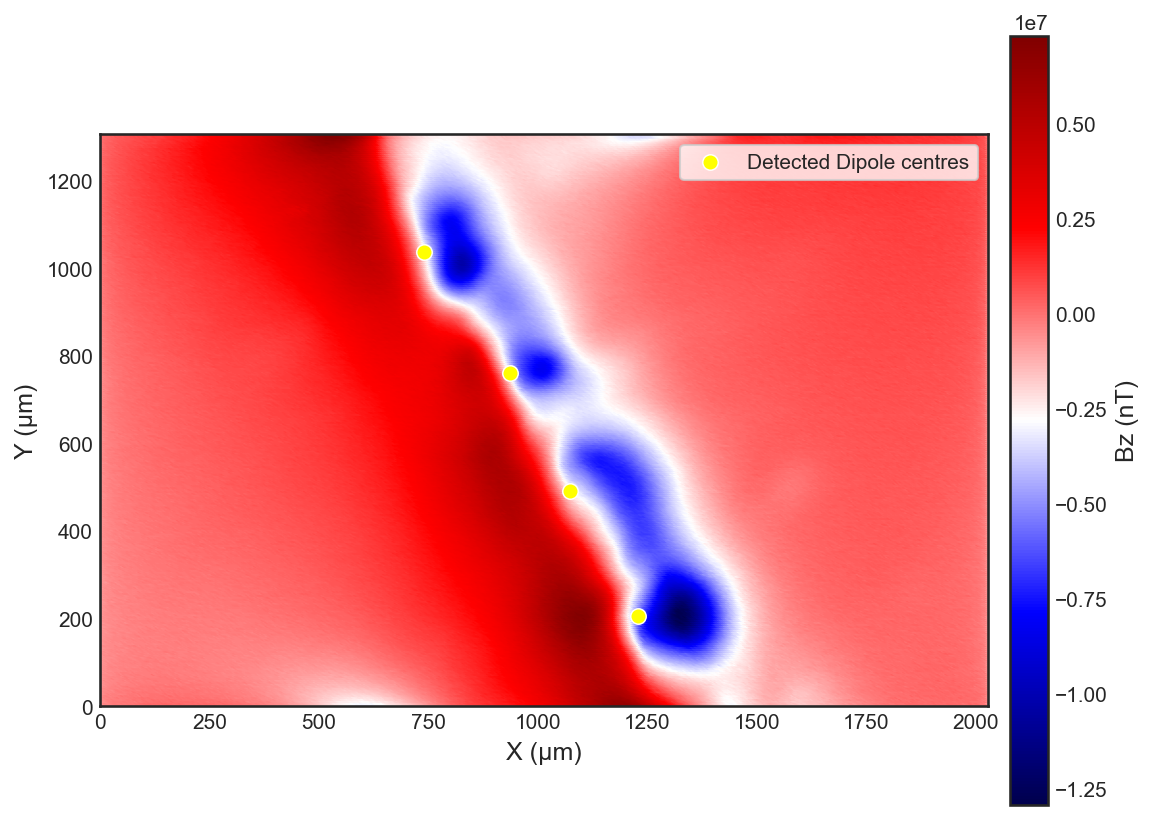

In [36]:
# plot detected locations on Bz

# ---------- 1. Read mag.obs ----------
mag_path = os.path.join(base_dir, "4-3D_Inversion_Filtered", "Mag_Inversion.obs")
mag = np.loadtxt(mag_path, skiprows=1)

x = mag[:, 0]
y = mag[:, 1]
bz = mag[:, 3]
#back to QDM Converntion
bz = -1*mag[:, 3]

# ---------- 2. Read grain centres ----------
grain_path = os.path.join(base_dir, "4-Source_Detection", "Blob_Vector_Summary.csv")
grains = pd.read_csv(grain_path, sep=None, engine="python")

gx = grains["x_center"].values
gy = grains["y_center"].values

# ---------- 3. Improve colour scaling ----------
bz_min = np.percentile(bz, 0)
bz_max = np.percentile(bz, 100)

# ---------- 4. Apply nicer matplotlib style ----------
plt.style.use("seaborn-v0_8-white")

# ---------- 5. Plot ----------
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

# Bz scatter (clipped for prettier colour contrast)
sc = ax.scatter(
    x, y, c=bz, s=10, cmap="seismic",
    vmin=bz_min, vmax=bz_max, rasterized=True
)

cbar = plt.colorbar(sc, ax=ax, shrink=0.9, pad=0.02)
cbar.set_label("Bz (nT)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

# Grain centres
ax.scatter(
    gx, gy, c="yellow", s=55, edgecolors="white",
    linewidths=0.7, label="Detected Dipole centres", zorder=3
)

# ---------- 6. Labels & styling ----------
ax.set_xlabel("X (µm)", fontsize=12)
ax.set_ylabel("Y (µm)", fontsize=12)
#ax.set_title("Bz Map with Grain Centres", fontsize=14)

ax.set_aspect("equal", adjustable="box")
ax.grid(True, linestyle="--", alpha=0.3)
ax.margins(0)
plt.legend(frameon=True, fontsize=10, loc="upper right")
plt.tight_layout()

out_png = os.path.join(base_dir, "4-Source_Detection", "BZ_grains_centers.png")
plt.savefig(out_png, dpi=300, bbox_inches='tight')
plt.show()


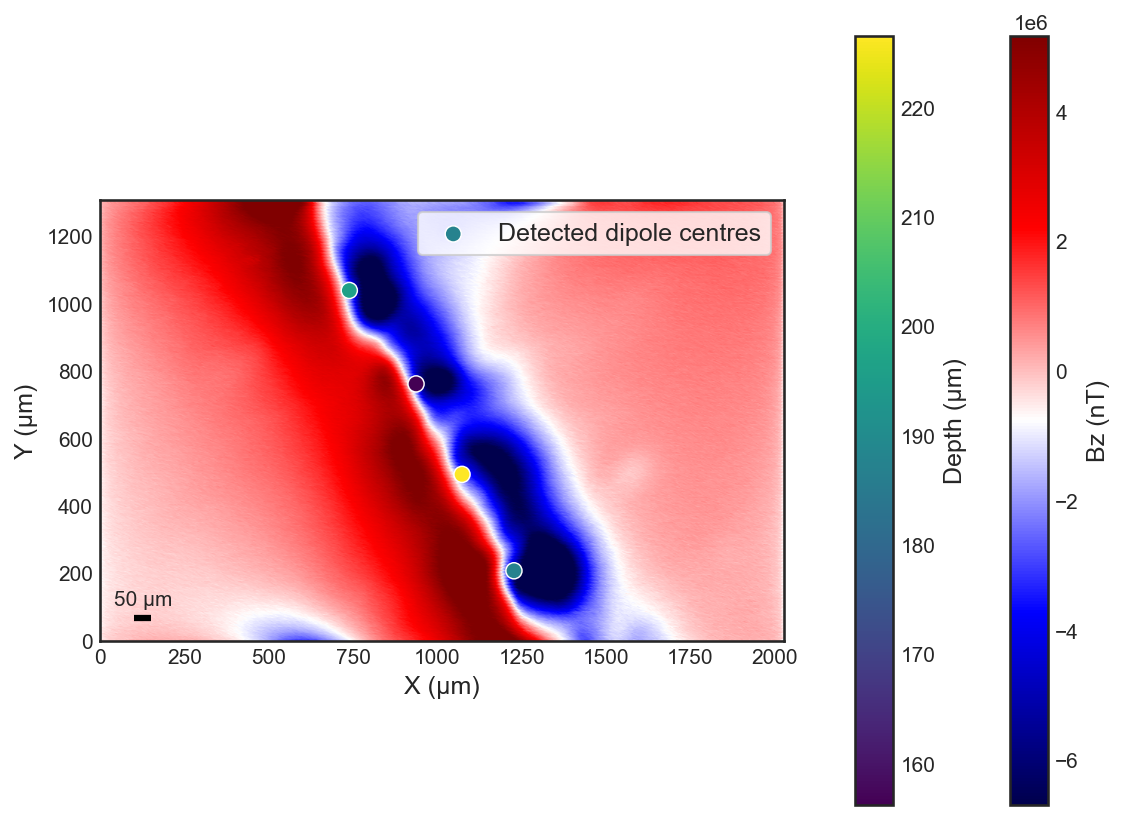

In [37]:
# plot detected locations and depths on bz

# ---------- 1. Read mag.obs ----------
mag_path = os.path.join(base_dir, "4-3D_Inversion_Filtered", "Mag_Inversion.obs")
mag = np.loadtxt(mag_path, skiprows=1)

x = mag[:, 0]
y = mag[:, 1]
bz =  mag[:, 3]   # QDM convention

bz = -1 * mag[:, 3]   # QDM convention

# ---------- 2. Read grain centres ----------
grain_path = os.path.join(base_dir, "4-Source_Detection", "Blob_Vector_Summary.csv")
grains = pd.read_csv(grain_path, sep=None, engine="python")

gx = grains["x_center"].values
gy = grains["y_center"].values
gz = grains["z_center"].values   # <<< depth

# ---------- 3. Improve colour scaling (clip 2% outliers) ----------
bz_min = np.percentile(bz, 2)
bz_max = np.percentile(bz, 98)

# ---------- 4. Apply matplotlib style ----------
plt.style.use("seaborn-v0_8-white")

# ---------- 5. Plot ----------
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

# Bz scatter
sc = ax.scatter(
    x, y, c=bz, s=10, cmap="seismic",
    vmin=bz_min, vmax=bz_max, rasterized=True
)

cbar = plt.colorbar(sc, ax=ax, shrink=0.9, pad=0.02)
cbar.set_label("Bz (nT)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

# Grain centres colored by depth
scz = ax.scatter(
    gx, gy, c=gz, cmap="viridis", s=60,
    edgecolors="white", linewidths=0.7,
    label="Detected dipole centres", zorder=3
)

cbarz = plt.colorbar(scz, ax=ax, shrink=0.9, pad=0.08)
cbarz.set_label("Depth (µm)", fontsize=12)
cbarz.ax.tick_params(labelsize=10)

# ---------- Scale bar (e.g., 100 µm) ----------
bar_len = 50.0  # µm
x0 = np.min(x) + 0.05 * (np.max(x) - np.min(x))
y0 = np.min(y) + 0.05 * (np.max(y) - np.min(y))

ax.plot([x0, x0 + bar_len], [y0, y0], color="k", linewidth=3, solid_capstyle="butt", zorder=5)
ax.text(x0 + 0.5 * bar_len, y0 + 0.02 * (np.max(y) - np.min(y)),
        f"{int(bar_len)} µm", ha="center", va="bottom", fontsize=10)

# ---------- 6. Labels & styling ----------
ax.set_xlabel("X (µm)", fontsize=12)
ax.set_ylabel("Y (µm)", fontsize=12)

ax.set_aspect("equal", adjustable="box")
#ax.grid(True, linestyle="--", alpha=0.3)
ax.margins(0)

#ax.text(
#    0.02, 0.98, "(b)",
 #   transform=ax.transAxes,
 #   fontsize=18,
 #   fontweight="bold",
 #   va="top",
 #   ha="left"
#)

plt.legend(frameon=True, fontsize=12, loc="upper right")
plt.tight_layout()

out_png = os.path.join(base_dir, "4-Source_Detection", "BZ_grains_centers_depth.png")
plt.savefig(out_png, dpi=300, bbox_inches='tight')
plt.show()


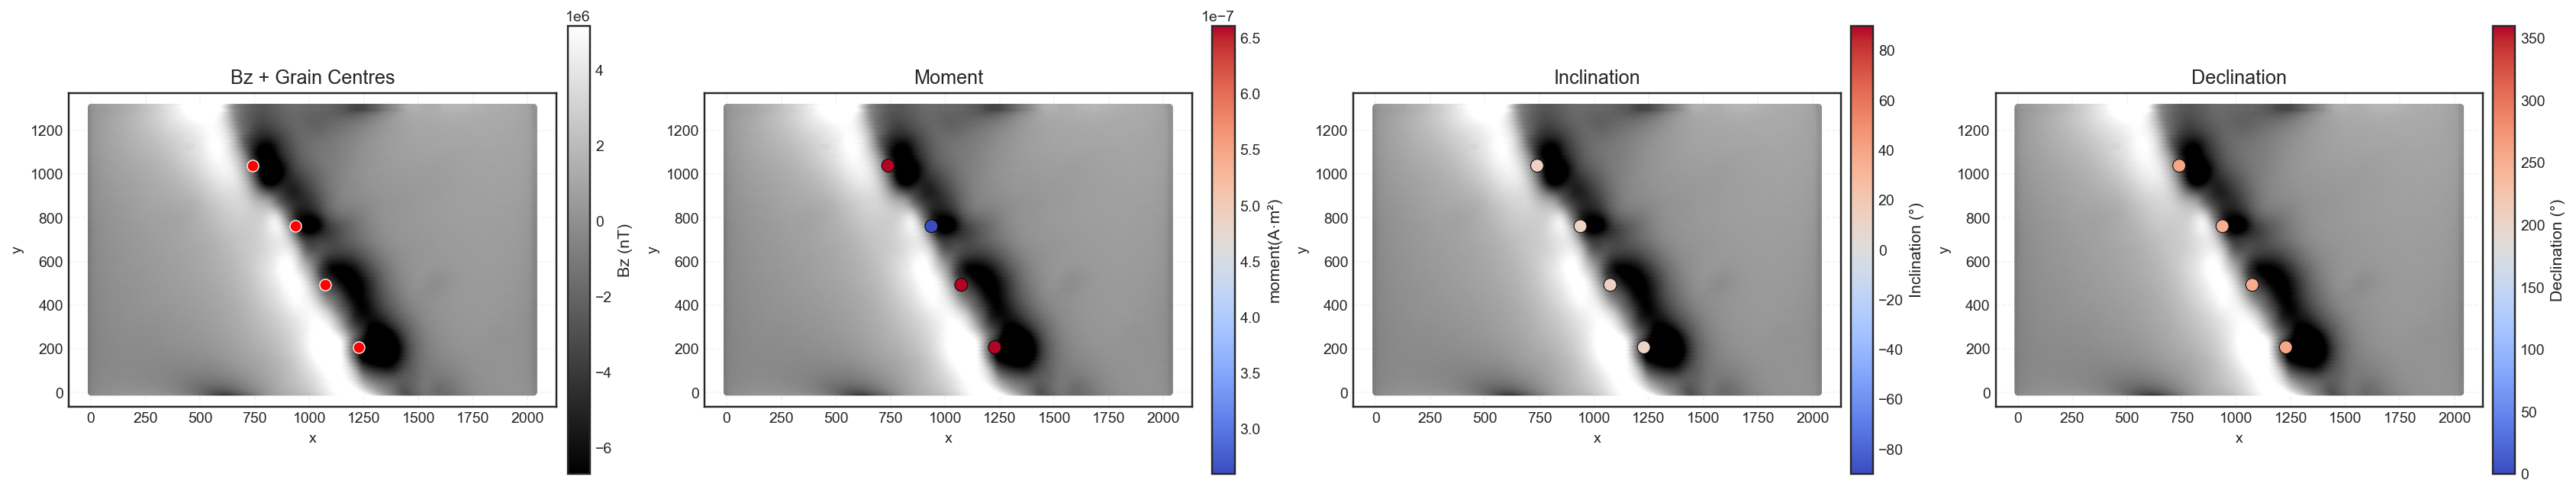

In [38]:
# plot full results (locations, moment, inc, dec)

# ---------- 1) Read mag.obs ----------
mag_path = os.path.join(base_dir, "4-3D_Inversion_Filtered", "Mag_Inversion.obs")
mag = np.loadtxt(mag_path, skiprows=1)

x = mag[:, 0]
y = mag[:, 1]
bz = mag[:, 3]

bz = -1*mag[:, 3]


# ---------- 2) Read grain centres & properties ----------
grain_path = os.path.join(base_dir, "4-Source_Detection", "Blob_Vector_Summary.csv")
grains = pd.read_csv(grain_path)

# Required columns
if "x_center" not in grains.columns or "y_center" not in grains.columns:
    raise ValueError(f"CSV must contain x_center and y_center. Found: {list(grains.columns)}")
if "dec" not in grains.columns or "inc" not in grains.columns:
    raise ValueError(f"CSV must contain dec and inc. Found: {list(grains.columns)}")

gx = grains["x_center"].to_numpy()
gy = grains["y_center"].to_numpy()
dec = grains["dec"].to_numpy()
inc = grains["inc"].to_numpy()

# moment column name can vary
moment_col_candidates = ["moment(A·m²)", "moment(A·m2)", "moment", "Moment", "moment_amp"]
moment_col = None
for c in moment_col_candidates:
    if c in grains.columns:
        moment_col = c
        break
if moment_col is None:
    raise ValueError(f"Could not find moment column in CSV. Found: {list(grains.columns)}")
moment = grains[moment_col].to_numpy()

# ---------- 3) Clip ranges ----------
bz_min = np.nanpercentile(bz, 2)
bz_max = np.nanpercentile(bz, 98)

m_min = np.nanpercentile(moment, 2)
m_max = np.nanpercentile(moment, 98)

# ---------- 4) Figure ----------
fig, axs = plt.subplots(1, 4, figsize=(24, 6), dpi=140, constrained_layout=True)

def plot_bz_background(ax):
    # GREY background
    sc = ax.scatter(
        x, y, c=bz, s=10, cmap="gray",
        vmin=bz_min, vmax=bz_max, rasterized=True
    )
    ax.set_aspect("equal")
    ax.grid(True, linestyle="--", alpha=0.25)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    return sc

# 1) Bz + centres
ax = axs[0]
sc_bz0 = plot_bz_background(ax)
ax.scatter(gx, gy, c="red", s=60, edgecolors="white", linewidths=0.7, zorder=3)
ax.set_title("Bz + Grain Centres", fontsize=13)

# 2) Moment
ax = axs[1]
plot_bz_background(ax)
sc_m = ax.scatter(
    gx, gy, c=moment, s=75, cmap="coolwarm",
    vmin=m_min, vmax=m_max,
    edgecolors="black", linewidths=0.5, zorder=3
)
ax.set_title("Moment", fontsize=13)

# 3) Inclination
ax = axs[2]
plot_bz_background(ax)
sc_i = ax.scatter(
    gx, gy, c=inc, s=75, cmap="coolwarm",
    vmin=-90, vmax=90,
    edgecolors="black", linewidths=0.5, zorder=3
)
ax.set_title("Inclination", fontsize=13)

# 4) Declination
ax = axs[3]
plot_bz_background(ax)
sc_d = ax.scatter(
    gx, gy, c=dec, s=75, cmap="coolwarm",
    vmin=0, vmax=360,
    edgecolors="black", linewidths=0.5, zorder=3
)
ax.set_title("Declination", fontsize=13)

# ---------- Colorbars (FIXED POSITIONS) ----------
# Put each colorbar next to its own axis (no global colorbar)
cb_bz = fig.colorbar(sc_bz0, ax=axs[0], fraction=0.046, pad=0.02)
cb_bz.set_label("Bz (nT)", fontsize=11)

cb_m = fig.colorbar(sc_m, ax=axs[1], fraction=0.046, pad=0.02)
cb_m.set_label(f"{moment_col}", fontsize=11)

cb_i = fig.colorbar(sc_i, ax=axs[2], fraction=0.046, pad=0.02)
cb_i.set_label("Inclination (°)", fontsize=11)

cb_d = fig.colorbar(sc_d, ax=axs[3], fraction=0.046, pad=0.02)
cb_d.set_label("Declination (°)", fontsize=11)

out_png = os.path.join(base_dir, "4-Source_Detection", "BZ_grains_centers_results.png")
plt.savefig(out_png, dpi=300, bbox_inches='tight')
plt.show()


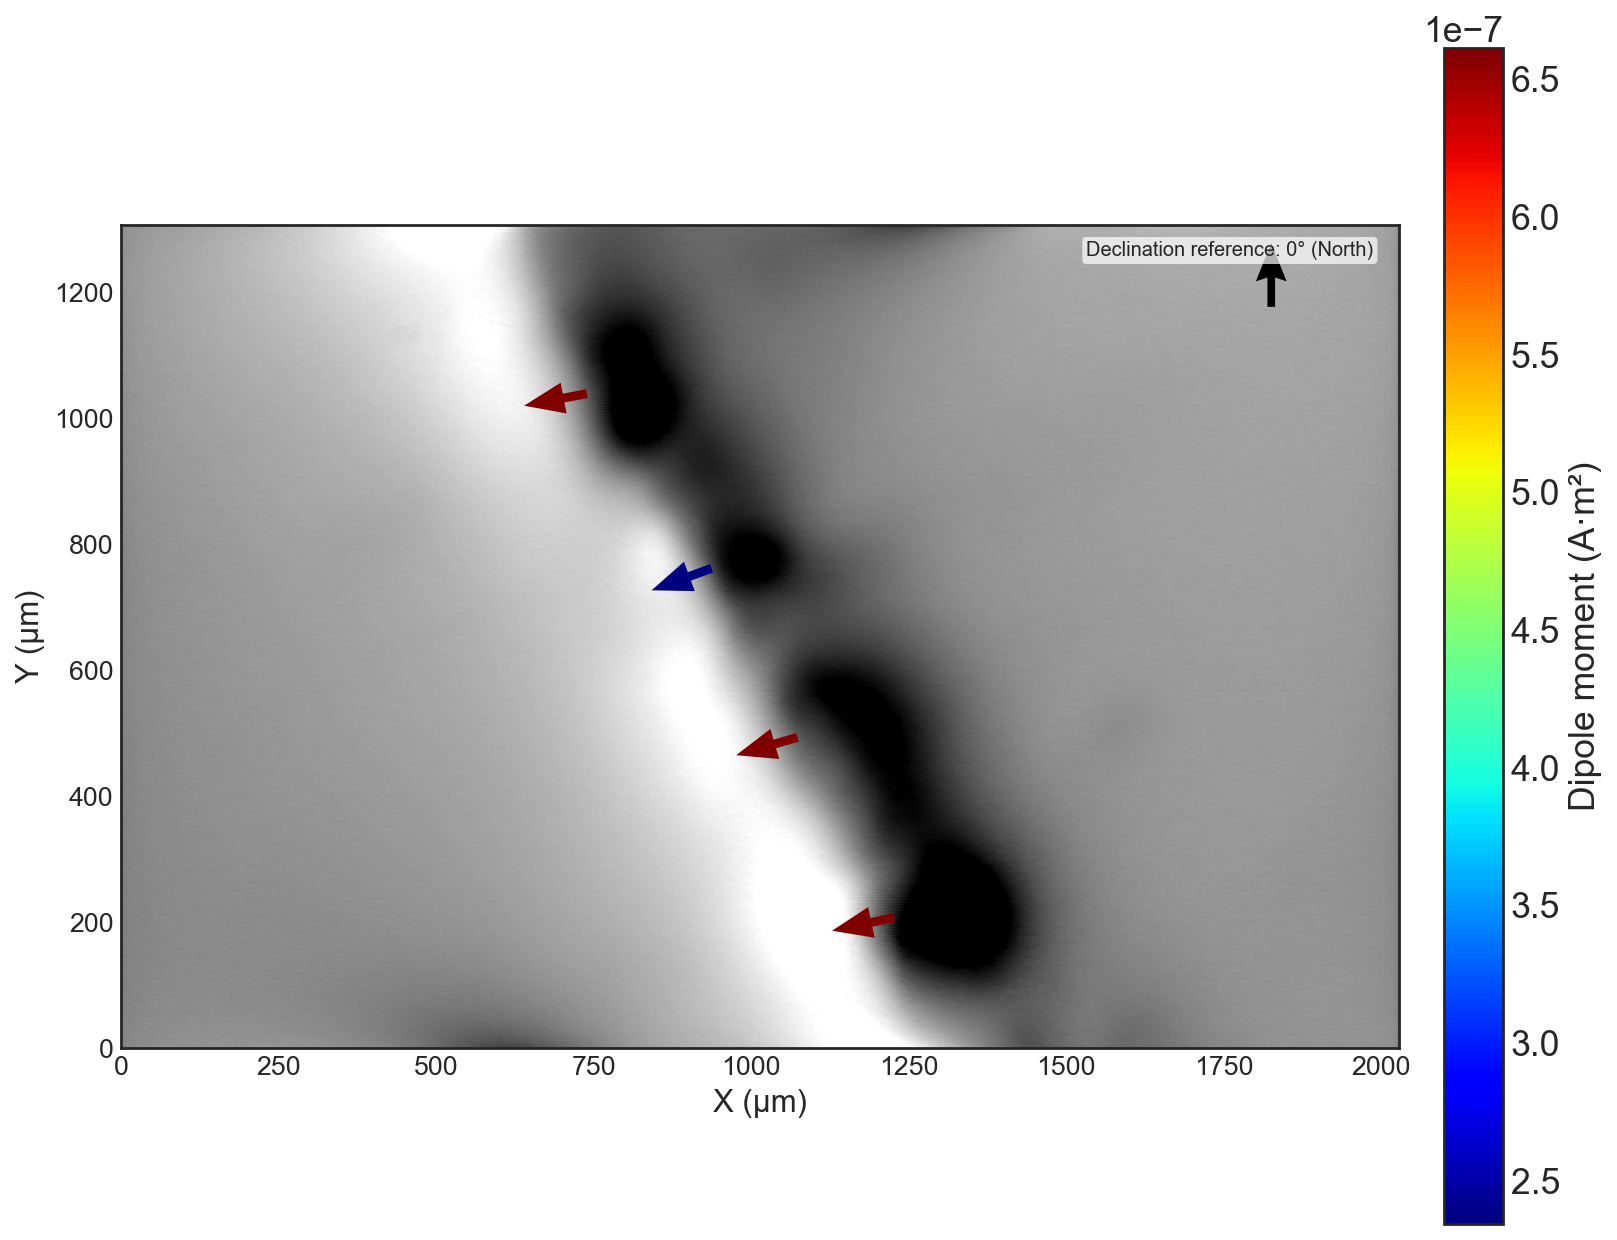

In [39]:
# plot declinations arrows colored by moment overlaied on bz

# ---------- 1) Read mag.obs ----------
mag_path = os.path.join(base_dir, "4-3D_Inversion_Filtered", "Mag_Inversion.obs")
mag = np.loadtxt(mag_path, skiprows=1)

x = mag[:, 0]
y = mag[:, 1]
bz = mag[:, 3]


bz = -1*mag[:, 3]

# ---------- 2) Read grain centres & properties ----------
grain_path = os.path.join(base_dir, "4-Source_Detection", "Blob_Vector_Summary.csv")
grains = pd.read_csv(grain_path)

# Required columns
required_cols = ["x_center", "y_center", "dec"]
for c in required_cols:
    if c not in grains.columns:
        raise ValueError(f"Missing column {c} in Blob_Vector_Summary.csv")

gx = grains["x_center"].to_numpy()
gy = grains["y_center"].to_numpy()
dec = grains["dec"].to_numpy()

# moment column name can vary
moment_col_candidates = ["moment(A·m²)", "moment(A·m2)", "moment", "Moment", "moment_amp"]
moment_col = None
for c in moment_col_candidates:
    if c in grains.columns:
        moment_col = c
        break
if moment_col is None:
    raise ValueError(f"Could not find moment column in CSV. Found: {list(grains.columns)}")
moment = grains[moment_col].to_numpy()

# ---------- 3) Clip ranges ----------
bz_min = np.nanpercentile(bz, 2)
bz_max = np.nanpercentile(bz, 98)

m_min = np.nanmin(moment)
m_max = np.nanmax(moment)

# ---------- 4) Figure ----------
fig, ax = plt.subplots(1, 1, figsize=(10, 8), dpi=160, constrained_layout=True)

# --- Bz background (GREY) ---
sc_bz = ax.scatter(
    x, y,
    c=bz, s=10, cmap="gray",
    vmin=bz_min, vmax=bz_max,
    rasterized=True
)


ax.set_aspect("equal")
ax.grid(True, linestyle="--", alpha=0.25)
ax.margins(0)
ax.set_xlabel("X (µm)", fontsize=14)
ax.set_ylabel("Y (µm)", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
#ax.set_title("Bz map + Declination arrows (colored by Moment)", fontsize=13)

# ---------- Declination arrows ----------
# Use declination from results directly (degrees → radians)
dec_rad = np.deg2rad(dec)

# Unit direction vectors
#u = np.cos(dec_rad)
#v = np.sin(dec_rad)

# Geophysical declination convention:
# 0° = North (+Y), clockwise positive
u = np.sin(dec_rad)
v = np.cos(dec_rad)
           
# Fixed arrow length in data units (handle NaNs safely)
dx = np.ptp(x[np.isfinite(x)])
dy = np.ptp(y[np.isfinite(y)])
arrow_len = 0.05 * max(dx, dy)

# Color normalization for moment
norm_m = Normalize(vmin=m_min, vmax=m_max)

q = ax.quiver(
    gx, gy,
    u * arrow_len, v * arrow_len,
    moment,                    # color by moment
    cmap="jet",
    norm=norm_m,
    angles="xy",
    scale_units="xy",
    scale=1,                   # do NOT autoscale lengths
    width=0.007,
    headwidth=3.5,
    headlength=4.5,
    zorder=3
)

# ----------  3: Reference arrow ----------
#x0 = np.nanmin(x) + 0.08 * dx
#y0 = np.nanmin(y) + 0.10 * dy
x0 = np.nanmax(x) - 0.10 * dx,
y0 = np.nanmax(y) - 0.10 * dy,

# Reference arrow (0° = North, pointing UP)
ax.quiver(
    x0, y0,
    0.0, arrow_len,          # ← UPWARD arrow
    color="black",
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.006,
    headwidth=4.0,
    headlength=5.0,
    zorder=4
)


#ax.text(
#    x0, y0 + 1.15 * arrow_len,
#    "Declination reference: 0° (North)",
#    fontsize=9,
#    ha="center",
#    va="bottom",
#    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"),
#    zorder=5
#)

ax.text(
    0.98, 0.98,
    "Declination reference: 0° (North)",
    transform=ax.transAxes,
    fontsize=9,
    ha="right",
    va="top",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"),
    zorder=5
)


#ax.text(
 #   x0, y0 - 0.04 * dy,
 #   "Arrows show declination (°), clockwise from North",
  #  fontsize=7,
  #  ha="left",
  #  va="top",
  #  bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"),
  #  zorder=5
#)


# ---------- Colorbars ----------
#cb_bz = fig.colorbar(sc_bz, ax=ax, fraction=0.046, pad=0.02)
#cb_bz.set_label("Bz (nT)", fontsize=12)
#cb_bz.ax.tick_params(labelsize=10)


cb_q = fig.colorbar(
    q, ax=ax,
    fraction=0.046, pad=0.01
)

cb_q.set_label("Dipole moment (A·m²)", fontsize=16)   # label font
cb_q.ax.tick_params(labelsize=16)                     # tick font
cb_q.ax.yaxis.get_offset_text().set_fontsize(16)  # < the 1e-8 text

#ax.text(
#    0.02, 0.98, "(c)",
#    transform=ax.transAxes,
 #   fontsize=25,
 #   fontweight="bold",
 #   va="top",
 #   ha="left"
#)

out_png = os.path.join(base_dir, "4-Source_Detection", "BZ_grains_Dec.png")
plt.savefig(out_png, dpi=300, bbox_inches='tight')
plt.show()


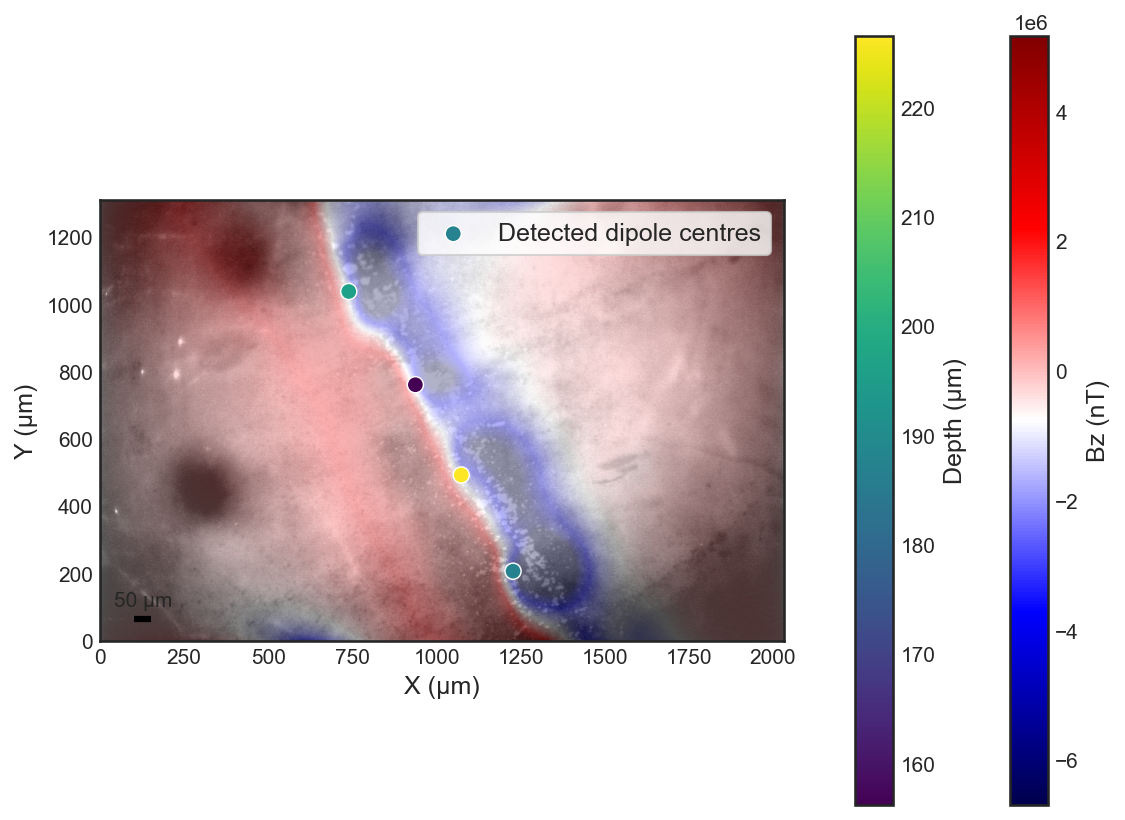

In [40]:
# plot led locations on led on bz
# User attention define pixel size (data spacing) (pix=)

# ---------- LOAD MAT (Bz + LED) ----------
mat_file = glob.glob(os.path.join(base_dir, "*.mat"))[0]
mat = loadmat(mat_file)

Bz  = np.squeeze(mat["Bz"]) * 1e9          # nT
led = np.squeeze(mat["newLED"])

# ---------- LOAD GRAIN CENTRES ----------
grain_path = os.path.join(base_dir, "4-Source_Detection", "Blob_Vector_Summary.csv")
grains = pd.read_csv(grain_path, sep=None, engine="python")

gx = grains["x_center"].values
gy = grains["y_center"].values
gz = grains["z_center"].values   # depth (µm)

# ---------- Pixel size (µm / pixel) ----------
pix = 4.4
ny, nx = Bz.shape

x = np.linspace(0, nx * pix, nx)
y = np.linspace(0, ny * pix, ny)

extent = [x.min(), x.max(), y.min(), y.max()]

# ---------- Improve colour scaling (clip 2% outliers) ----------
bz_min = np.percentile(Bz, 2)
bz_max = np.percentile(Bz, 98)

# ---------- Style ----------
plt.style.use("seaborn-v0_8-white")

# ---------- Plot ----------
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

# --- Bz base ---
im = ax.imshow(
    Bz,
    cmap="seismic",
    vmin=bz_min,
    vmax=bz_max,
    origin="upper",
    extent=extent
)

cbar = plt.colorbar(im, ax=ax, shrink=0.9, pad=0.02)
cbar.set_label("Bz (nT)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

# --- LED overlay ---
ax.imshow(
    led,
    cmap="gray",
    alpha=0.7,
    origin="upper",
    extent=extent,
    vmin=np.percentile(led, 5),
    vmax=np.percentile(led, 95)
)

# --- Grain centres colored by depth ---
scz = ax.scatter(
    gx, gy, c=gz, cmap="viridis", s=60,
    edgecolors="white", linewidths=0.7,
    label="Detected dipole centres", zorder=3
)

cbarz = plt.colorbar(scz, ax=ax, shrink=0.9, pad=0.08)
cbarz.set_label("Depth (µm)", fontsize=12)
cbarz.ax.tick_params(labelsize=10)

# ---------- Scale bar ----------
bar_len = 50.0  # µm
x0 = x.min() + 0.05 * (x.max() - x.min())
y0 = y.min() + 0.05 * (y.max() - y.min())

ax.plot([x0, x0 + bar_len], [y0, y0],
        color="k", linewidth=3, solid_capstyle="butt", zorder=5)
ax.text(x0 + 0.5 * bar_len, y0 + 0.02 * (y.max() - y.min()),
        f"{int(bar_len)} µm", ha="center", va="bottom", fontsize=10, zorder=5)

# ---------- Labels & styling ----------
ax.set_xlabel("X (µm)", fontsize=12)
ax.set_ylabel("Y (µm)", fontsize=12)
ax.set_aspect("equal", adjustable="box")
ax.margins(0)

#ax.text(
#    0.02, 0.98, "(b)",
#    transform=ax.transAxes,
 #   fontsize=18,
 #   fontweight="bold",
 #   va="top",
 #   ha="left"
#)

plt.legend(frameon=True, fontsize=12, loc="upper right")
plt.tight_layout()

# ---------- Save ----------
out_png = os.path.join(base_dir, "Bz_LED_grain_centers_depth.png")
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()
